# **Bank Customer Segmentation**


# Dataset Import

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Business_Case1/Dataset1_BankClients.xlsx'

#Load data in a DataFrame
data = pd.read_excel(path)

#Drop the column ID since is irrilevant
data = data.drop(columns=['ID'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
data = pd.read_excel('/content/Dataset1_BankClients.xlsx')
#Drop the column ID since it is irrelevant
data = data.drop(columns=['ID'])

# Preparaing Data

The Dataset is composed of categorical variables and numeric variables, many of which have already been provided normalized. What we did in this section was use the MinMaxScaler to normalize the remaining numeric variables (Age, FamilySize), also reducing them to a scale of 0 to 1.

Next, we used the OneHotEncoder to transform categorical variables into binary variables, choosing not to use the drop='first' parameter. This choice proved necessary for calculating the Jaccard and Dice metrics used in the clustering steps: by calculating similarity only on shared features (the '1's in common), eliminating a category by turning it into zeros made two identical customers 'invisible' to each other (with similarity equal to zero). Keeping all columns intact instead ensures that all categorical equality is always detected and calculated correctly.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Define lists of numerical and categorical columns
numerical_columns = ['Age', 'FamilySize']
categorical_columns = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']

# Define the remaining columns that are already normalized
other_columns = [col for col in data.columns if col not in categorical_columns + numerical_columns]

# Extract sub-datasets
numerical_features = data[numerical_columns]
categorical_features = data[categorical_columns].astype('category')
other_features = data[other_columns]

# Normalize numerical variables
scaler = MinMaxScaler()
X_num = scaler.fit_transform(numerical_features)

# Encode categorical variables
encoder = OneHotEncoder(drop=None, handle_unknown='ignore')
X_cat = encoder.fit_transform(categorical_features).toarray() # Transform to a dense matrix

# Extract the remaining columns
X_other = other_features.values

# Concatenate all variables
X = np.hstack((X_num, X_cat, X_other))

# Reconstruct the final DataFrame with the correct column names
encoded_cat_columns = encoder.get_feature_names_out(categorical_columns)
all_columns = numerical_columns + list(encoded_cat_columns) + other_columns

processed_data = pd.DataFrame(X, columns=all_columns)

# Display the first records
display(processed_data.head())

,Age,FamilySize,Gender_0,Gender_1,Job_1,Job_2,Job_3,Job_4,Job_5,Area_1,...,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving
0,0.065789,0.6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222
1,0.368421,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590
2,0.250000,0.2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790
3,0.631579,0.4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240
4,0.184211,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916


# 1 - Exploration Data Analysis (EDA)



In this first phase, we tried to understand the structure of the dataset, the distribution of individual variables, their mutual relationships, and the possible presence of outliers before proceeding with the modeling and clustering phases. We used the matplotlib and seaborn libraries to generate the Boxplot, Bar Chart, and correlation matrix.



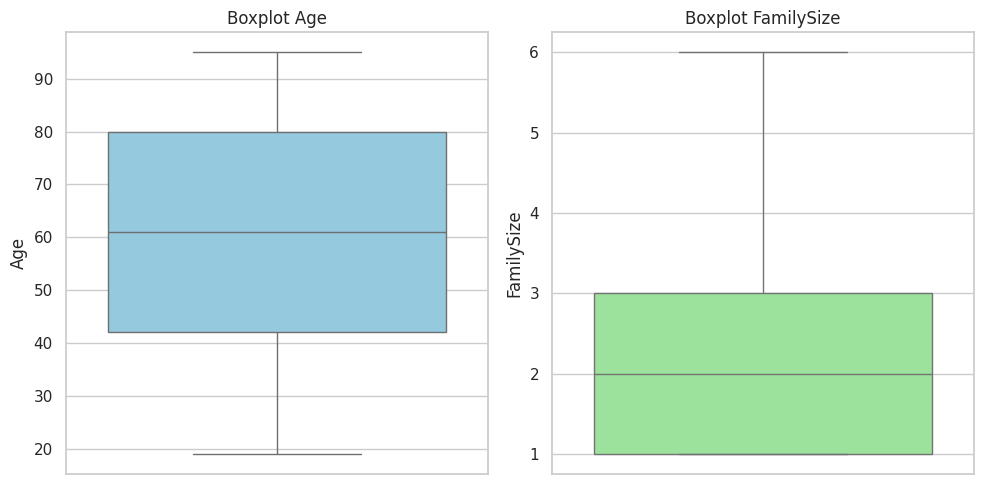

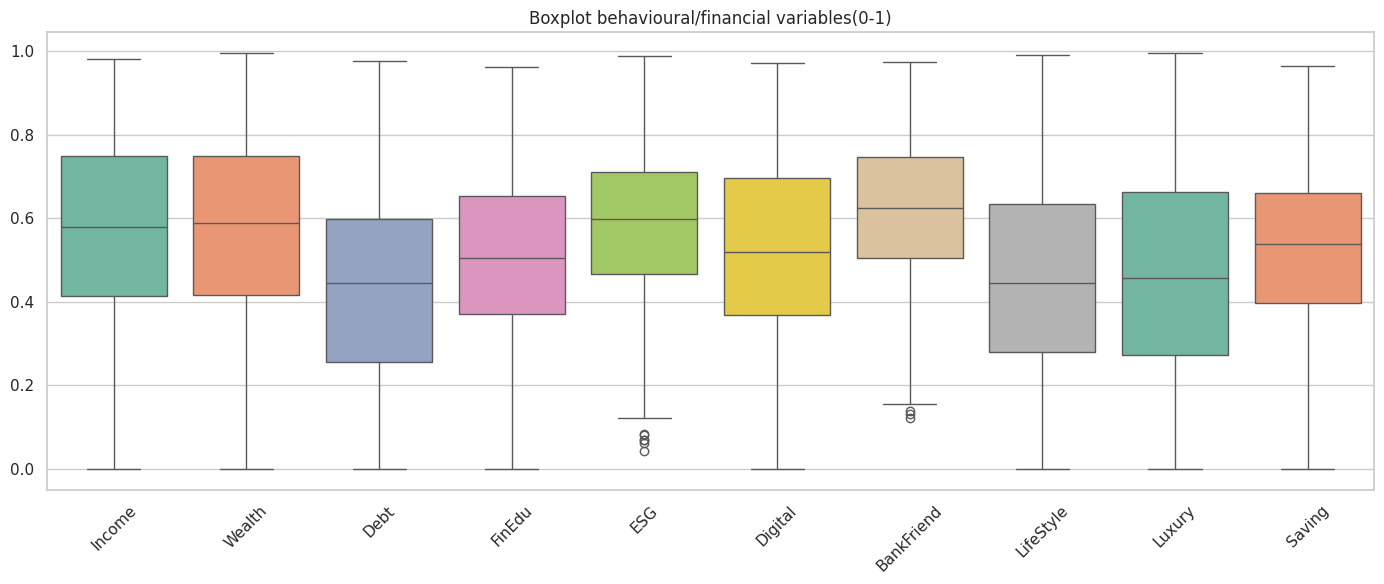

/tmp/ipykernel_1360/2348443913.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_1360/2348443913.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_1360/2348443913.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_1360/2348443913.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

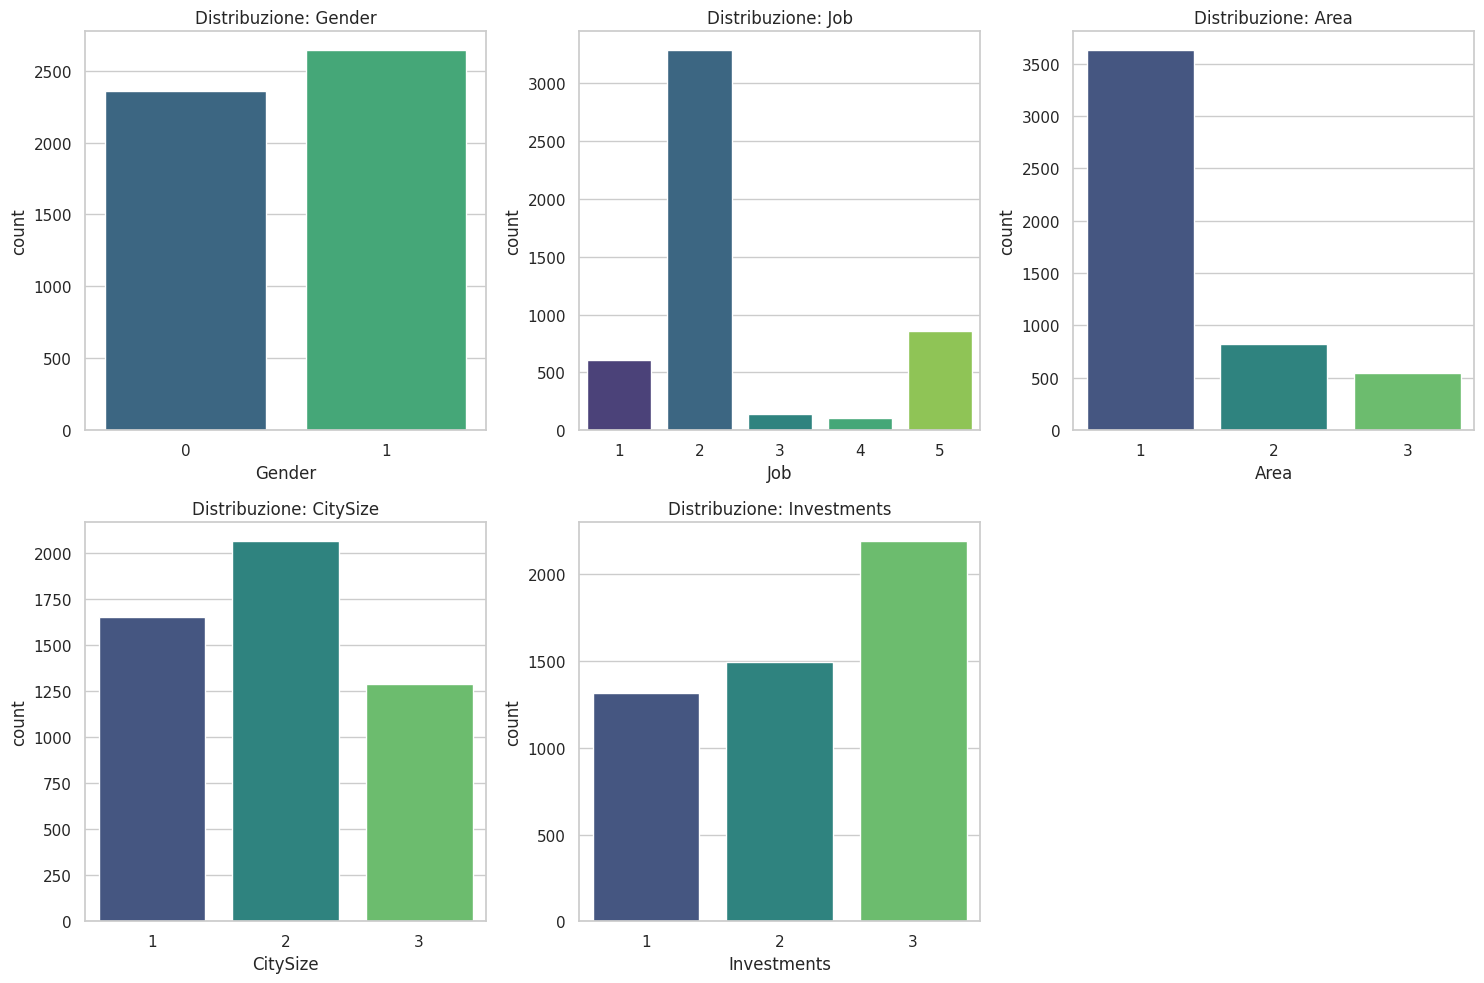

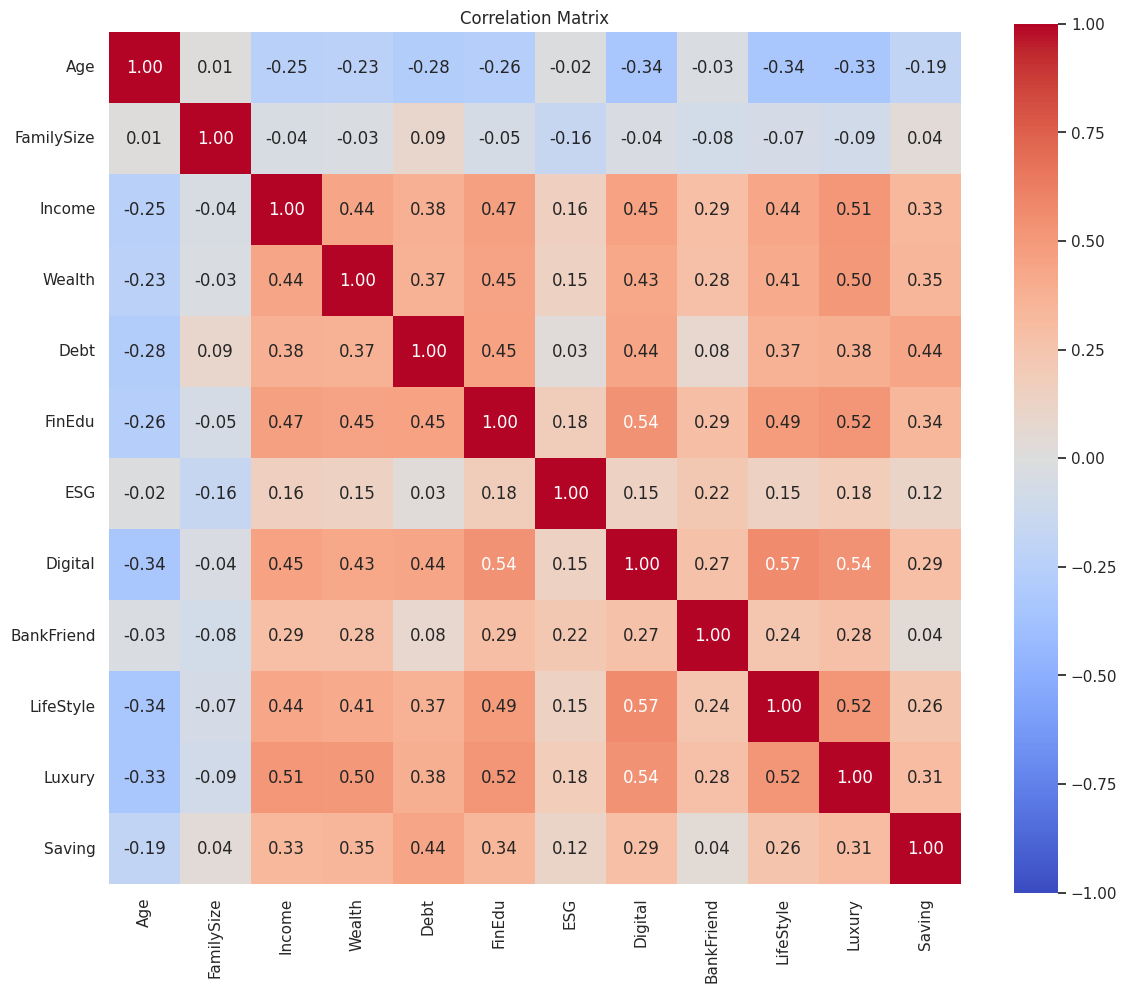

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a global aesthetic theme for the plots to make values easy to read
sns.set_theme(style="whitegrid")


# Boxplot to visualize the distribution, the median, and identify potential outliers
# for Age and Family Size.
# Create a figure with 1 row and 2 columns (two plots side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for Age (assigned to the first subplot: axes[0])
sns.boxplot(y=data['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot Age')

# Boxplot for Family Size (assigned to the second subplot: axes[1])
sns.boxplot(y=data['FamilySize'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot FamilySize')

# plt.tight_layout() optimizes the spacing between plots to prevent text overlapping
plt.tight_layout()
plt.show()



# Multiple Boxplot to compare the dispersion of all already normalized variables (0-1)

plt.figure(figsize=(14, 6))
sns.boxplot(data=data[other_columns], palette='Set2')

plt.title('Boxplot behavioural/financial variables(0-1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Bar Charts for the analysis of categorical variables
# Create a 2x3 grid (2 rows, 3 columns) to accommodate up to 6 plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# axes.flatten() transforms the 2x3 matrix into a flat list of 6 positions.
axes = axes.flatten()

# Loop through each categorical column (there are 5 in total)
for i, col in enumerate(categorical_columns):
    # countplot automatically counts the occurrences of each category
    sns.countplot(x=data[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribuzione: {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()



# Correlation Matrix to identify linear relationships between numerical variables.
plt.figure(figsize=(12, 10))

# Calculate the Pearson correlation matrix
corr = data[numerical_columns + other_columns].corr()

# Draw the Heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

**Registration Profile and Family Unit:**
Looking at the boxplots relating to the Age variable, it highlights that the central 50% enclosed in the interquartile range is between 40 and 80 years old. The remaining values are divided equally: a 25% younger clientele (20-40 years) and a 25% very mature clientele (80-90 years).
The size of the household (FamilySize) also shows a balanced distribution: half of the clients live in small settings (1-3 people), while the other half live in larger families (4-6 people). It is essential to note the total absence of outliers in these two distributions.


**Financial and Behavioral Variables:**
We can note that Income (Income) and Wealth (Wealth) have very similar distributions, highlighting a consistency between income and accumulated wealth. A similarity is also noted between Income and LifeStyle, indicating how lifestyle is closely linked to spending capacity.
In this case we observe the presence of outliers in the variables ESG (Ethical-Environmental Sensitivity) and BankFriend (Trust in the Bank)

**Socio-Demographic Composition (Categorical Variables):**
An analysis of the bar charts shows that the absolute majority is made up of employees, followed in order of frequency by retirees, inactive people, managers, and freelancers. Geographically, there is a clear prevalence of residents in Northern Italy, concentrated in medium-sized cities. From a capital perspective, the most widespread propensity to invest is monthly.

**Correlation Analysis and Features Validation:**
Observation of the correlation matrix shows us that mainly moderate or weak relationships emerge between numerical and behavioral variables. This data justifies our decision to keep all the variables in the dataset, as it ensures that each of them holds information essential for the subsequent construction of cluster well defined.

# FAMD

Once we understand how the dataset is formed, which features we have outliers for, and what correlations there are, we use a general visualization technique like FAMD.

This technique for numerical variables uses the Euclidean Distance and for categorical variables it uses the Chi-Square distance (χ2). Finally, these two distances are added together, but divide each block by its maximum variance so that neither overrides the other.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 10.2 MB/s eta 0:00:00
Addestramento FAMD (estraiamo 3 componenti)...


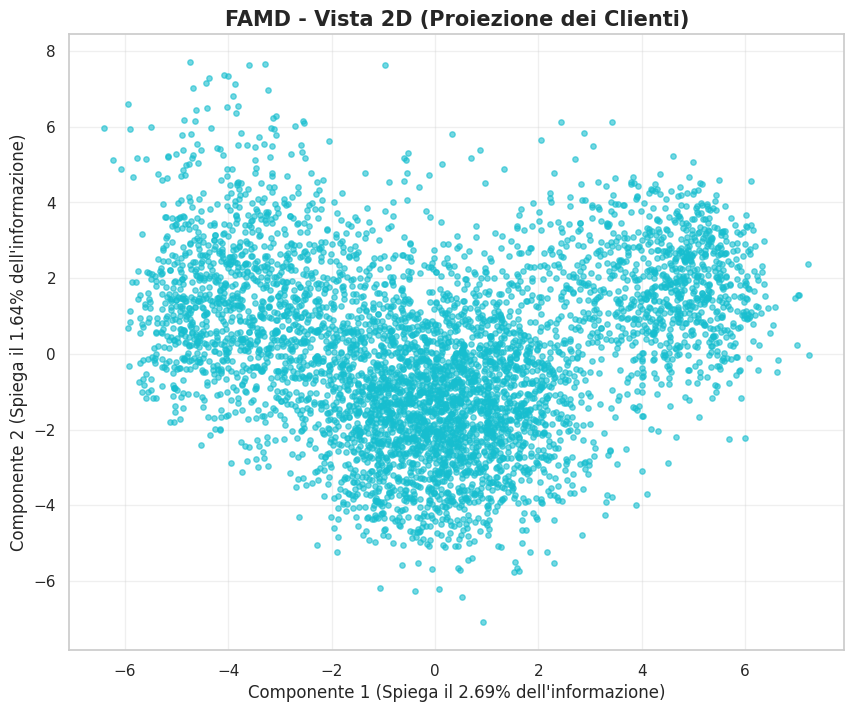

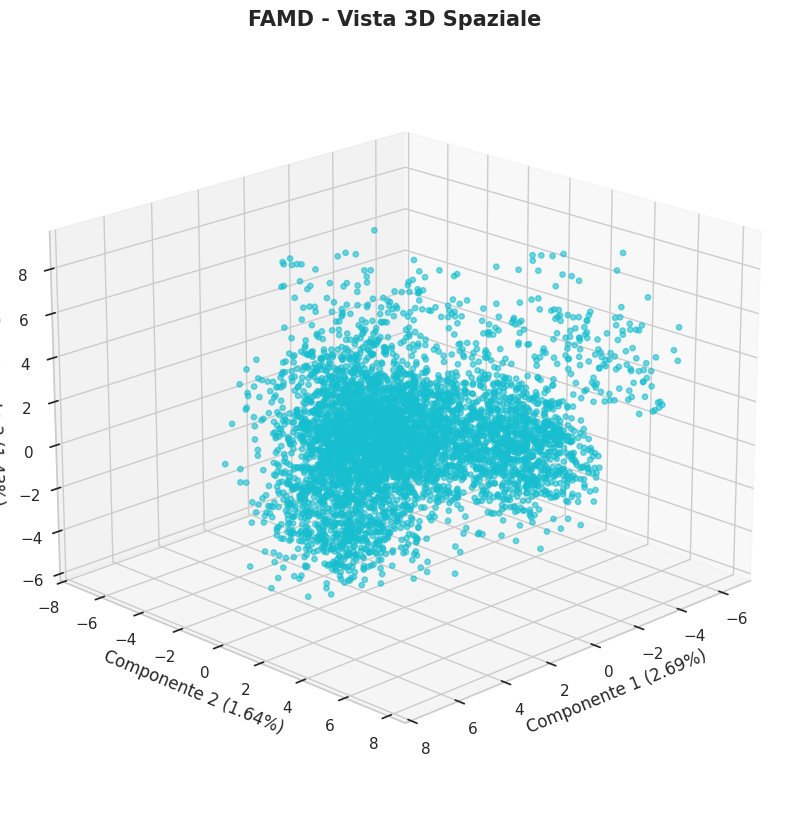


Variabili che contribuiscono di più alla creazione dei nuovi assi:


component,0,1,2
variable,,,
Income,0.042324,0.000077,0.000497
Wealth,0.040373,0.000022,0.002055
Debt,0.045063,0.011225,0.000635
FinEdu,0.051049,0.000170,0.003402
ESG,0.004465,0.019321,0.000614
Digital,0.053691,0.000088,0.000107
BankFriend,0.005998,0.007463,0.007348
LifeStyle,0.048374,0.000563,0.000629
Luxury,0.053817,0.002246,0.000009


In [ ]:
# Install the 'prince' library, specialized for dimensionality reduction
!pip install prince

import prince
import matplotlib.pyplot as plt


# Prepare data for FAMD
# Create a copy of the original dataset to avoid altering the base data
famd_data = data.copy()

# Loop through categorical columns and explicitly cast them to strings
for col in categorical_columns:
    famd_data[col] = famd_data[col].astype(str)



print("Addestramento FAMD (estraiamo 3 componenti)...")
famd = prince.FAMD(
    n_components=3, # Calculate 3 dimensions to allow for 2D and 3D plotting
    n_iter=10,      # Number of iterations for the mathematical algorithm
    copy=True,      # Work on a copy of the internal data for safety
    check_input=True,
    random_state=42,# Set the seed for reproducible results every time
    engine='sklearn'# Use scikit-learn as the computational engine behind the scenes
)

# fit_transform calculates the new axes and immediately projects our clients into this new 3D space.
# Y_famd is the new dataset.
Y_famd = famd.fit_transform(famd_data)

# Extract how much "information" (variance) of the original dataset has survived
# and has been captured by these 3 new components.
var_explained = famd.percentage_of_variance_



# PLOT 1: 2D CHART (Basic visualization)

plt.figure(figsize=(10, 8))
plt.scatter(Y_famd.iloc[:, 0], Y_famd.iloc[:, 1], c='#17becf', alpha=0.6, s=15)

plt.title('FAMD - Vista 2D (Proiezione dei Clienti)', fontsize=15, fontweight='bold')
# In the axis labels, we show how much variance each axis explains
plt.xlabel(f"Componente 1 (Spiega il {var_explained[0]:.2f}% dell'informazione)")
plt.ylabel(f"Componente 2 (Spiega il {var_explained[1]:.2f}% dell'informazione)")
plt.grid(True, alpha=0.3)
plt.show()


# PLOT 2: 3D CHART
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y_famd.iloc[:, 0], Y_famd.iloc[:, 1], Y_famd.iloc[:, 2],
           c='#17becf', alpha=0.6, s=15)

ax.set_title('FAMD - Vista 3D Spaziale', fontsize=15, fontweight='bold')
ax.set_xlabel(f"Componente 1 ({var_explained[0]:.2f}%)")
ax.set_ylabel(f"Componente 2 ({var_explained[1]:.2f}%)")
ax.set_zlabel(f"Componente 3 ({var_explained[2]:.2f}%)")

# view_init sets the angle of the "camera" to look at the 3D space
ax.view_init(elev=20, azim=45)
plt.show()



# CONTRIBUTIONS TABLE
# To understand which original variables "built" the new axes.



print("\nVariabili che contribuiscono di più alla creazione dei nuovi assi:")
# Print the top 10 variables that weight the most in the creation of components 0, 1, and 2
display(famd.column_contributions_.head(10))

Looking at the 2D graph we notice one detail: the variance explained by the first two components is very low (just 4.33%) and the points form a single large, confused cloud, with only a few outliers scattered at the edges. This gives us valuable information, namely that the relationships between our customers are complex and highly nonlinear. A simple linear projection isn't enough to unravel behavioral profiles; that's why it will be crucial to rely on nonlinear algorithms, such as t-SNE or UMAP, to finally see the true clusters emerge.

However, if we move to the 3D plot and cross-reference the data with the contribution table, we can give a very precise identity to the three new axes created by the algorithm:

Axis 0 (The Financial and Digital Soul): This first dimension is driven almost entirely by economic status and an inclination towards innovation. We find at the top variables such as Luxury (0.053), Digital (0.053), FinEdu (0.051) and LifeStyle (0.048).

Axis 1 (Ethical and Cautious Consciousness): The axis is dominated by the ESG indicator (0.019), followed by Debt and BankFriend. It's a dimension that seems to measure the customer's "consciousness": on the one hand, there are people who are attentive to sustainability and cautious in managing debt and savings, on the other, those who are completely indifferent to these issues.

Axis 2 (The Relational Factor): The third component captures a more subtle but very interesting nuance, driven mostly by BankFriend (0.007).

We understand that our customers' behaviors are not simply dictated by how much they earn (Income/Wealth). Traits such as debt management (Debt), digital literacy (Digital, FinEdu), and trust in the institution (BankFriend) are also really important.



# Selected metrics
Having a mixed dataset composed of continuous and categorical variables, using the Euclidean Distance standard is unsuitable because it is too sensitive to outliers present in numerical variables and misinterprets the "double zeros" of binary variables. We then decided to implement, in addition to the standard Gower metric, two custom hybrid distance metrics. These calculate the distance separately for the two data blocks (numeric and categorical) and merge them through a weighted average based on specific weights that we set taking into account the analyses obtained with the FAMD but also those that for us were the most relevant features and to which we should give greater weight in banking terms.

For continuous variables (already normalized via MinMax Scaler) the Manhattan Distance (or Cityblock) was chosen. This metric calculates the sum of the absolute differences along the axes, making it much more robust in managing behavioral outliers than the Euclidean metric, as it does not square the extreme differences.


For the variables resulting from One-Hot Encoding (Job, Gender, Area, CitySize, Investments), we used metrics for asymmetric binary data, capable of ignoring similar absences (the "double zeros") and which focus only on actual concordances. We chose to test two variants:

The Jaccard Index: Calculates the proportion of shared features to the total features present in the two customers, without forcing.

The Sørensen-Dice Index: Similar to Jaccard, but gives double weight to concordances (the traits in common). This metric is useful for testing whether to force the algorithm to create denser clusters around customers who share specific, useful business-level labels.

The matrices obtained for the two blocks are fused into a single Global Distance Matrix by applying the custom weights.

## Gower distance

In [ ]:
!pip install gower
import gower

# Calculation of the Gower distance matrix
#gower_distances = gower.gower_matrix(data)
gower_distances = gower.gower_matrix(X)


T-SNE + GOWER

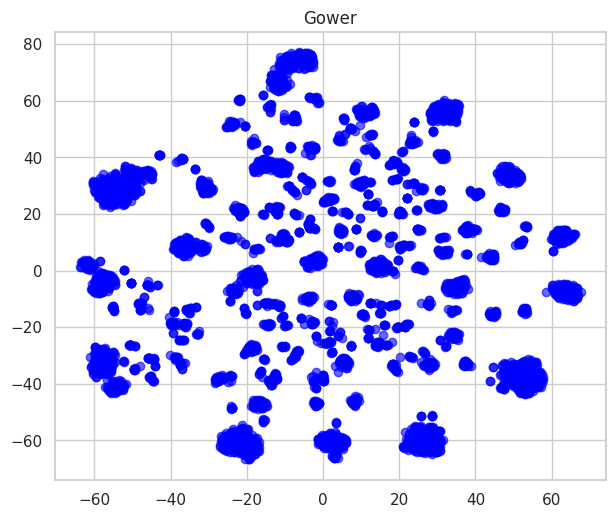

In [ ]:
from sklearn.manifold import TSNE
from sklearn.utils import check_random_state
from sklearn.preprocessing import LabelEncoder

# X is already defined - see above

# For reproducibility
random_state = check_random_state(42)

# Function to perform t-SNE with specified distance and display the result
def plot_tsne(X, metric, title, subplot_position):
    # Changed 'pca' to 'random' for precomputed distance
    tsne = TSNE(learning_rate='auto', init='random', random_state=random_state, metric=metric)
    Y = tsne.fit_transform(X)
    plt.subplot(2, 2, subplot_position)
    plt.scatter(Y[:, 0], Y[:, 1], c='blue', alpha=0.6)
    plt.title(title)
    plt.grid(True, alpha=0.3)

# Let's try different metrics and see what happens
# Create chart
plt.figure(figsize=(12, 10))



# t-SNE with distance = 'Gower'
tsne = TSNE(metric='precomputed', random_state=42, init='random')
Y_gower = tsne.fit_transform(gower_distances)

plt.subplot(2, 2, 4)
plt.scatter(Y_gower[:, 0], Y_gower[:, 1], c='blue', alpha=0.6)
plt.title('Gower')

# Show everything
plt.tight_layout()
plt.show()


Now we test different values of perplexity

Elaborazione t-SNE: Perplexity = 30...
Elaborazione t-SNE: Perplexity = 40...
Elaborazione t-SNE: Perplexity = 50...
Elaborazione t-SNE: Perplexity = 60...
Elaborazione t-SNE: Perplexity = 90...


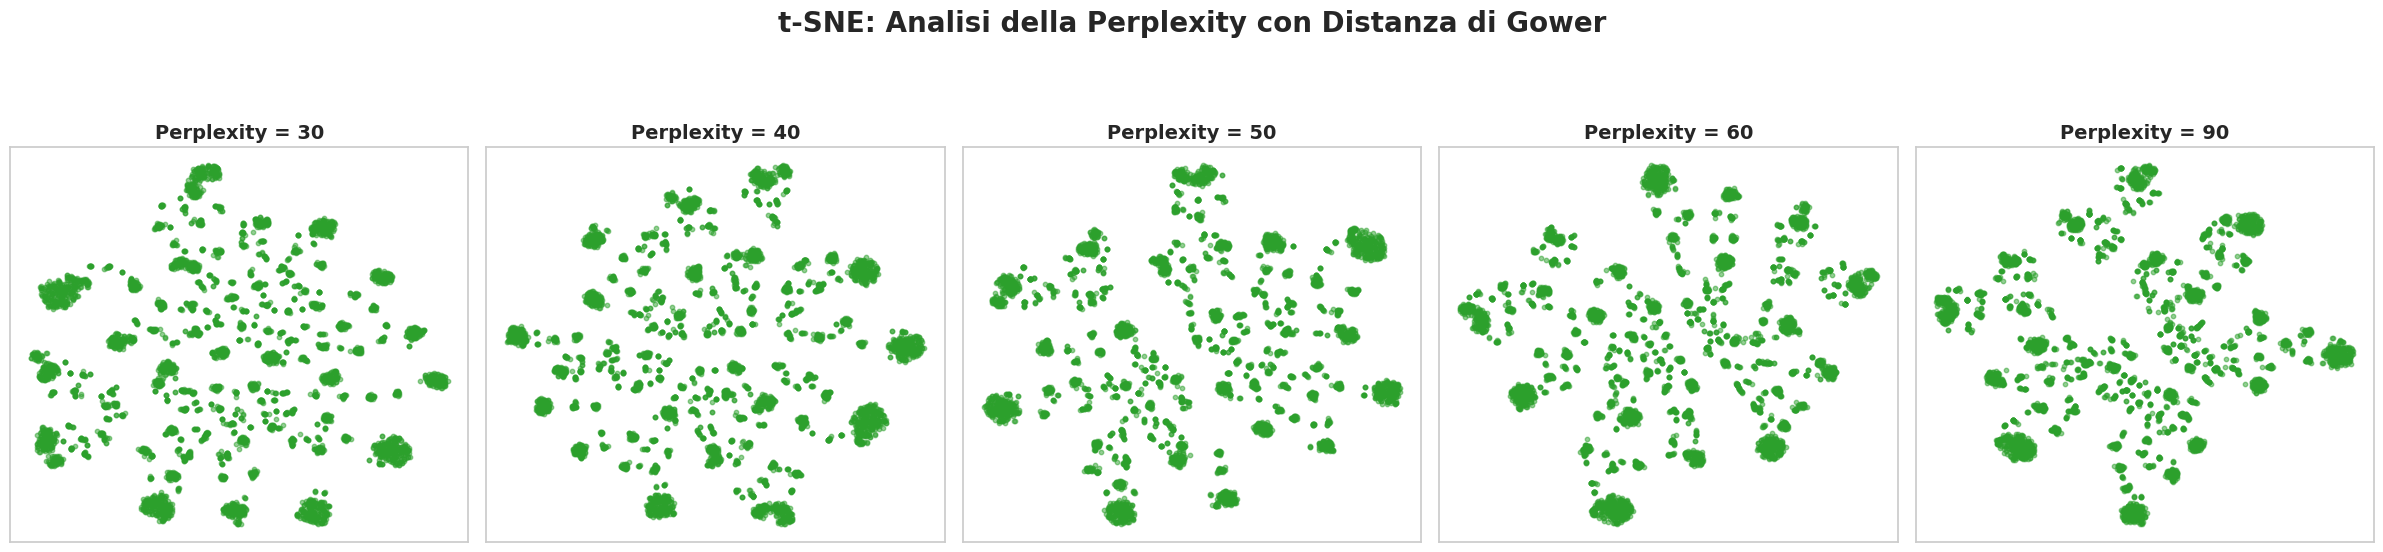

In [ ]:
import matplotlib.pyplot as plt

# Grid to test perplexity
perplexities = [30, 40, 50, 60, 90]

# Prepare the figure with 1 row and 5 columns (perplexities)
fig, axes = plt.subplots(1, len(perplexities), figsize=(24, 5))
fig.suptitle('t-SNE: Analisi della Perplexity con Distanza di Gower', fontsize=20, fontweight='bold', y=1.1)



# Single loop just to test perplexity values
for col_idx, perp in enumerate(perplexities):
    print(f"Elaborazione t-SNE: Perplexity = {perp}...")

    # t-SNE configuration for the precomputed Gower metric
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=1500,
        metric='precomputed',
        init='random',
        random_state=random_state,
        learning_rate='auto'
    )

    # Calculate 2D projections
    Y = tsne.fit_transform(gower_distances)
    color = '#2ca02c' # Green for Gower
    title = f"Perplexity = {perp}"

    # Draw the single plot in the grid
    ax = axes[col_idx]
    ax.scatter(Y[:, 0], Y[:, 1], c=color, alpha=0.5, s=10)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks([]) # Remove axis ticks (they mean nothing in t-SNE)
    ax.set_yticks([])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analysis of the t-SNE projection with the Gower distance reveals strong fragmentation, with the formation of several microclusters, some slightly denser than others.

We tested different perplexity values, trying to optimize the visualization. However, despite slight improvements, a dense breakdown into small groups remains.

The Gower metric approach to handling categorical variables is responsible for this extreme fragmentation. By performing a strictly binary comparison, Gower tends to force customers with identical categorical profiles into separate 'islands'.


## Weighed Distances

As mentioned before, to try to bring out useful Macro-Personas for the bank, we built a custom hybrid distance metric, based on the choice of Manhattan distance for the numeric variables and Jaccard and Dice for the categorical variables.

In defining business weights before arriving at this configuration we made many attempts. At first, we didn't get good segmentation, so we realized that the only way to get commercially sensible groups was to take the signals that emerged during EDA and give those variables a higher weight.

That's why we've given significantly more weight to features like Income, Wealth, Digital, Bankfriend, Debt, Savings, ESG, and Investments. Thinking about it in our opinion for a bank, knowing how a customer manages savings, how loyal they are, whether they are independent on the app or whether they invest in the green, matters more than other purely demographic details. This final calibration is simply the one that gave us the clearest and most realistic segments.

In [ ]:
# Definition of weights
pesi_business = {

    'Age': 1.0,
    'FamilySize': 0.5,


    'Income': 2.0,
    'Wealth': 2.0,


    'Luxury': 1.5,
    'Digital': 3.0,
    'FinEdu': 2.5,
    'LifeStyle': 1.0,


    'ESG': 2.0,
    'BankFriend': 2.0,



    'Debt': 4.0,
    'Saving': 4.0,


    'Gender': 0.5,
    'Area': 0.5,
    'CitySize': 0.5,
    'Job': 1.0,
    'Investments': 3.0
}


In [ ]:

# PREPARATION OF BUSINESS WEIGHTS FOR DISTANCE CALCULATION

# HANDLING NUMERICAL VARIABLES
# Physically merge the normalized numerical matrix with the pre-normalized numerical matrix
X_num_combined = np.hstack((X_num, X_other))

# Extract the weights from the 'pesi_business' dictionary strictly following the order
# in which the variables appear in our original lists.

weights_num = [pesi_business[col] for col in numerical_columns]
weights_other = [pesi_business[col] for col in other_columns]

# Combine the two lists of weights into a single array
weights_num_combined = weights_num + weights_other


# HANDLING CATEGORICAL VARIABLES (One-Hot Encoded)
weights_cat = []
for col in encoded_cat_columns:
    # Use split('_')[0] to extract the original variable name.
    original_col = col.split('_')[0]

    # Fetch the weight of "Job" from the dictionary and assign it to the "Job_1" column.
    # The loop will repeat the operation for "Job_2", "Job_3", etc.
    weights_cat.append(pesi_business[original_col])

# Now we have two arrays (weights_num_combined and weights_cat) perfectly aligned with our matrices

## T - SNE + Dice-CityBlock Distance

Calcolo distanza Numerica (Manhattan pesata)...
Calcolo distanza Categorica (Dice pesata)...
Lancio il t-SNE sulla matrice normalizzata...


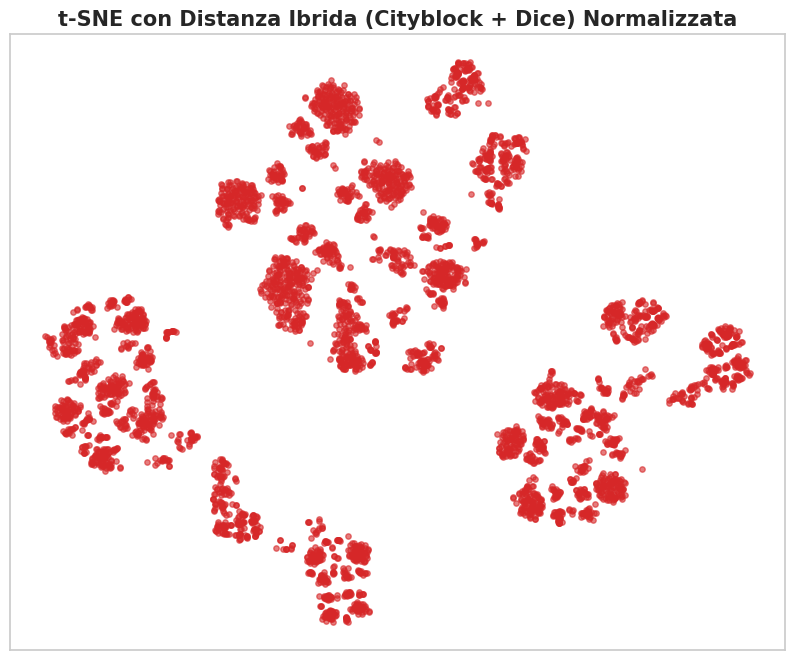

In [ ]:
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


print("Calcolo distanza Numerica (Manhattan pesata)...")
# pdist returns a vector, squareform transforms it into an N x N square matrix.
dist_num = squareform(pdist(X_num_combined, metric='cityblock', w=weights_num_combined))

print("Calcolo distanza Categorica (Dice pesata)...")
dist_cat = squareform(pdist(X_cat, metric='dice', w=weights_cat))

# if two clients have no category in common, the Dice formula might generate a NaN
# due to division by zero. We replace NaNs with 0.0 to prevent the algorithm from crashing.
dist_cat = np.nan_to_num(dist_cat, nan=0.0)


# Distance normalization:
# Numerical distance can reach high values, while Dice is mathematically confined between 0 and 1.


# We normalize the numerical matrix by dividing it by its absolute maximum value.
dist_num_norm = dist_num / np.max(dist_num)

# We divide by its actual maximum in the dataset to ensure that
# both matrices have exactly the same "specific weight" in the final sum.
max_cat = np.max(dist_cat)
if max_cat > 0:
    dist_cat_norm = dist_cat / max_cat
else:
    dist_cat_norm = dist_cat


# We sum the two matrices to create our Final Hybrid Metric
dice_cityblock_distance_matrix = dist_num_norm + dist_cat_norm


print("Lancio il t-SNE sulla matrice normalizzata...")
tsne_custom = TSNE(
    n_components=2,
    perplexity=60,   # High value to capture the global structure and macro-islands
    max_iter=1500,   # More iterations to allow points to stabilize
    metric='precomputed',
    init='random',
    random_state=42
)

# We apply t-SNE by passing the dataset 'X', but we directly pass
# our N x N distance matrix.
Y_custom = tsne_custom.fit_transform(dice_cityblock_distance_matrix)

# Scatter Plot generation
plt.figure(figsize=(10, 8))
# Plot the projected points. The color '#d62728' is an elegant dark red.
plt.scatter(Y_custom[:, 0], Y_custom[:, 1], c='#d62728', alpha=0.6, s=15)

plt.title('t-SNE con Distanza Ibrida (Cityblock + Dice) Normalizzata', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

# Remove numerical axis labels (xticks, yticks)
plt.xticks([])
plt.yticks([])
plt.show()





The graph shows an improvement compared to the projection obtained with Gower. Excessive fragmentation of points disappears, giving way to slightly larger and more defined groups. The combined action of the Manhattan distance and the Dice index allowed similar profiles to aggregate into denser and more cohesive macro-clouds, making the structure of potential clusters visually clear and interpretable.

## T-SNE: MANHATTAN + JACCARD

Calcolo distanza Numerica (Manhattan pesata)...
Calcolo distanza Categorica (Jaccard pesata)...
Lancio il t-SNE sulla matrice normalizzata...


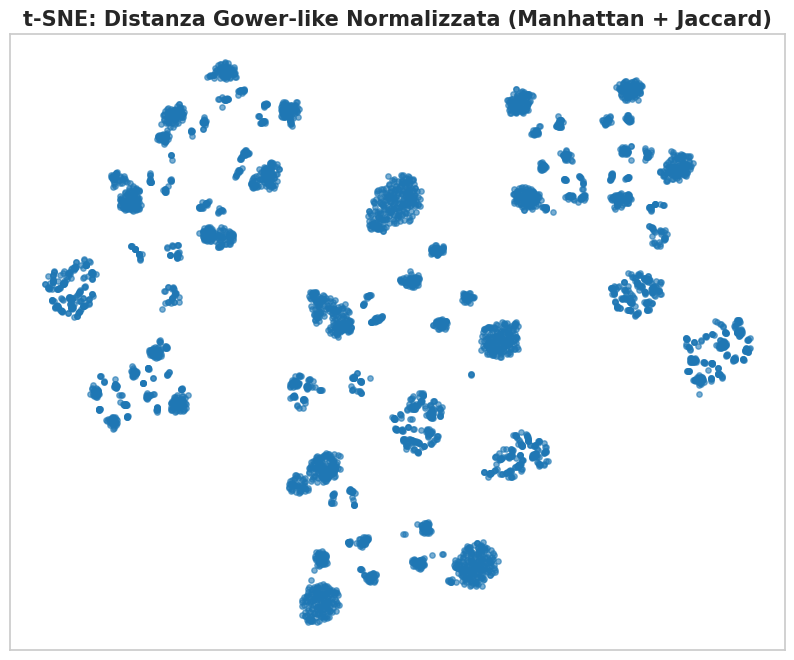

In [ ]:
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


print("Calcolo distanza Numerica (Manhattan pesata)...")
dist_num = squareform(pdist(X_num_combined, metric='cityblock', w=weights_num_combined))

print("Calcolo distanza Categorica (Jaccard pesata)...")
dist_cat = squareform(pdist(X_cat, metric='jaccard', w=weights_cat))

# Safety against NaNs
dist_num = np.nan_to_num(dist_num, nan=0.0)
dist_cat = np.nan_to_num(dist_cat, nan=0.0)


# Normalize the numerical distance (Manhattan) by its maximum value.
# By dividing by the maximum, we force all values into the [0, 1] range.
max_num = np.max(dist_num)
if max_num > 0:
    dist_num_norm = dist_num / max_num
else:
    dist_num_norm = dist_num

# Normalize the categorical distance.
# Mathematically, Jaccard is already confined between 0 and 1, but we still perform
# the division by the actual maximum observed in the dataset to ensure
# total symmetry and mathematical cleanliness.
max_cat = np.max(dist_cat)
if max_cat > 0:
    dist_cat_norm = dist_cat / max_cat
else:
    dist_cat_norm = dist_cat

# We sum them to create our weighted "Gower-like" hybrid distance.
jaccard_manhattan_distance_matrix = dist_num_norm + dist_cat_norm


# VISUAL TEST WITH T-SNE
print("Lancio il t-SNE sulla matrice normalizzata...")
tsne_custom = TSNE(
    n_components=2,
    perplexity=60,   # High value to capture the global structure
    max_iter=1500,
    metric='precomputed',
    init='random',
    random_state=42
)

# Apply dimensionality reduction starting from the distance matrix
Y_custom = tsne_custom.fit_transform(jaccard_manhattan_distance_matrix)


# PLOTTING THE RESULT
plt.figure(figsize=(10, 8))
plt.scatter(Y_custom[:, 0], Y_custom[:, 1], c='#1f77b4', alpha=0.6, s=15)

plt.title('t-SNE: Distanza Gower-like Normalizzata (Manhattan + Jaccard)', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.xticks([])
plt.yticks([])
plt.show()

The application of the hybrid metric based on the Jaccard index and the Manhattan distance confirms and strengthens the evidence that emerged with the previous Dice variant. Even in this two-dimensional projection, we note the complete disappearance of the grid effect and artificial fragmentation.

We can observe some dense clusters.

Now we test different values of perplexity with this two distances

Elaborazione: Metrica = Manhattan + Jaccard, Perplexity = 30...
Elaborazione: Metrica = Manhattan + Jaccard, Perplexity = 40...
Elaborazione: Metrica = Manhattan + Jaccard, Perplexity = 50...
Elaborazione: Metrica = Manhattan + Jaccard, Perplexity = 60...
Elaborazione: Metrica = Manhattan + Jaccard, Perplexity = 90...
Elaborazione: Metrica = Manhattan + Dice, Perplexity = 30...
Elaborazione: Metrica = Manhattan + Dice, Perplexity = 40...
Elaborazione: Metrica = Manhattan + Dice, Perplexity = 50...
Elaborazione: Metrica = Manhattan + Dice, Perplexity = 60...
Elaborazione: Metrica = Manhattan + Dice, Perplexity = 90...


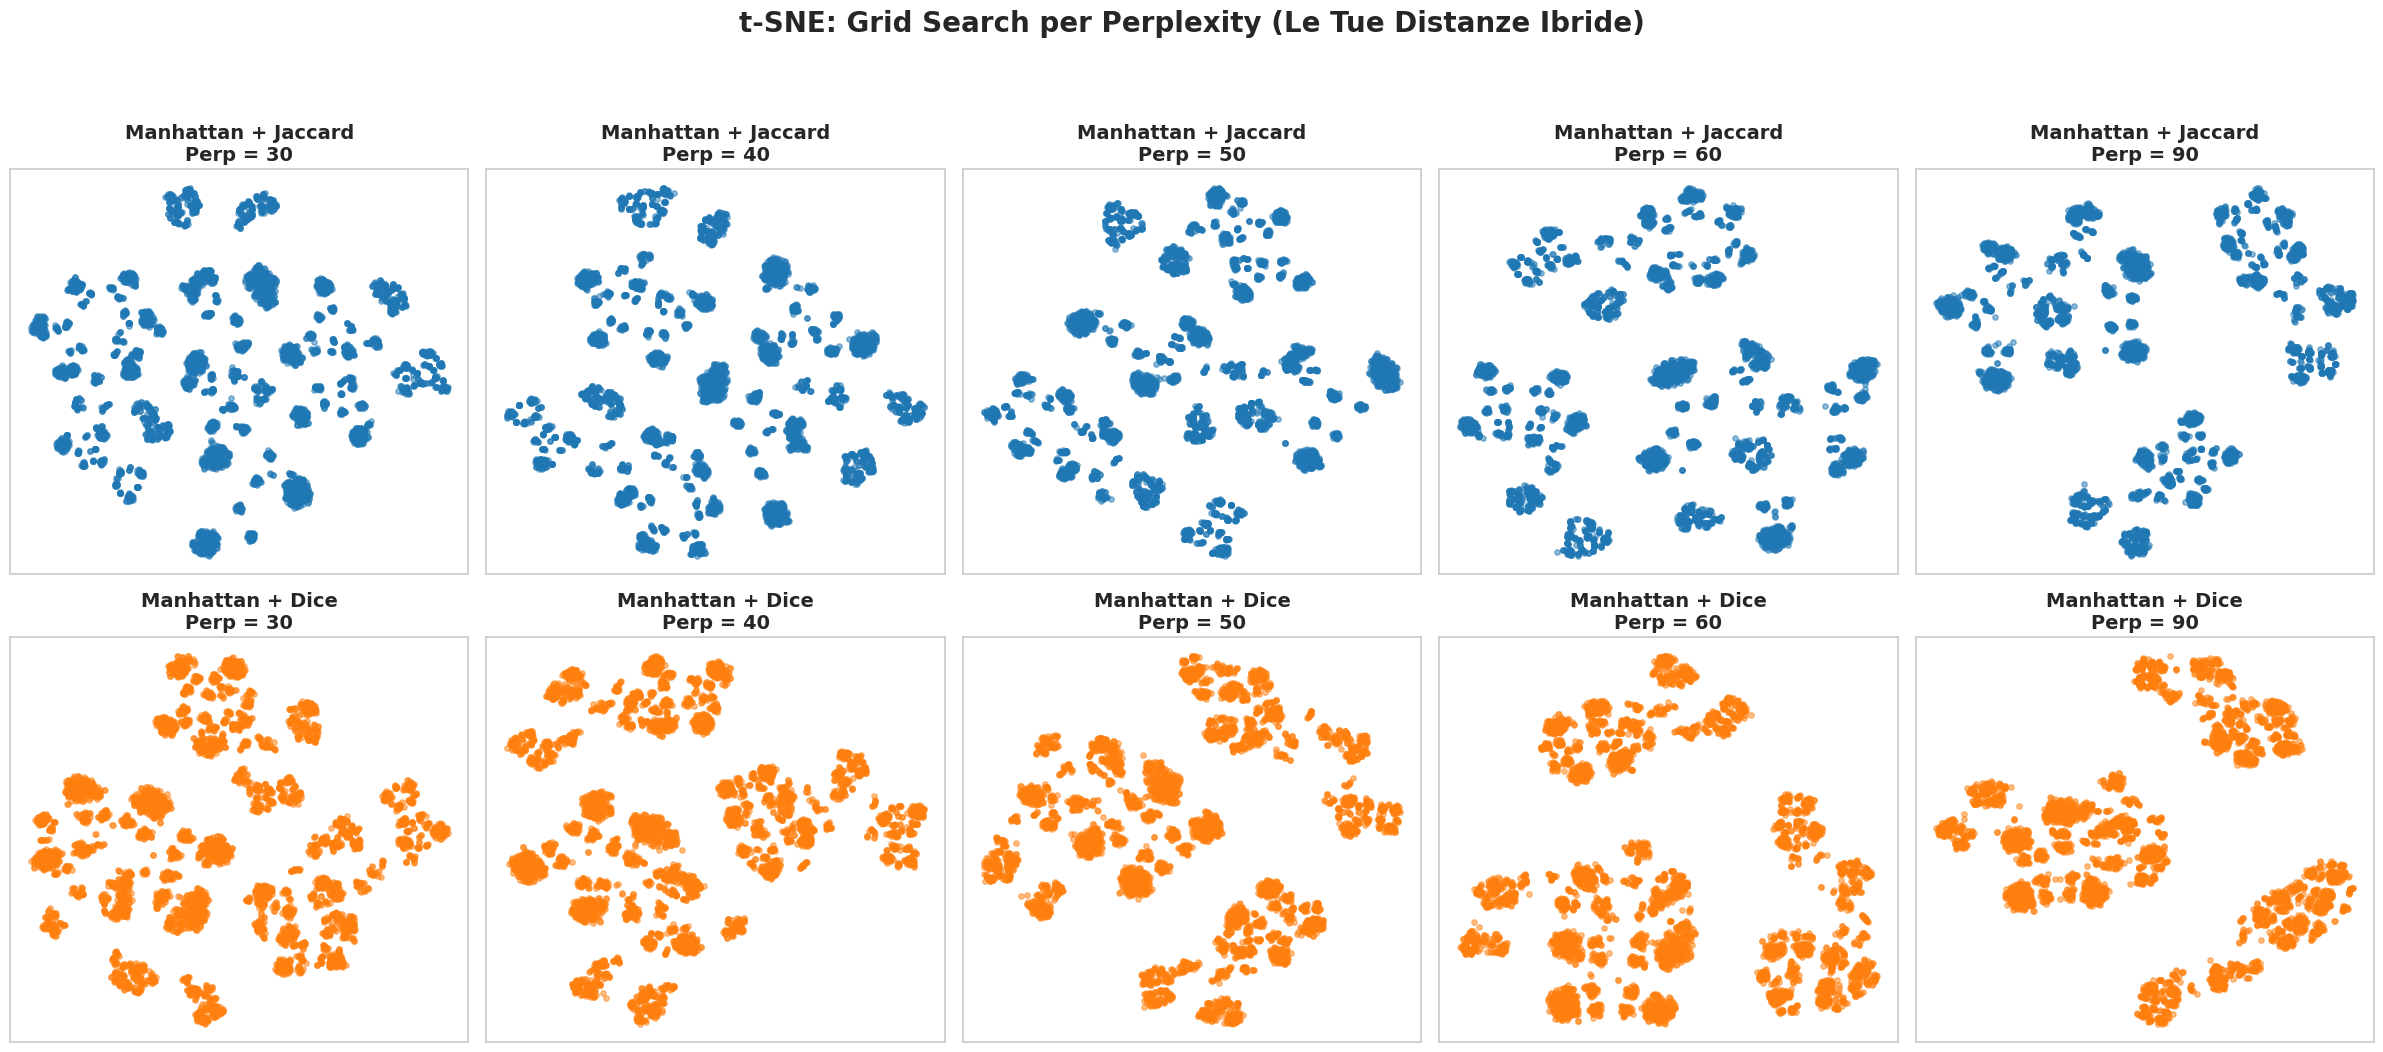

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.utils import check_random_state

# Fix the seed
random_state = check_random_state(42)

# Grid for perplexity
perplexities = [30, 40, 50, 60, 90]


custom_metrics = {
    'Manhattan + Jaccard': jaccard_manhattan_distance_matrix,
    'Manhattan + Dice': dice_cityblock_distance_matrix
}

# Prepare the figure with 2 rows (your 2 custom metrics) and 5 columns (perplexities)
fig, axes = plt.subplots(len(custom_metrics), len(perplexities), figsize=(24, 10))
fig.suptitle('t-SNE: Grid Search per Perplexity (Le Tue Distanze Ibride)', fontsize=20, fontweight='bold', y=1.05)

# Iterate directly over the dictionary: we get both the name and the matrix!
for row_idx, (metric_name, current_matrix) in enumerate(custom_metrics.items()):

    # Choose a different color per row to make it nicer (Blue for the first, Orange for the second)
    color = '#1f77b4' if row_idx == 0 else '#ff7f0e'

    for col_idx, perp in enumerate(perplexities):
        print(f"Elaborazione: Metrica = {metric_name}, Perplexity = {perp}...")

        # Initialize t-SNE (Both now use 'precomputed'!)
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            max_iter=1500,
            metric='precomputed',
            init='random',
            random_state=random_state,
            learning_rate='auto'
        )

        # Transform the data using the current matrix
        Y = tsne.fit_transform(current_matrix)

        # Text for the title of each single plot
        title = f"{metric_name}\nPerp = {perp}"

        # Draw the single plot in the grid
        ax = axes[row_idx, col_idx]
        ax.scatter(Y[:, 0], Y[:, 1], c=color, alpha=0.5, s=15)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks([]) # Remove the numbers on the axes
        ax.set_yticks([])
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

By testing different perplexity values we can observe small but significant improvements in the dimensional projection. By optimizing this hyperparameter, the inter-cluster distances stabilize and the previously identified macro-groups are visually sharper, more compact and defined in their boundaries. This test confirms that our aggregations are robust and become even more readable when the algorithm is optimally calibrated to the density of our dataset.

## UMAP + distance(dice + manhattan)

After exploring the data with t-SNE, we apply another dimensionality reduction algorithm: UMAP (Uniform Manifold Approximation and Projection).

The main reason for this choice is to overcome a known mathematical limitation of t-SNE: the inability to preserve global distances. While t-SNE is suitable for showing local structure, UMAP can also keep global structure intact.


Lancio UMAP in 2D sulla matrice pesata...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


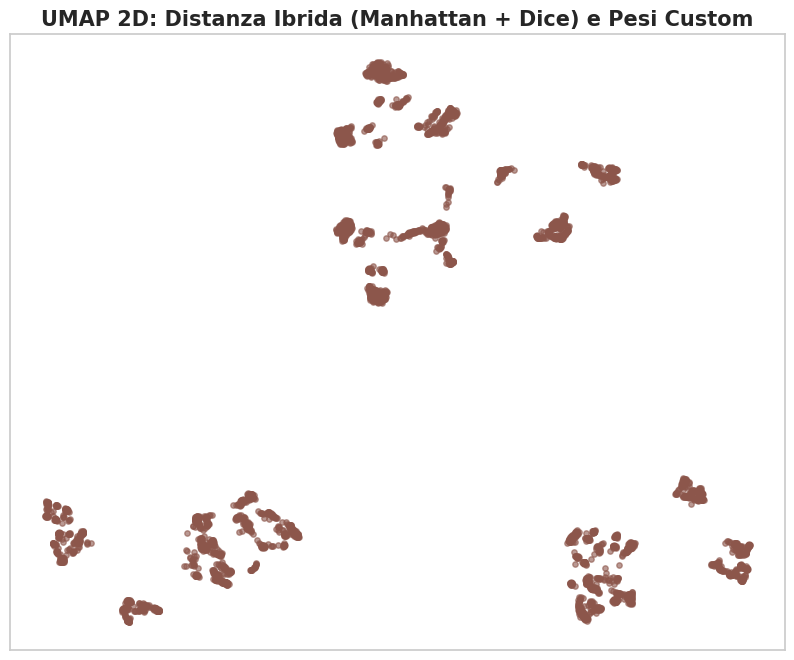

Lancio UMAP in 3D sulla matrice pesata...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


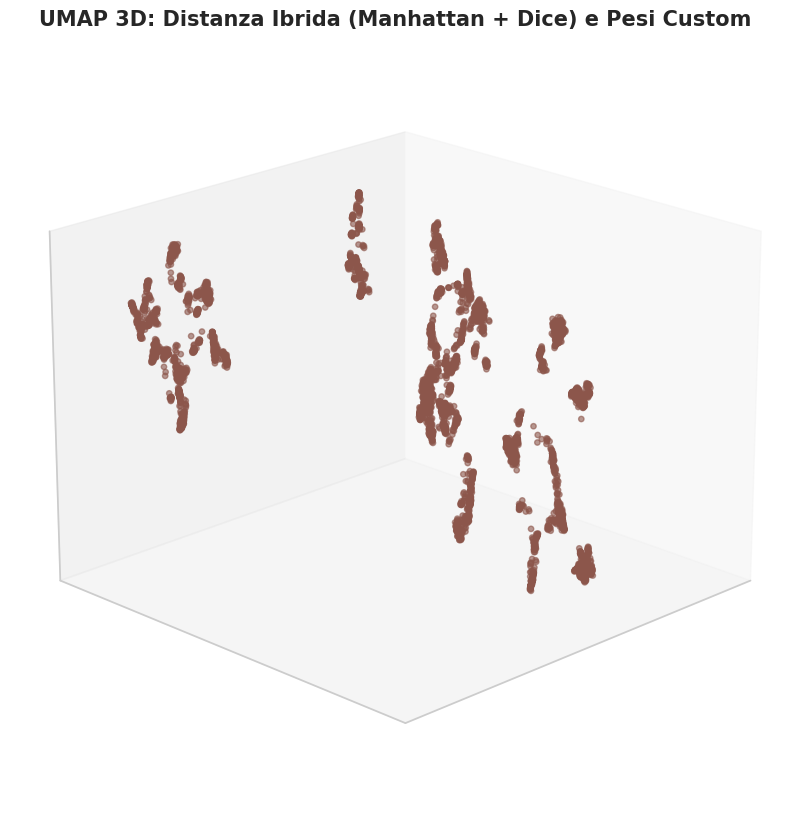

In [ ]:

import umap
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import numpy as np


print("Lancio UMAP in 2D sulla matrice pesata...")
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,       # 30 balances attention well between local and global structure
    min_dist=0.1,         # Controls how tightly points can be compressed together
    metric='precomputed', # Tell UMAP to use our hybrid matrix
    random_state=42       # Ensures the reproducibility of the plot on each run
)

# Apply UMAP to the distance matrix
Y_umap_2d = umap_2d.fit_transform(dice_cityblock_distance_matrix)

# 2D plot generation
plt.figure(figsize=(10, 8))
plt.scatter(Y_umap_2d[:, 0], Y_umap_2d[:, 1], c='#8c564b', alpha=0.6, s=15)

plt.title('UMAP 2D: Distanza Ibrida (Manhattan + Dice) e Pesi Custom', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks([])
plt.yticks([])
plt.show()



# UMAP AND 3D PLOT
print("Lancio UMAP in 3D sulla matrice pesata...")
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='precomputed',
    random_state=42
)

Y_umap_3d = umap_3d.fit_transform(dice_cityblock_distance_matrix)

# 3D plot generation
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot using the three extracted components
ax.scatter(Y_umap_3d[:, 0], Y_umap_3d[:, 1], Y_umap_3d[:, 2],
           c='#8c564b', alpha=0.6, s=15)

ax.set_title('UMAP 3D: Distanza Ibrida (Manhattan + Dice) e Pesi Custom', fontsize=15, fontweight='bold')

# Clean the 3D view by removing spatial axis labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev=20, azim=45)
plt.show()

## UMAP: manhattan + jaccard

Lancio UMAP in 2D sulla matrice pesata...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


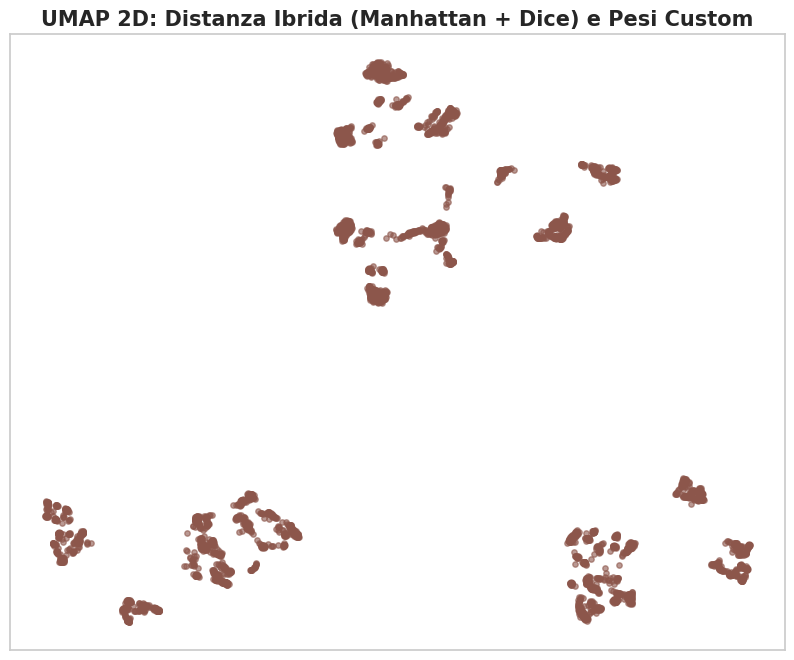

Lancio UMAP in 3D sulla matrice pesata...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


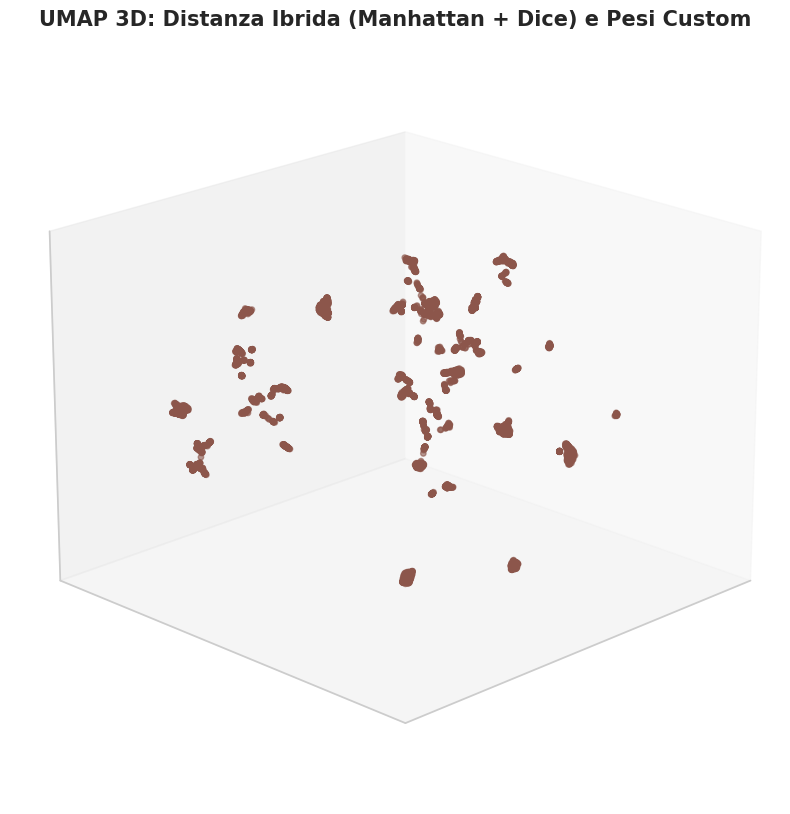

In [ ]:

import umap
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import numpy as np


# UMAP AND 2D PLOT

print("Lancio UMAP in 2D sulla matrice pesata...")
umap_2d = umap.UMAP(
    n_components=2,       # Planar projection (X and Y axes)
    n_neighbors=30,       # Balances attention between local and global structure (30 is an optimal value for datasets of this size)
    min_dist=0.1,         # Controls the visual compactness of the clusters
    metric='precomputed', # Crucial: instructs the algorithm not to recalculate distances, but to rely on our custom hybrid matrix
    random_state=42       # Fixed seed to guarantee exact reproducibility of the plot
)

# Apply the algorithm to the Dice and Manhattan-based matrix
Y_umap_2d = umap_2d.fit_transform(dice_cityblock_distance_matrix)

plt.figure(figsize=(10, 8))
# Generate the scatter plot. The color '#8c564b' (terracotta) visually differentiates UMAP from t-SNE
plt.scatter(Y_umap_2d[:, 0], Y_umap_2d[:, 1], c='#8c564b', alpha=0.6, s=15)
plt.title('UMAP 2D: Distanza Ibrida (Manhattan + Dice) e Pesi Custom', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)

# Remove numerical ticks from the axes
plt.xticks([])
plt.yticks([])
plt.show() # Show and close the first plot


# UMAP AND 3D PLOT

print("Lancio UMAP in 3D sulla matrice pesata...")
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='precomputed',
    random_state=42
)

# Here we are passing the Jaccard-based matrix
Y_umap_3d = umap_3d.fit_transform(jaccard_manhattan_distance_matrix)

fig = plt.figure(figsize=(12, 10))
# Initialize a three-dimensional environment for the plot
ax = fig.add_subplot(111, projection='3d')

# Plot columns 0, 1, and 2 for the X, Y, and Z axes
ax.scatter(Y_umap_3d[:, 0], Y_umap_3d[:, 1], Y_umap_3d[:, 2],
           c='#8c564b', alpha=0.6, s=15)

ax.set_title('UMAP 3D: Distanza Ibrida (Manhattan + Dice) e Pesi Custom', fontsize=15, fontweight='bold')

# Clean the 3D view by removing labels for a sharper visualization
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.view_init(elev=20, azim=45)
plt.show()

Looking at the results obtained by applying UMAP at both distances, we can identify some dense and compact islands, others more elongated or sparse, and in some cases we see light 'bridges' connecting two groups, indicating customers who are in a transition phase between one behavior and another.

These results lead us to exclude a clustering method such as k-means that searches for spherical clusters.

# 2 - Clustering

In this section we test 4 clustering methods

1. K-Prototypes

2. Agglomerative Clustering

3. K-Medoids

4. DBSCAN

This cell takes the calculated distances and the set weights. It does not add any type of information, it is present for pure execution loan

In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

# =========================================
# PESI BUSINESS - controllati dal notebook
# =========================================
# Definizione dei pesi
pesi_business = {
    # --- VARIABILI DEMOGRAFICHE (Depotenziate) ---
    # Abbassiamo Age e Job. La banca sa già quanti anni hai, vogliamo
    # raggrupparti per come spendi, non per la tua carta d'identità!
    'Age': 1.0,          # Prima era 3.0
    'FamilySize': 0.5,   # Basso, è solo di contorno

    # --- STATUS ECONOMICO (Forte, ma non dominante) ---
    'Income': 2.0,       # Prima era 3.0
    'Wealth': 2.0,       # Prima era 3.0

    # --- COMPORTAMENTI DI CONSUMO E CANALE (Potenziati proporzionalmente) ---
    'Luxury': 1.5,       # Alzato un po' per trovare gli "spendaccioni"
    'Digital': 3.0,      # Fondamentale per decidere se vendere via App o Filiale
    'FinEdu': 2.5,       # Molto utile per capire se proporre prodotti complessi
    'LifeStyle': 1.0,

    # --- LE "STELLE" DI NICCHIA (Alzate per farle emergere) ---
    'ESG': 2.0,          # Alzato da 1.0 a 2.0 per far emergere i clienti "Green"
    'BankFriend': 2.0,   # Alzato per separare chi si fida della banca da chi è diffidente

    # --- IL CUORE DEL BUSINESS BANCARIO (Massima priorità) ---
    # Queste sono le variabili che spaccano il mega-cluster!
    'Debt': 4.0,         # EXTRA-PESO: Chi è super-indebitato deve finire in un cluster a parte
    'Saving': 4.0,       # EXTRA-PESO: Chi risparmia tanto è un target diversissimo da chi non lo fa

    # --- VARIABILI CATEGORICHE ---
    'Gender': 0.5,       # Quasi ininfluente
    'Area': 0.5,         # Quasi ininfluente
    'CitySize': 0.5,     # Quasi ininfluente
    'Job': 1.0,          # Prima era 3.0. Lo depotenziamo per evitare l'effetto "Pensionati vs Lavoratori"
    'Investments': 3.0   # Mantenuto alto: chi investe è un target cruciale
}
# =========================================
# COSTRUZIONE DELLE STRUTTURE USATE SOPRA
# =========================================

# GESTIONE SICURA DELLE MATRICI (Evita errori se X_other è vuoto)
if X_other.shape[1] > 0:
    X_num_combined = np.hstack((X_num, X_other))
else:
    X_num_combined = X_num

# Pesi numerici nello stesso ordine di X_num_combined
weights_num = [pesi_business[col] for col in numerical_columns]

# Filter out 'ID' from other_columns before fetching weights, as it's not a feature for weighting
# and was intended to be dropped from the dataset.
weights_other = [pesi_business[col] for col in other_columns if col != 'ID']
weights_num_combined = weights_num + weights_other

# Pesi categorici nello stesso ordine delle colonne one-hot
weights_cat = []
for col in encoded_cat_columns:
    original_col = col.split('_')[0]
    weights_cat.append(pesi_business[original_col])


# =========================================
# CALCOLO DISTANZA NUMERICA (Comune a entrambe)
# =========================================
print("Calcolo distanza Numerica (Manhattan pesata)...")
dist_num = squareform(pdist(X_num_combined, metric='cityblock', w=weights_num_combined))
dist_num = np.nan_to_num(dist_num, nan=0.0)

# --- NORMALIZZAZIONE NUMERICA ---
max_num = np.max(dist_num)
if max_num > 0:
    dist_num_norm = dist_num / max_num
else:
    dist_num_norm = dist_num


# =========================================
# 1. DICE + CITYBLOCK PESATA
# =========================================
print("Calcolo distanza Categorica (Dice pesata)...")
dist_cat_dice = squareform(pdist(X_cat, metric='dice', w=weights_cat))
dist_cat_dice = np.nan_to_num(dist_cat_dice, nan=0.0)

# --- NORMALIZZAZIONE DICE ---
max_dice = np.max(dist_cat_dice)
if max_dice > 0:
    dist_cat_dice_norm = dist_cat_dice / max_dice
else:
    dist_cat_dice_norm = dist_cat_dice

# Somma finale per Dice
dice_manhattan_distance_matrix = dist_num_norm + dist_cat_dice_norm


# =========================================
# 2. JACCARD + CITYBLOCK PESATA
# =========================================
print("Calcolo distanza Categorica (Jaccard pesata)...")
dist_cat_jaccard = squareform(pdist(X_cat, metric='jaccard', w=weights_cat))
dist_cat_jaccard = np.nan_to_num(dist_cat_jaccard, nan=0.0)

# --- NORMALIZZAZIONE JACCARD ---
max_jaccard = np.max(dist_cat_jaccard)
if max_jaccard > 0:
    dist_cat_jaccard_norm = dist_cat_jaccard / max_jaccard
else:
    dist_cat_jaccard_norm = dist_cat_jaccard

# Somma finale per Jaccard
jaccard_manhattan_distance_matrix = dist_num_norm + dist_cat_jaccard_norm


# =========================================
# DISTANZE DA PASSARE ALLA PARTE DI CLUSTERING
# =========================================
distance_matrices = {
    "dice_manhattan": dice_manhattan_distance_matrix,
    "jaccard_manhattan": jaccard_manhattan_distance_matrix
}

selected_distances = ["dice_manhattan", "jaccard_manhattan"]

print("Distanze calcolate e pronte per il clustering:", selected_distances)


Calcolo distanza Numerica (Manhattan pesata)...
Calcolo distanza Categorica (Dice pesata)...
Calcolo distanza Categorica (Jaccard pesata)...
Distanze calcolate e pronte per il clustering: ['dice_manhattan', 'jaccard_manhattan']


## Validation functions

To ensure the optimal choice of $K$ (optimal number of clusters), we developed an Internal Validation pipeline that calculates and compares three different mathematical metrics for each possible cluster configuration:

Silhouette Score: Measures the internal cohesion and external separation of clusters using our custom distance matrix.

Calinski-Harabasz Index (Variance Ratio Criterion): Evaluates the ratio between inter-cluster dispersion (how far the clusters are from each other) and intra-cluster dispersion (how compact they are).

Davies-Bouldin Index: Calculate the average 'similarity' between each cluster and its closest cluster. Since we want very distinct clusters, we look for the minimum possible value.

Since no metric is perfect for every scenario, we implemented a decision-making system robust to 'Ensemble Voting': the algorithm will extract the optimal $K$ suggested by each of the three metrics and choose the final number of clusters by calculating the median of the three outcomes.

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np


# Evaluation function to calculate the 3 quality metrics for each tested K value.

def evaluate_clustering_single_distance(processed_data, distance_matrix, clustering_results):

    # Extract all tested K values
    k_values = sorted(clustering_results.keys())

    # Initialize empty lists to store scores
    ch_scores = []
    db_scores = []
    sil_scores = []

    # Extract raw/processed data as a numpy array.

    X_eval = processed_data.values

    # Loop over each K configuration
    for k in k_values:
        # Retrieve the labels assigned by the algorithm for this specific K
        labels = clustering_results[k]["labels"]

        # Calinski-Harabasz
        ch_scores.append(calinski_harabasz_score(X_eval, labels))

        # Davies-Bouldin
        db_scores.append(davies_bouldin_score(X_eval, labels))

        # Silhouette
        sil_scores.append(silhouette_score(distance_matrix, labels, metric="precomputed"))

    return {
        "k_values": k_values,
        "calinski_harabasz": ch_scores,
        "davies_bouldin": db_scores,
        "silhouette": sil_scores
    }




# PLOTTING FUNCTION

def plot_clustering_validation(evaluation_results, selected_distances, method_name="Clustering"):

    n_dist = len(selected_distances)
    # Create a grid of plots: 1 row for each distance metric
    fig, axes = plt.subplots(n_dist, 3, figsize=(15, 4 * n_dist))

    # Handle the case where only one distance is passed (avoids indexing errors in matplotlib)
    if n_dist == 1:
        axes = np.array([axes])

    for i, dist_name in enumerate(selected_distances):
        results = evaluation_results[dist_name]
        k_values = results["k_values"]

        # Plot 1: Calinski-Harabasz
        axes[i, 0].plot(k_values, results["calinski_harabasz"], marker="o", color="#3949ab")
        axes[i, 0].set_title(f"{method_name} + {dist_name} - Calinski-Harabasz")
        axes[i, 0].set_xlabel("Number of clusters")
        axes[i, 0].grid(True, alpha=0.3)

        # Plot 2: Davies-Bouldin
        axes[i, 1].plot(k_values, results["davies_bouldin"], marker="o", color="#e53935")
        axes[i, 1].set_title(f"{method_name} + {dist_name} - Davies-Bouldin")
        axes[i, 1].set_xlabel("Number of clusters")
        axes[i, 1].grid(True, alpha=0.3)

        # Plot 3: Silhouette Score
        axes[i, 2].plot(k_values, results["silhouette"], marker="o", color="#43a047")
        axes[i, 2].set_title(f"{method_name} + {dist_name} - Silhouette")
        axes[i, 2].set_xlabel("Number of clusters")
        axes[i, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


import numpy as np

# AUTOMATIC SELECTION FUNCTION

def select_k_clustering(validation_results, selected_distances, verbose=True):

    final_k_results = {}

    for dist_name in selected_distances:

        results = validation_results[dist_name]

        k_values = results["k_values"]
        ch_scores = results["calinski_harabasz"]
        db_scores = results["davies_bouldin"]
        sil_scores = results["silhouette"]

        # Find the K that maximizes (argmax) Calinski-Harabasz
        ch_opt = k_values[np.argmax(ch_scores)]

        # Find the K that minimizes (argmin) Davies-Bouldin
        db_opt = k_values[np.argmin(db_scores)]

        # Find the K that maximizes (argmax) Silhouette
        sil_opt = k_values[np.argmax(sil_scores)]

        # Evaluation logic using the median
        final_k = int(np.median([ch_opt, db_opt, sil_opt]))

        if verbose:
            print(f"\nDistance: {dist_name}")
            print(f"Optimal k according to Calinski-Harabasz: {ch_opt}")
            print(f"Optimal k according to Davies-Bouldin: {db_opt}")
            print(f"Optimal k according to Silhouette: {sil_opt}")
            print(f"Final decision (median vote): {final_k}")

        # Save the results to use them in the final clustering
        final_k_results[dist_name] = {
            "ch": ch_opt,
            "db": db_opt,
            "sil": sil_opt,
            "final_k": final_k
        }

    return final_k_results

## Plot functions

Once the clustering algorithm has processed the data and assigned each customer their membership label, it is essential to visually inspect the result.

To evaluate the results, we prepared some visualizations based on t-SNE. By combining a classical 2D view (with Matplotlib) with an interactive 3D exploration (with Plotly), we can literally 'navigate' through clusters to visually assess their density and separation.

In [ ]:
# PRE-COMPUTATION FUNCTION that calculates in advance the 3D t-SNE coordinates for all distances.
# This avoids having to recalculate t-SNE every time we plot a graph.

from sklearn.manifold import TSNE

def compute_tsne_embeddings_3d(distance_matrices, selected_distances,
                               perplexity=20, random_state=42,
                               init='random', learning_rate='auto'):
    tsne_embeddings_3d = {}

    for dist_name in selected_distances:
        # Initialize t-SNE by setting 3 dimensions
        tsne_3d = TSNE(
            n_components=3,
            metric='precomputed', # We always use our hybrid metric!
            perplexity=perplexity,
            init=init,
            random_state=random_state,
            learning_rate=learning_rate
        )

        # Save the calculated coordinates in the dictionary
        tsne_embeddings_3d[dist_name] = tsne_3d.fit_transform(distance_matrices[dist_name])

    return tsne_embeddings_3d


# INTERACTIVE 3D PLOTTING FUNCTION: Create three-dimensional graphs that we can "navigate" with the mouse,
# coloring the points based on the clusters calculated by our algorithm.

import plotly.graph_objects as go

def plot_final_clustering_3d_plotly(final_models, tsne_embeddings_3d, selected_distances, method_name="Clustering"):

    for dist_name in selected_distances:

        # Extract the labels assigned by the algorithm and the final K
        labels = final_models[dist_name]["labels"]
        k = final_models[dist_name]["k"]
        embedding = tsne_embeddings_3d[dist_name]

        # Initialize the interactive graphic object
        fig = go.Figure()

        # Add the three-dimensional scatter plot
        fig.add_trace(go.Scatter3d(
            x=embedding[:, 0], # X axis
            y=embedding[:, 1], # Y axis
            z=embedding[:, 2], # Z axis (Depth)
            mode='markers',
            marker=dict(
                size=5,
                color=labels,       # The color of the point corresponds to the cluster it belongs to!
                colorscale='Viridis',
                opacity=0.8
            ),
            # When hovering with the mouse, show the cluster number
            text=[f"Cluster {lab + 1}" for lab in labels],
            hoverinfo="text"
        ))

        # Aesthetic formatting of the layout
        fig.update_layout(
            title=f"{method_name} clustering ({dist_name}, k={k})",
            scene=dict(
                xaxis_title="t-SNE 1",
                yaxis_title="t-SNE 2",
                zaxis_title="t-SNE 3"
            ),
            margin=dict(l=0, r=0, b=0, t=40) # Removes unnecessary white margins
        )

        fig.show()



# STATIC 2D PLOTTING FUNCTION to display 2D graphs side by side

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_clustering_tsne_2d_all_distances(distance_matrices, final_models,
                                          selected_distances,
                                          perplexity=20, random_state=42):

    n_dist = len(selected_distances)
    # Set 2 columns and calculate how many rows are needed
    ncols = 2
    nrows = int(np.ceil(n_dist/ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12,5*nrows))
    # Flatten the axes array to easily loop over it
    axes = np.array(axes).reshape(-1)

    for i, dist_name in enumerate(selected_distances):

        labels = final_models[dist_name]["labels"]
        k = final_models[dist_name]["k"]

        # Unlike the 3D function, here we calculate t-SNE on the fly
        tsne = TSNE(
            n_components=2,
            metric='precomputed',
            perplexity=perplexity,
            init='random',
            random_state=random_state,
            learning_rate='auto'
        )

        Y = tsne.fit_transform(distance_matrices[dist_name])

        # Create the two-dimensional scatter plot
        sc = axes[i].scatter(
            Y[:,0],
            Y[:,1],
            c=labels,             # Coloring based on the model labels
            cmap='viridis',
            alpha=0.7,
            edgecolors='k',       # Black edge around the points for greater definition
            s=35
        )

        axes[i].set_title(f"t-SNE 2D ({dist_name}, k={k})")
        axes[i].grid(True, alpha=0.3)

        # Add the color bar on the side to understand which color is which cluster
        fig.colorbar(sc, ax=axes[i], label="Cluster")

    # If there is an empty subplot, delete it
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# A) K-prototypes

K-Prototypes is a clustering algorithm specifically designed to overcome the limitations of classical K-Means, which cannot process non-numeric variables. It is a fusion of two algorithms: K-Means (for continuous data) and K-Modes (for discrete data).

Unlike K-Medoids, this technique does not choose a real customer as the center, but "assembles" an artificial one: the Prototype. To understand how similar a customer is to this Prototype, the algorithm uses two weights and two measures: mean and Euclidean for the numerical data, mode and Simple Matching (0 if it coincides, 1 if it differs) for categorical ones. The real driver of everything, however, is the Gamma parameter ($\gamma$). Since we can't add apples (numbers) and pears (categories) without causing damage, Gamma is useful for balancing them. A high $\gamma$ forces the model to group customers primarily by category; a low $\gamma$, on the other hand, leaves the lead to purely financial and numerical data.


After defining the theoretical framework, we proceed with the practical implementation of K-Prototypes. In this phase, we will test different cluster configurations (from K=3 to K=6) and leverage our internal validation pipeline (Silhouette, Calinski-Harabasz, Davies-Bouldin) to obtain the optimal number of segments.

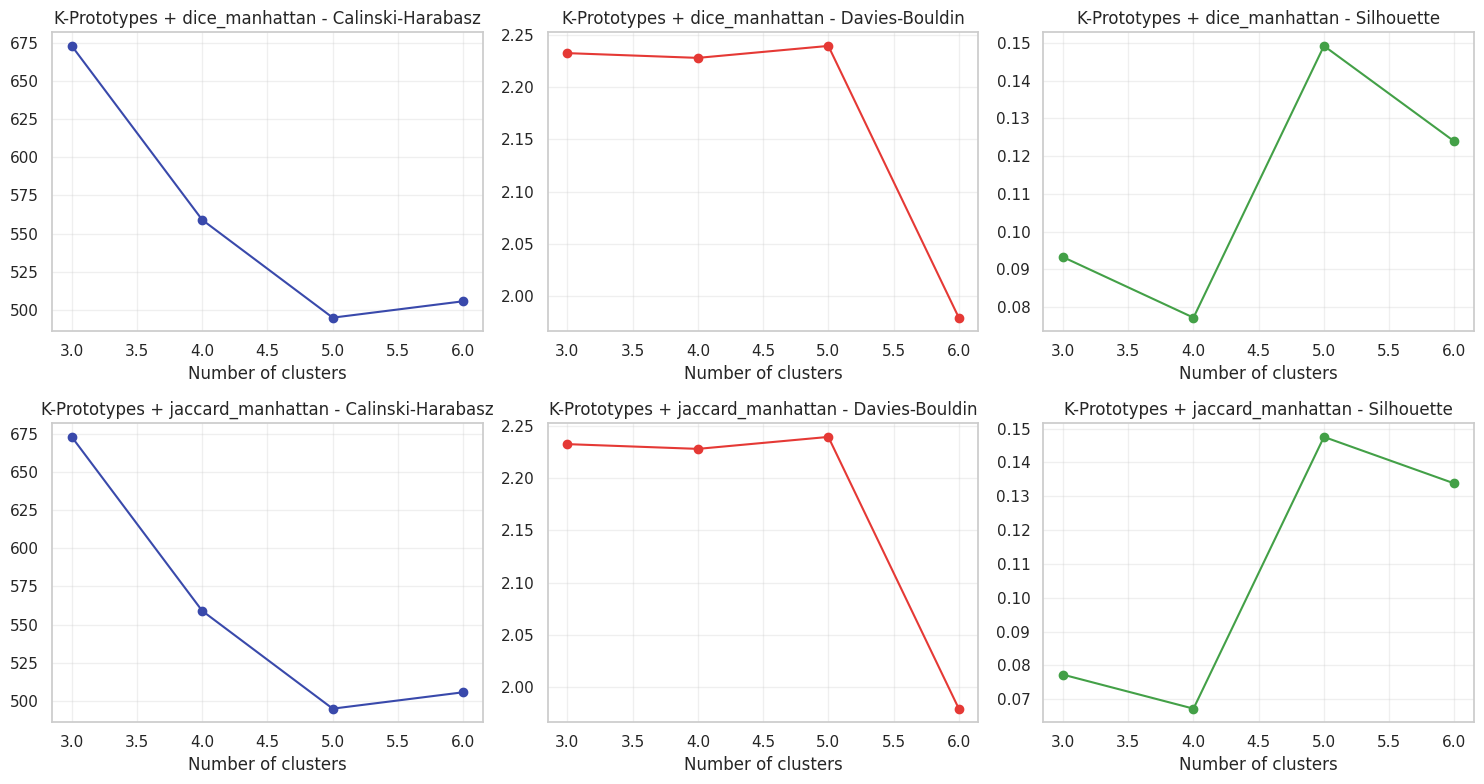


Distance: dice_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 6
Optimal k according to Silhouette: 5
Final decision (median vote): 5

Distance: jaccard_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 6
Optimal k according to Silhouette: 5
Final decision (median vote): 5


In [ ]:
!pip install kmodes
from kmodes.kprototypes import KPrototypes
import numpy as np


# FUNCTIONS: Defines the functions to train, iterate, and evaluate K-Prototypes


def run_kprototypes(X, categorical_indices, k, random_state=42):
    # Initialize the K-Prototypes model specifying the number of clusters (k)
    # 'Huang' initialization is the standard to optimize the choice of initial centroids
    # in mixed datasets.
    model = KPrototypes(
        n_clusters=k,
        init='Huang',
        random_state=random_state
    )

    # fit_predict assigns each client to their cluster.
    # It is crucial to pass the index of categorical columns so that the algorithm
    # knows where to apply Simple Matching (for categories) and where to apply Euclidean distance.
    labels = model.fit_predict(X, categorical=categorical_indices)

    return labels, model

def compute_kprototypes_solutions(X, categorical_indices, k_values):
    # Create an empty dictionary to save the results of each tested K
    results = {}

    # Iterate over all possible values of K
    for k in k_values:

        # Execute the previous function for the single K
        labels, model = run_kprototypes(
            X=X,
            categorical_indices=categorical_indices,
            k=k
        )

        # Save the generated labels and the model itself
        results[k] = {
            "labels": labels,
            "model": model
        }

    return results

def evaluate_kprototypes_multiple_distances(processed_data, distance_matrices, kprototypes_results, selected_distances):
    # Create a dictionary to save validation metrics
    evaluation_results = {}

    # Loop over the distance metrics we want to evaluate
    for dist_name in selected_distances:
        # Reuse our validation function (Silhouette, CH, DB)
        # to calculate how good the clusters created by K-Prototypes are
        evaluation_results[dist_name] = evaluate_clustering_single_distance(
            processed_data=processed_data,
            distance_matrix=distance_matrices[dist_name],
            clustering_results=kprototypes_results
        )

    return evaluation_results


# CODE: Prepares the data and executes massive training and validation
# K-Prototypes requires categorical data in their original format (not One-Hot Encoded)
# to be able to calculate the mathematical Mode. We then merge the original numerical and categorical data.
X_kproto_df = pd.concat(
    [numerical_features.reset_index(drop=True),
     categorical_features.reset_index(drop=True)],
    axis=1
)

# Convert the pandas dataframe into a NumPy 'object' type matrix,
# which is the native format required by the kmodes library
X_kproto = X_kproto_df.astype(object).to_numpy()

# Create a list with the numerical indices of all categorical columns.
categorical_columns_indices = list(range(len(numerical_features.columns), X_kproto.shape[1]))

# Define the K values to explore for finding the optimal number of clusters
k_values = [3,4,5,6]

# Run the calculation for all K values
kprototypes_results = compute_kprototypes_solutions(
    X=X,
    categorical_indices=categorical_columns_indices,
    k_values=k_values
)

# models

# Calculate validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
kprototypes_eval_results = evaluate_kprototypes_multiple_distances(
    processed_data=processed_data,
    distance_matrices=distance_matrices,
    kprototypes_results=kprototypes_results,
    selected_distances=selected_distances
)

# Print the metrics plots on screen for visual inspection
plot_clustering_validation(
    evaluation_results=kprototypes_eval_results,
    selected_distances=selected_distances,
    method_name="K-Prototypes"
)

# Entrust the algorithm (via median logic) with electing the definitive optimal K
kprototypes_final_k = select_k_clustering(
    validation_results=kprototypes_eval_results,
    selected_distances=selected_distances,
    verbose=True
)


We can observe that the optimal number of clusters for both distances is 5.

**Methodological note**: Although K-Prototypes uses its own internal metric (Euclidean + Simple Matching) to optimize and assign clusters, during validation we chose to evaluate the produced labels by projecting them onto our hybrid distance matrices (e.g. Jaccard-Manhattan). This choice is deliberate: using a single metric evaluation space for all algorithms is the only way to make Silhouette scores directly comparable between K-Prototypes, K-Medoids, and Agglomerative.

In [ ]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


# DEFINITIVE TRAINING FUNCTION: Extract the optimal K calculated in the previous validation phase
# and train the final K-Prototypes model to be used for profiling.

def compute_final_kprototypes_models(X, categorical_indices, final_k_results, selected_distances):
    # Initialize the dictionary that will contain our definitive models
    final_models = {}

    # Loop over the distances
    for dist_name in selected_distances:

        # EXTRACTION OF THE OPTIMAL K
        # We fetch the "final_k" (the one calculated with the median)
        # from the validation results dictionary.
        k = final_k_results[dist_name]["final_k"]

        # FINAL MODEL TRAINING
        # we launch the run_kprototypes function one last time to get the definitive labels
        labels, model = run_kprototypes(
            X=X,
            categorical_indices=categorical_indices,
            k=k
        )

        # SAVING
        # We pack the chosen K, the client labels, and the model object
        # to be able to analyze and plot them later
        final_models[dist_name] = {
            "k": k,
            "labels": labels,
            "model": model
        }

    return final_models



# CODE EXECUTION
# We call the function passing the correct dataset (X_kproto, which contains
# the non-encoded categorical data to allow the calculation of the Modes).
kprototypes_final_models = compute_final_kprototypes_models(
    X=X_kproto,
    categorical_indices=categorical_columns_indices,
    final_k_results=kprototypes_final_k,
    selected_distances=selected_distances
)

**Visual Inspection**: To visually evaluate the effectiveness of the partitioning performed by K-Prototypes, we project the labels assigned by the algorithm onto our three-dimensional topological space (3D t-SNE)

In [ ]:
tsne_embeddings_3d = compute_tsne_embeddings_3d(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances
)

plot_final_clustering_3d_plotly(
    final_models=kprototypes_final_models,
    tsne_embeddings_3d=tsne_embeddings_3d,
    selected_distances=selected_distances,
    method_name="K-Prototypes"
)

The mathematical results suggest K = 5, however looking at the t-SNE plot these clusters do not appear distinct but very mixed with each other.

This visual confusion is perfectly explained by analyzing the validation metrics, which are in total disagreement with each other:

The Calinski-Harabasz penalizes fragmentation and suggests a much larger grouping (K=3).

The Davies-Bouldin, on the other hand, tries to isolate micro-groups and goes as far as K=6.

The Silhouette is positioned in the middle, suggesting K=5.

Our voting system elected K=5 by calculating the median between these values. However, it is clear that this is a pure mathematical compromise and not a real consensus. From the plot you can see that the algorithm is forcing artificial cuts on a distribution that, with the logic of K-Prototypes, fails to segment sharply.

This observation leads us to doubt whether 5 is the right number of clusters for our analysis.

#B) Agglomerative Clustering

Unlike K-Means or K-Prototypes, Agglomerative Clustering considers each individual customer in the dataset as a cluster in its own right. At each iteration, the algorithm scans the distance matrix, finds the two closest customers (or groups), and fuses them together. This aggregation process continues iteratively, building a tree structure (called a dendrogram), until all customers are merged into a single macro-group.


This allows us to directly use the previously calculated hybrid distances.

The rule that decides how to merge two clusters is defined by the Linkage parameter (e.g. Average, Complete, Single). This allows us to evaluate the robustness of our groups not only based on the distance from the center, but by evaluating the average or maximum distance between all the points that make up the clusters.

 At this stage, we instruct the algorithm not to calculate distances from zero, but to use Manhattan + Dice/Jaccard. Using the Average Linkage aggregation criterion (which evaluates the average distance between all members of two clusters before merging them), we will test configurations from K=3 to K=6. Our validation pipeline will then calculate the optimal number of clusters

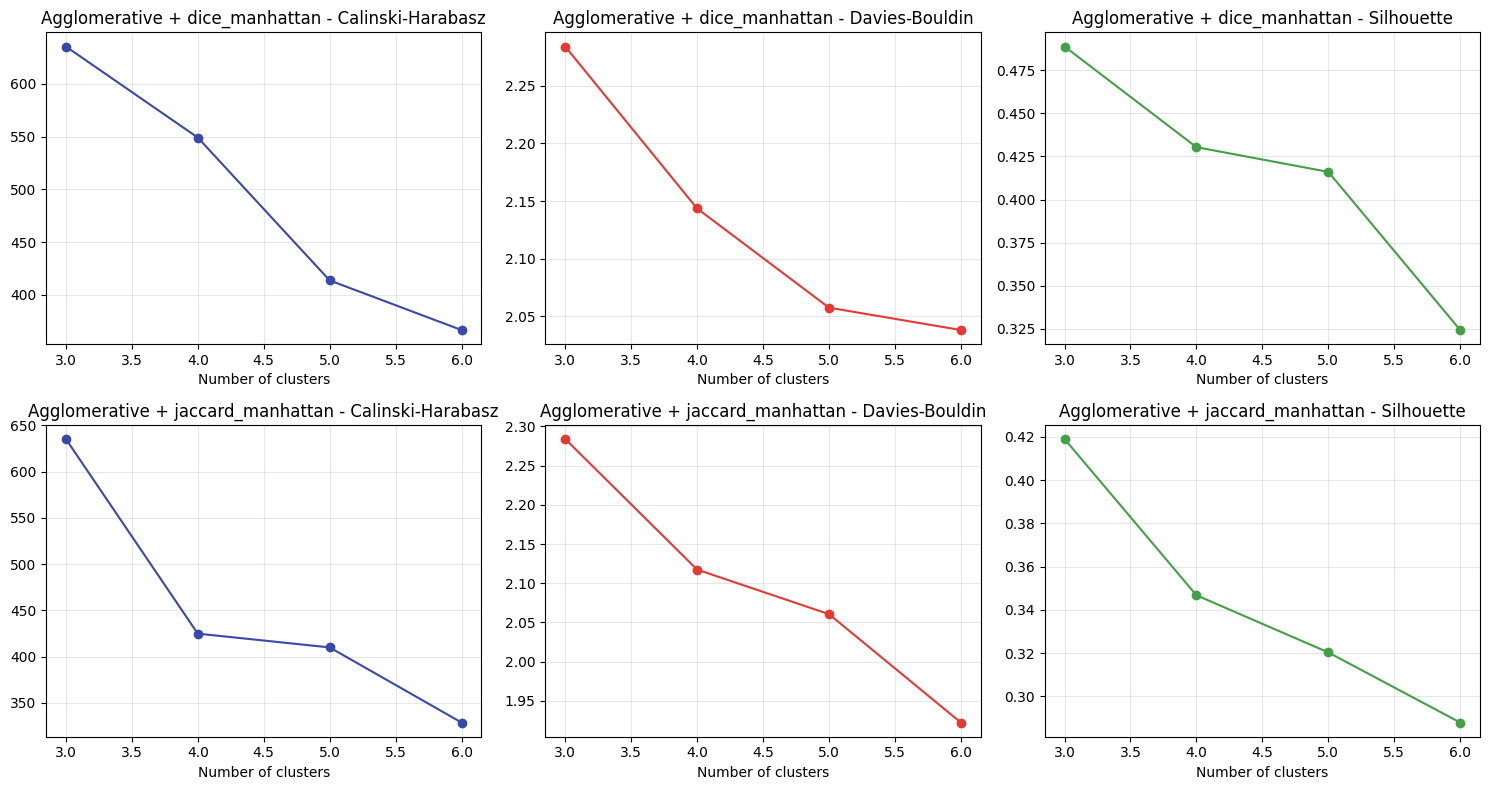


Distance: dice_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 6
Optimal k according to Silhouette: 3
Final decision (median vote): 3

Distance: jaccard_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 6
Optimal k according to Silhouette: 3
Final decision (median vote): 3


In [ ]:
from sklearn.cluster import AgglomerativeClustering


# CORE FUNCTIONS FOR AGGLOMERATIVE CLUSTERING
def run_agglomerative(distance_matrix, k, linkage="average"):
    """
    Initializes and trains a single hierarchical model.
    """
    model = AgglomerativeClustering(
        n_clusters=k,
        # FUNDAMENTAL: We tell the algorithm to use our hybrid matrix
        metric="precomputed",
        # AVERAGE LINKAGE: Merges two clusters if the average distance between ALL
        # points of the first and ALL points of the second is the minimum possible.
        linkage=linkage
    )

    # The algorithm merges the points and assigns the final labels
    labels = model.fit_predict(distance_matrix)
    return labels, model


def compute_agglomerative_solutions(distance_matrices, selected_distances, k_values, linkage="average"):
    """
    Executes the algorithm by iterating over all distance matrices and all K values.
    """
    results = {}

    for dist_name in selected_distances:
        # For each metric (e.g., Jaccard-Manhattan) we create a nested dictionary
        results[dist_name] = {}

        # We test the algorithm by forcing the tree cut at 3, 4, 5, and 6 clusters
        for k in k_values:
            labels, model = run_agglomerative(
                distance_matrix=distance_matrices[dist_name],
                k=k,
                linkage=linkage
            )

            # We save the labels and the model for the validation phase
            results[dist_name][k] = {
                "labels": labels,
                "model": model
            }

    return results


def evaluate_agglomerative_multiple_distances(processed_data, distance_matrices, agglomerative_results, selected_distances):
    """
    Evaluates the quality of the clusters formed using our pipeline (CH, DB, Silhouette).
    """
    evaluation_results = {}

    for dist_name in selected_distances:

        # We pass the results to the validation function we
        # built previously to compare the configurations
        evaluation_results[dist_name] = evaluate_clustering_single_distance(
            processed_data=processed_data,
            distance_matrix=distance_matrices[dist_name],
            clustering_results=agglomerative_results[dist_name]
        )

    return evaluation_results



# CODE EXECUTION

# Define the range of clusters we want to explore
k_values = [3,4,5,6]

# TRAINING: Run the massive calculation on our pre-computed data
agglomerative_results = compute_agglomerative_solutions(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances,
    k_values=k_values,
    linkage="average"
)

# MATHEMATICAL VALIDATION: Calculate Silhouette, Calinski-Harabasz, and Davies-Bouldin
agglomerative_eval_results = evaluate_agglomerative_multiple_distances(
    processed_data=processed_data,
    distance_matrices=distance_matrices,
    agglomerative_results=agglomerative_results,
    selected_distances=selected_distances
)

# VISUAL PLOT: Show the trend of the metrics as K increases
plot_clustering_validation(
    evaluation_results=agglomerative_eval_results,
    selected_distances=selected_distances,
    method_name="Agglomerative"
)

# FINAL CHOICE: Use the voting approach (Median) to extract the winning K
agglomerative_final_k = select_k_clustering(
    validation_results=agglomerative_eval_results,
    selected_distances=selected_distances,
    verbose=True
)

In [ ]:
# DEFINITIVE TRAINING FUNCTION
# Use the optimal K elected by the internal validation to
# perform the definitive "cut" of the dendrogram and extract the labels.


def compute_final_agglomerative_models(distance_matrices, final_k_results, selected_distances):
    # Initialize the dictionary that will contain the ready-to-use models
    final_models = {}

    # Iterate over our hybrid distance metrics
    for dist_name in selected_distances:

        # EXTRACTION OF THE WINNING K
        # Retrieve the number of clusters (K) chosen by the voting system (median)
        k = final_k_results[dist_name]["final_k"]

        # FINAL TRAINING
        # Launch the run_agglomerative function. We pass the corresponding
        # hybrid matrix and ask the algorithm to stop the merges
        # exactly when 'K' macro-groups remain.
        labels, model = run_agglomerative(
            distance_matrix=distance_matrices[dist_name],
            k=k
        )

        # SAVING THE RESULTS
        # Store the used K, the labels assigned to the clients, and the model
        # object in a structured dictionary.
        final_models[dist_name] = {
            "k": k,
            "labels": labels,
            "model": model
        }

    return final_models


# CODE EXECUTION


# Call the function passing our pre-calculated matrices and the optimal Ks
agglomerative_final_models = compute_final_agglomerative_models(
    distance_matrices=distance_matrices,
    final_k_results=agglomerative_final_k,
    selected_distances=selected_distances
)

Visual Inspection

In [ ]:
tsne_embeddings_3d = compute_tsne_embeddings_3d(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances
)

plot_final_clustering_3d_plotly(
    final_models=agglomerative_final_models,
    tsne_embeddings_3d=tsne_embeddings_3d,
    selected_distances=selected_distances,
    method_name="Agglomerative"
)

In [ ]:
print("===============================================")
print(" VISUALIZZAZIONE PER SCELTA DI BUSINESS (K=4) ")
print("===============================================")

import copy
# Creiamo una copia dei risultati per non sporcare l'originale
agglomerative_final_k_forzato = copy.deepcopy(agglomerative_final_k)

# Forziamo a 4 tutte le distanze
for dist_name in selected_distances:
    agglomerative_final_k_forzato[dist_name]["final_k"] = 4

agglomerative_final_models_4 = compute_final_agglomerative_models(
    distance_matrices=distance_matrices,
    final_k_results=agglomerative_final_k_forzato,
    selected_distances=selected_distances
)

plot_final_clustering_3d_plotly(
    final_models=agglomerative_final_models_4,
    tsne_embeddings_3d=tsne_embeddings_3d,
    selected_distances=selected_distances,
    method_name="Agglomerative (a K=4)"
)

 VISUALIZZAZIONE PER SCELTA DI BUSINESS (K=4) 


The results of Agglomerative Clustering offer a very clear mathematical picture: the majority of indicators indicate K=3.

Looking at the graphs:

Calinski-Harabasz and Silhouette Score both reach their peak performance at K=3, indicating the presence of well-separated and internally cohesive clusters.

The Davies-Bouldin suggests K=6, but this is a typical behavior of this metric, which physiologically tends to reward the isolation of micro-groups (outliers) leading to excessive fragmentation.

Our median-based election system correctly filtered the Davies-Bouldin outlier, confirming K=3 as the ultimate optimal configuration.

In light of these considerations, we can begin to assume that 3 may be the correct number of clusters for our analysis.

# C) K-Medoids
After exploring K-Prototypes and Agglomerative Clustering, we introduce a third methodological approach for our comparative analysis: K-Medoids. The goal is to test a pure partitional algorithm that, unlike K-Prototypes, is able to exploit the previously calculated hybrid distance matrix.


Unlike the better-known K-Means, which computes a synthetic 'centroid' (an abstract mathematical average), K-Medoids elects a Medoid, or real data point, as the center of the cluster. The algorithm evaluates the distance matrix and iteratively searches for the customer whose total distance to all other members of his group is the minimum possible, placing him at the center of the topology.

We then proceed with training the model, subjecting it to our usual internal validation pipeline (Silhouette, Calinski-Harabasz, Davies-Bouldin) to objectively evaluate its performance compared to previous approaches.

Importing libraries

In [ ]:
!pip install "numpy<2.0"
!pip install scikit-learn-extra

In [ ]:
import numpy as np
print(np.__version__)

from sklearn_extra.cluster import KMedoids
print("KMedoids imported correctly")

1.26.4
KMedoids imported correctly



Distance: dice_manhattan
k = 3, medoids = [3559  837 3220]
k = 4, medoids = [3559  837 2796  373]
k = 5, medoids = [4045  837 2796  688  700]
k = 6, medoids = [4045  126 2796  688  700]...

Distance: jaccard_manhattan
k = 3, medoids = [3559  837 3220]
k = 4, medoids = [3559  837 2796 1341]
k = 5, medoids = [3559 2397 2796 1341 3959]
k = 6, medoids = [1381 2397 3944  688 3959]...


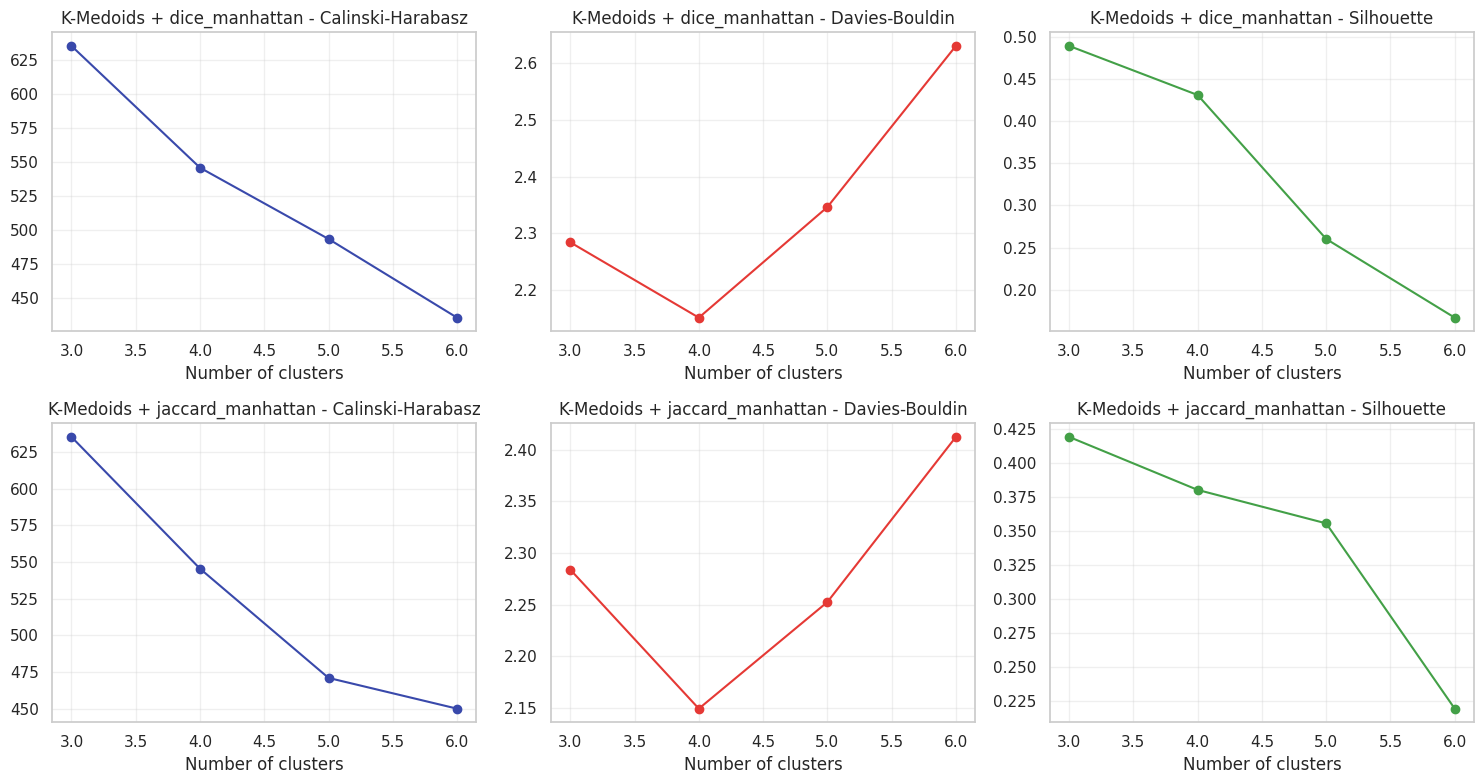


Distance: dice_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 4
Optimal k according to Silhouette: 3
Final decision (median vote): 3

Distance: jaccard_manhattan
Optimal k according to Calinski-Harabasz: 3
Optimal k according to Davies-Bouldin: 4
Optimal k according to Silhouette: 3
Final decision (median vote): 3


In [ ]:
# DEFINITION OF K-MEDOIDS FUNCTIONS

def run_kmedoids(distance_matrix, k, random_state=42):
    """
    Executes the K-Medoids algorithm on a single distance matrix.
    """
    model = KMedoids(
        n_clusters=k,
        metric="precomputed",  # We use our custom hybrid matrix
        init="k-medoids++",    # Optimized initialization to speed up convergence
        random_state=random_state,
        max_iter=300
    )
    # Calculation of labels and identification of real central points
    labels = model.fit_predict(distance_matrix)
    medoid_indices = model.medoid_indices_ # Indices of clients elected as 'Medoids'

    return labels, medoid_indices, model

def compute_clusterings_for_k(distance_matrix, k_values, random_state=42):
    """
    Iterates training over different values of K for a specific distance.
    """
    results = {}
    for k in k_values:
        labels, medoid_indices, model = run_kmedoids(
            distance_matrix=distance_matrix,
            k=k,
            random_state=random_state
        )
        # Saving results for the validation phase
        results[k] = {
            "labels": labels,
            "medoid_indices": medoid_indices,
            "model": model
        }
    return results

def compute_clusterings_for_distances(distance_matrices, selected_distances, k_values, random_state=42):
    """
    Applies K-Medoids to all selected metrics (e.g., Manhattan+Dice vs Manhattan+Jaccard).
    """
    all_results = {}
    for name in selected_distances:
        all_results[name] = compute_clusterings_for_k(
            distance_matrix=distance_matrices[name],
            k_values=k_values,
            random_state=random_state
        )
    return all_results

def evaluate_kmedoids_multiple_distances(processed_data, distance_matrices, clustering_results, selected_distances):
    """
    Calculates internal validation metrics (Silhouette, CH, DB) for the obtained results.
    """
    evaluation_results = {}

    for dist_name in selected_distances:
        evaluation_results[dist_name] = evaluate_clustering_single_distance(
            processed_data=processed_data,
            distance_matrix=distance_matrices[dist_name],
            clustering_results=clustering_results[dist_name]
        )

    return evaluation_results

# Define the range of clusters to test
k_values = [3, 4, 5, 6]

# MASSIVE TRAINING
# We calculate all possible combinations between hybrid distances and number of clusters
kmedoids_results = compute_clusterings_for_distances(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances,
    k_values=k_values,
    random_state=42
)

# PRELIMINARY INSPECTION
# We print the first indices of the medoids to verify that the algorithm has
# correctly identified real clients as group centers.
for dist_name in kmedoids_results:
    print(f"\nDistance: {dist_name}")
    for k in kmedoids_results[dist_name]:
        medoids = kmedoids_results[dist_name][k]["medoid_indices"]
        print(f"k = {k}, medoids = {medoids[:5]}{'...' if len(medoids) > 5 else ''}")

# ANALYTICAL VALIDATION
# We calculate Silhouette Score, Calinski-Harabasz, and Davies-Bouldin
kmedoids_eval_results = evaluate_kmedoids_multiple_distances(
    processed_data=processed_data,
    distance_matrices=distance_matrices,
    clustering_results=kmedoids_results,
    selected_distances=selected_distances
)

# PERFORMANCE VISUALIZATION
# We generate plots to visually compare the effectiveness of the clusters as K varies
plot_clustering_validation(
    evaluation_results=kmedoids_eval_results,
    selected_distances=selected_distances,
    method_name="K-Medoids"
)

# OPTIMAL K ELECTION
# We apply the median logic to establish which configuration
# of K represents the best compromise between compactness and separation.
kmedoids_final_k = select_k_clustering(
    validation_results=kmedoids_eval_results,
    selected_distances=selected_distances,
    verbose=True
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# DEFINITIVE TRAINING FUNCTION (K-MEDOIDS)
# Purpose: Extract the optimal parameters from the validation and generate the final
# model that will be used to interpret the customer segments.


def compute_final_kmedoids_models(distance_matrices, final_k_results, selected_distances):
    # Initialize the container for the definitive models
    final_models = {}

    for dist_name in selected_distances:
        # 1. RETRIEVAL OF OPTIMAL K
        # We take the K value that obtained the best consensus from the metrics
        k = final_k_results[dist_name]["final_k"]

        # 2. FINAL TRAINING
        # We re-run K-Medoids with the chosen K.
        # We obtain the labels for each client and the indices of the real medoids.
        labels, medoids, model = run_kmedoids(
            distance_matrix=distance_matrices[dist_name],
            k=k
        )

        # 3. FULL SAVE
        # We store everything necessary: K, membership labels,
        # and the medoids (the physical "representatives" of the clusters).
        final_models[dist_name] = {
            "k": k,
            "labels": labels,
            "medoids": medoids,
            "model": model
        }

    return final_models


# CODE EXECUTION


# We generate the definitive models for K-Medoids.
# These models will be the basis for the final comparison between the different techniques.
kmedoids_final_models = compute_final_kmedoids_models(
    distance_matrices=distance_matrices,
    final_k_results=kmedoids_final_k,
    selected_distances=selected_distances
)

Visual Inspection

In [ ]:
tsne_embeddings_3d = compute_tsne_embeddings_3d(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances
)

plot_final_clustering_3d_plotly(
    final_models=kmedoids_final_models,
    tsne_embeddings_3d=tsne_embeddings_3d,
    selected_distances=selected_distances,
    method_name="K-Medoids"
)

The K-Medoids results align perfectly with what emerged from Agglomerative Clustering, robustly confirming K=3 as the optimal configuration for both distance metrics.

Calinski-Harabasz and Silhouette Score converge again on K=3, confirming the presence of cohesive and well-spaced groups.

The Davies-Bouldin suggests K=4. Compared to the K=6 seen previously, this metric now indicates a much more stable structure and less prone to extreme fragmentation.

In the 3-D plot we can observe 3 macro clusters that are quite distinct from each other.

# D) DBSCAN


In [ ]:
# DEFINITION OF DBSCAN FUNCTIONS

def select_best_clustering_params(df_report):
    """
    Algoritmo di Selezione Universale (Strict Plateau Edition).

    Identifica il parametro ottimale basandosi sulla sequenza CONSECUTIVA più lunga
    di risultati identici (Plateau), garantendo la massima invarianza parametrica.
    """
    # 1. Preliminary filter: excluding non-significant solutions (K=1)
    df_candidates = df_report[df_report['Cluster Trovati (K)'] > 1].copy()

    if df_candidates.empty:
        return None, None

    # 2. Quality Score Calculation (Persistence * Confidence)
    df_candidates['Score_Quality'] = (
        df_candidates['Stabilità (Persistence)'] * df_candidates['Confidenza (Core Density)']
    )

    # 3. CONSECUTIVE PLATEAU IDENTIFICATION (Strict Logic)
    # Create an identifier for each block of identical and consecutive K values
    df_candidates['block'] = (df_candidates['Cluster Trovati (K)'] != df_candidates['Cluster Trovati (K)'].shift()).cumsum()

    # Calculate the length of each block
    block_analysis = df_candidates.groupby('block').agg({
        'Cluster Trovati (K)': 'first',
        'Parametro': 'count'
    }).rename(columns={'Parametro': 'block_length'})

    # Find the ID of the longest block
    best_block_id = block_analysis.sort_values(by='block_length', ascending=False).index[0]
    most_stable_k = block_analysis.loc[best_block_id, 'Cluster Trovati (K)']

    # 4. selection within the plateau
    final_candidates = df_candidates[df_candidates['block'] == best_block_id]

    # Choose the configuration with the highest Quality_Score within the plateau
    best_row = final_candidates.sort_values(by='Score_Quality', ascending=False).iloc[0]

    return best_row['Parametro'], int(most_stable_k)

def generate_clustering_report(results_dict, distance_matrices, method="DBSCAN"):
    """
    Genera un report standardizzato per la validazione della densità.
    Funziona sia per DBSCAN.
    """
    reports = {}

    for dist_name, solutions in results_dict.items():
        data = []
        sorted_params = sorted(solutions.keys())

        for p in sorted_params:
            res = solutions[p]
            labels = res["labels"]
            k_eff = res.get("k_effettivo", len(np.unique(labels[labels != -1])))

            # --- PERSISTENCE CALCULATION (Geometric Cohesion) ---
            # Calculated on real clusters (excluding noise -1 if present)
            unique_clusters = np.unique(labels[labels != -1])
            if len(unique_clusters) > 0:
                compactness = np.mean([
                    np.mean(distance_matrices[dist_name][labels==c][:, labels==c])
                    for c in unique_clusters
                ])
                persistence = 1 / (1 + compactness)
            else:
                persistence = 0

            # --- CONFIDENCE CALCULATION (Core Reliability) ---
            # Based on the model's original Core Points
            confidence = 1.0 - (np.sum(res["model"].labels_ == -1) / len(labels))


            data.append({
                "Parametro": p,
                "Cluster Trovati (K)": k_eff,
                "Stabilità (Persistence)": round(persistence, 4),
                "Confidenza (Core Density)": round(confidence, 4)
            })

        reports[dist_name] = pd.DataFrame(data)

    return reports

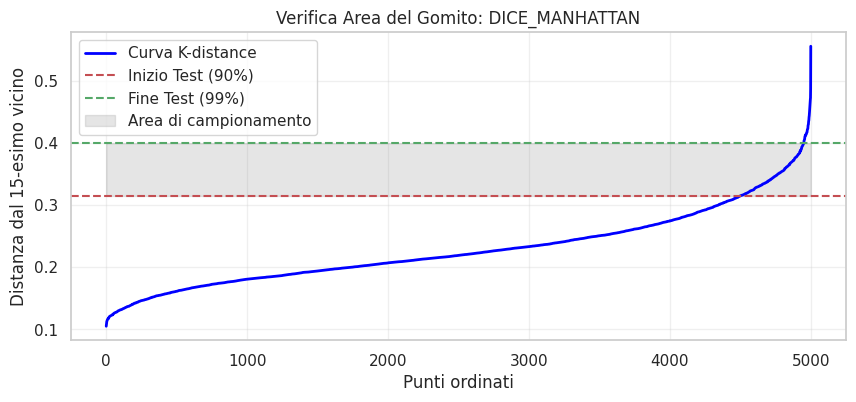

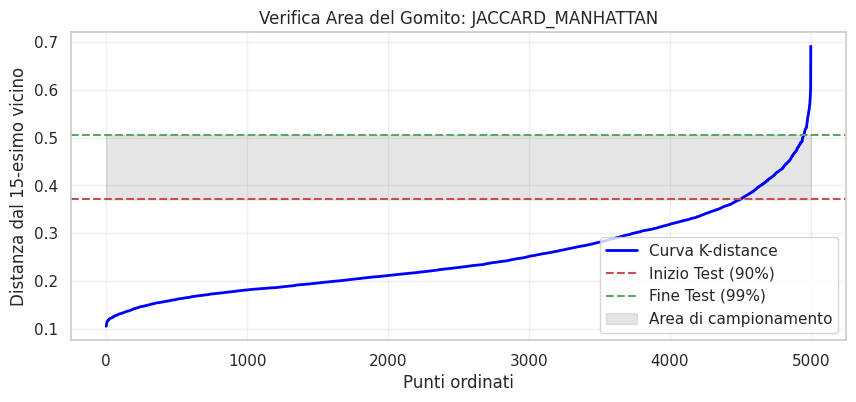


REPORT VALIDAZIONE DENSITÀ DBSCAN: DICE_MANHATTAN


,Epsilon (ε),Cluster Trovati (K),Persistence (Stabilità),Core Density (Confidence)
0,0.3146,3,0.6356,0.9820
1,0.3240,3,0.6356,0.9892
2,0.3334,3,0.6356,0.9924
3,0.3428,3,0.6356,0.9964
4,0.3523,3,0.6356,0.9976
5,0.3617,3,0.6356,0.9980
6,0.3711,3,0.6356,0.9990
7,0.3805,3,0.6356,0.9996
8,0.3899,3,0.6356,0.9998
9,0.3993,3,0.6356,0.9998



REPORT VALIDAZIONE DENSITÀ DBSCAN: JACCARD_MANHATTAN


,Epsilon (ε),Cluster Trovati (K),Persistence (Stabilità),Core Density (Confidence)
0,0.3709,10,0.6496,0.9728
1,0.3859,9,0.6494,0.9766
2,0.4009,6,0.6367,0.9806
3,0.4159,6,0.6368,0.9880
4,0.4310,4,0.6127,0.9924
5,0.4460,3,0.5865,0.9954
6,0.4610,3,0.5865,0.9974
7,0.4760,3,0.5865,0.9988
8,0.4910,3,0.5865,0.9996
9,0.5060,3,0.5865,0.9998



ANALISI PARAMETRI OTTIMALI DBSCAN
-----------------------------------------------------------------
DISTANZA: DICE_MANHATTAN
   -> Miglior Epsilon (ε) individuato: 0.3899
   -> Numero di cluster (K) risultante: 3
-----------------------------------------------------------------
DISTANZA: JACCARD_MANHATTAN
   -> Miglior Epsilon (ε) individuato: 0.506
   -> Numero di cluster (K) risultante: 3
-----------------------------------------------------------------


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def run_dbscan(distance_matrix, eps, min_samples=15):
    """
    Performs DBSCAN and handles noise through KNN.
    """
    model = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = np.array(model.fit_predict(distance_matrix))

    # Outlier Reassignment (-1 points) via KNN
    if -1 in labels:
        valid_idx = np.where(labels != -1)[0]
        noise_idx = np.where(labels == -1)[0]
        if len(valid_idx) > 0:
            knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
            knn.fit(distance_matrix[valid_idx][:, valid_idx], labels[valid_idx])
            labels[noise_idx] = knn.predict(distance_matrix[noise_idx][:, valid_idx])

    return labels, model

def compute_dbscan_solutions(distance_matrices, selected_distances, k_neighbors=15, p_low=90, p_high=95, n_steps=10):
    """
    Calculates DBSCAN solutions by varying Epsilon within the identified range.
    """
    results = {}
    for dist_name in selected_distances:
        results[dist_name] = {}
        matrix = distance_matrices[dist_name]

        # Epsilon range identification through k-distance percentiles
        k_dist = np.sort(np.sort(matrix, axis=1)[:, k_neighbors-1])
        eps_values = np.linspace(np.percentile(k_dist, p_low), np.percentile(k_dist, p_high), n_steps)

        for eps in eps_values:
            labels, model = run_dbscan(matrix, eps, min_samples=k_neighbors)
            results[dist_name][eps] = {
                "labels": labels,
                "model": model,
                "k_effettivo": len(np.unique(labels))
            }
    return results

def select_best_dbscan_params(df_report):
    """
    Chooses the best Epsilon based on plateau stability and density quality.
    """
    df_candidati = df_report[df_report['Cluster Trovati (K)'] > 1].copy()
    if df_candidati.empty: return None, None

    # Quality Score: Product of Persistence and Confidence
    df_candidati.loc[:, 'Score_Qualita'] = (
        df_candidati['Persistence (Stabilità)'] * df_candidati['Core Density (Confidence)']
    )

    # Identification of the most frequent number of clusters (K) (Plateau)
    most_stable_k = df_candidati['Cluster Trovati (K)'].value_counts().idxmax()

    # Selection of the row with the best score within the plateau
    best_row = (
        df_candidati[df_candidati['Cluster Trovati (K)'] == most_stable_k]
        .sort_values(by='Score_Qualita', ascending=False)
        .iloc[0]
    )

    return best_row['Epsilon (ε)'], int(best_row['Cluster Trovati (K)'])

# ELBOW ANALYSIS: Identifies the optimal Epsilon range by locating the 'knee' in the k-distance graph.
# This transition point separates dense local clusters from global noise/outliers.
min_size = 15
p_low=90
p_high=99

def plot_dbscan_elbow_verification(distance_matrices, selected_distances, k, p_low, p_high):
    for dist_name in selected_distances:
        matrix = distance_matrices[dist_name]
        k_dist = np.sort(np.sort(matrix, axis=1)[:, k-1])
        low_val = np.percentile(k_dist, p_low)
        high_val = np.percentile(k_dist, p_high)

        plt.figure(figsize=(10, 4))
        plt.plot(k_dist, label='Curva K-distance', color='blue', linewidth=2)
        plt.axhline(y=low_val, color='r', linestyle='--', label=f'Inizio Test ({p_low}%)')
        plt.axhline(y=high_val, color='g', linestyle='--', label=f'Fine Test ({p_high}%)')
        plt.fill_between(range(len(k_dist)), low_val, high_val, color='gray', alpha=0.2, label='Area di campionamento')

        plt.title(f"Verifica Area del Gomito: {dist_name.upper()}")
        plt.xlabel("Punti ordinati")
        plt.ylabel(f"Distanza dal {k}-esimo vicino")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

plot_dbscan_elbow_verification(distance_matrices, selected_distances, min_size, p_low, p_high)


# DENSITY REPORT AND TABLE GENERATION

dbscan_results = compute_dbscan_solutions(distance_matrices, selected_distances, min_size,p_low, p_high, n_steps=10)

dbscan_density_reports = {}

for dist_name in selected_distances:
    density_data = []
    sorted_eps = sorted(dbscan_results[dist_name].keys())

    for eps in sorted_eps:
        res = dbscan_results[dist_name][eps]
        labels = res["labels"]
        k_found = res["k_effettivo"]

        # Density Indicators
        # Persistence: compactness proxy (inverse of the mean intra-cluster distance)
        compactness = np.mean([
            np.mean(distance_matrices[dist_name][labels==c][:, labels==c])
            for c in np.unique(labels)
        ])
        persistence = 1 / (1 + compactness)

        # Core Density: Confidence based on the number of core points pre-KNN
        core_density = 1.0 - (np.sum(res["model"].labels_ == -1) / len(labels))

        density_data.append({
            "Epsilon (ε)": round(eps, 4),
            "Cluster Trovati (K)": k_found,
            "Persistence (Stabilità)": round(persistence, 4),
            "Core Density (Confidence)": round(core_density, 4)
        })

    df_report = pd.DataFrame(density_data)
    dbscan_density_reports[dist_name] = df_report

    print(f"\n" + "="*65)
    print(f"REPORT VALIDAZIONE DENSITÀ DBSCAN: {dist_name.upper()}")
    print("="*65)
    display(df_report)

# FINAL PARAMETER SELECTION

best_params_dbscan = {}

print("\nANALISI PARAMETRI OTTIMALI DBSCAN")
print("-" * 65)

for dist_name in selected_distances:
    if dist_name in dbscan_density_reports:
        best_eps, final_k = select_best_dbscan_params(dbscan_density_reports[dist_name])
        if best_eps:
            best_params_dbscan[dist_name] = {"best_eps": best_eps, "final_k": final_k}
            print(f"DISTANZA: {dist_name.upper()}")
            print(f"   -> Miglior Epsilon (ε) individuato: {best_eps}")
            print(f"   -> Numero di cluster (K) risultante: {final_k}")
            print("-" * 65)

In [ ]:
# DBSCAN EXECUTION WITH OPTIMAL EPSILON

def compute_final_dbscan_models_adaptive(distance_matrices, selected_distances, best_params, min_size):
    """
    Finalizzazione dei modelli DBSCAN basata sui parametri ottimali identificati.
    Include una fase di post-processing per la gestione dei punti isolati (noise)
    tramite classificazione Nearest Neighbor (KNN).
    """
    final_models = {}

    for dist_name in selected_distances:
        # Retrieval of the optimal configuration from the reports dictionary
        config = best_params.get(dist_name)
        if config is None:
            continue

        eps = config["best_eps"]

        print(f"Esecuzione DBSCAN finale ({dist_name.upper()}): Epsilon={eps}, min_size={min_size}...")

        # A. DBSCAN Execution
        model = DBSCAN(eps=eps, min_samples=min_size, metric='precomputed')
        labels = np.array(model.fit_predict(distance_matrices[dist_name]))

        # B. Outlier Optimization: Hierarchical Reassignment via KNN
        if -1 in labels:
            valid_idx = np.where(labels != -1)[0]
            noise_idx = np.where(labels == -1)[0]

            if len(valid_idx) > 0:
                knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")

                # Training: Distance matrix between valid samples
                train_dist = distance_matrices[dist_name][valid_idx][:, valid_idx]
                knn.fit(train_dist, labels[valid_idx])

                # Predict: Distance matrix between outlier samples and valid samples
                test_dist = distance_matrices[dist_name][noise_idx][:, valid_idx]

                # Riassegnazione delle etichette definitive
                labels[noise_idx] = knn.predict(test_dist)

        # C. Results Archiving
        final_models[dist_name] = {
            "k": len(np.unique(labels)),
            "labels": labels,
            "medoids": None,
            "model": model
        }

    return final_models

# GRAPHICAL OUTPUT AND SPATIAL ANALYSIS

dbscan_final_models = compute_final_dbscan_models_adaptive(
    distance_matrices=distance_matrices,
    selected_distances=selected_distances,
    best_params=best_params_dbscan,
    min_size=min_size
)

plot_final_clustering_3d_plotly(
    final_models=dbscan_final_models,
    tsne_embeddings_3d=tsne_embeddings_3d,
    selected_distances=list(dbscan_final_models.keys()),
    method_name="DBSCAN (Density-Optimized)"
)

Esecuzione DBSCAN finale (DICE_MANHATTAN): Epsilon=0.3899, min_size=15...
Esecuzione DBSCAN finale (JACCARD_MANHATTAN): Epsilon=0.506, min_size=15...


## Summary Table

We created a summary table to display the number of optimal clusters for each method based on the 3 chosen metrics

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np

results = []

# A) K-MEDOIDS: dependent on distance and k
for dist_name in selected_distances:
    if dist_name not in kmedoids_results:
        continue

    for k, sol in kmedoids_results[dist_name].items():
        labels = np.array(sol["labels"])
        D = distance_matrices[dist_name]

        n_clusters = len(np.unique(labels))
        cluster_sizes = pd.Series(labels).value_counts().sort_index()

        try:
            sil = silhouette_score(D, labels, metric="precomputed")
        except:
            sil = np.nan

        try:
            ch = calinski_harabasz_score(X, labels)
        except:
            ch = np.nan

        try:
            db = davies_bouldin_score(X, labels)
        except:
            db = np.nan

        results.append({
            "Method": "KMedoids",
            "Distance": dist_name,
            "k": k,
            "Min_cluster_size": int(cluster_sizes.min()),
            "Max_cluster_size": int(cluster_sizes.max()),
            "Silhouette": sil,
            "Calinski_Harabasz": ch,
            "Davies_Bouldin": db
        })



# B) AGGLOMERATIVE: dependent on distance and k
for dist_name in selected_distances:
    if dist_name not in agglomerative_results:
        continue

    for k, sol in agglomerative_results[dist_name].items():
        labels = np.array(sol["labels"])
        D = distance_matrices[dist_name]

        n_clusters = len(np.unique(labels))
        cluster_sizes = pd.Series(labels).value_counts().sort_index()

        try:
            sil = silhouette_score(D, labels, metric="precomputed")
        except:
            sil = np.nan

        try:
            ch = calinski_harabasz_score(X, labels)
        except:
            ch = np.nan

        try:
            db = davies_bouldin_score(X, labels)
        except:
            db = np.nan

        results.append({
            "Method": "Agglomerative",
            "Distance": dist_name,
            "k": k,
            "Min_cluster_size": int(cluster_sizes.min()),
            "Max_cluster_size": int(cluster_sizes.max()),
            "Silhouette": sil,
            "Calinski_Harabasz": ch,
            "Davies_Bouldin": db
        })


# C) K-PROTOTYPES: dependent on X and k (not precomputed distance matrices)
for k, sol in kprototypes_results.items():
    labels = np.array(sol["labels"])

    n_clusters = len(np.unique(labels))
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    try:
        sil = silhouette_score(X, labels, metric="euclidean")
    except:
        sil = np.nan

    try:
        ch = calinski_harabasz_score(X, labels)
    except:
        ch = np.nan

    try:
        db = davies_bouldin_score(X, labels)
    except:
        db = np.nan

    results.append({
        "Method": "KPrototypes",
        "Distance": "internal",
        "k": k,
        "Min_cluster_size": int(cluster_sizes.min()),
        "Max_cluster_size": int(cluster_sizes.max()),
        "Silhouette": sil,
        "Calinski_Harabasz": ch,
        "Davies_Bouldin": db
    })

# D) DBSCAN: depend on distance and epsilon
for dist_name in selected_distances:
    if dist_name not in dbscan_results:
        continue

    temp_results = []

    for eps, sol in dbscan_results[dist_name].items():
        labels = np.array(sol["labels"])
        D = distance_matrices[dist_name]
        n_clusters = len(np.unique(labels))

        if n_clusters > 1:
            try:
                sil = silhouette_score(D, labels, metric="precomputed")
                ch = calinski_harabasz_score(X, labels)
                db = davies_bouldin_score(X, labels)
            except:
                sil, ch, db = np.nan, np.nan, np.nan
        else:
            sil, ch, db = np.nan, np.nan, np.nan

        temp_results.append({
            "Method": "DBSCAN",
            "Distance": dist_name,
            "k": n_clusters,
            "Eps_param": round(eps, 4),
            "Silhouette": sil,
            "Calinski_Harabasz": ch,
            "Davies_Bouldin": db,
            "Min_cluster_size": int(pd.Series(labels).value_counts().min()) if n_clusters > 0 else 0,
            "Max_cluster_size": int(pd.Series(labels).value_counts().max()) if n_clusters > 0 else 0
        })

    if temp_results:
        best_dbscan_for_dist = (
            pd.DataFrame(temp_results)
            .sort_values(by="Silhouette", ascending=False)
            .head(1)
        )

        results.extend(best_dbscan_for_dist.to_dict('records'))



# FINAL TABLE
comparison_table = pd.DataFrame(results)

comparison_table = comparison_table.sort_values(
    by=["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

comparison_table_rounded = comparison_table.copy()
for col in ["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"]:
    comparison_table_rounded[col] = comparison_table_rounded[col].round(3)

display(comparison_table_rounded)

,Method,Distance,k,N_clusters,Min_cluster_size,Max_cluster_size,Silhouette,Calinski_Harabasz,Davies_Bouldin,Eps_param
0,KMedoids,dice_manhattan,3,3.0,1314,2190,0.489,635.372,2.284,NaN
1,DBSCAN,dice_manhattan,3,NaN,1314,2190,0.489,635.372,2.284,0.3146
2,Agglomerative,dice_manhattan,3,3.0,1314,2190,0.489,635.372,2.284,NaN
3,KMedoids,dice_manhattan,4,4.0,585,2181,0.431,545.755,2.151,NaN
4,Agglomerative,dice_manhattan,4,4.0,571,2190,0.430,549.107,2.144,NaN
5,KMedoids,jaccard_manhattan,3,3.0,1314,2190,0.419,635.372,2.284,NaN
6,DBSCAN,jaccard_manhattan,3,NaN,1314,2190,0.419,635.372,2.284,0.4460
7,Agglomerative,jaccard_manhattan,3,3.0,1314,2190,0.419,635.372,2.284,NaN
8,Agglomerative,dice_manhattan,5,5.0,5,2190,0.416,413.746,2.058,NaN
9,KMedoids,jaccard_manhattan,4,4.0,576,2174,0.380,545.472,2.149,NaN


# 3 - Comparison and Discussion

This block of code performs detailed analysis on the models we decided to analyze:
- K-Medoids dice-manhattan K = 3
- K-Medoids dice-manhattan K = 4
- Agglomerative dice-manhattan K = 4

The choice was guided by the results obtained from the various validation functions. We decided to analyze the cases that gave us the best results

The goal is to mathematically describe each group to understand who the customers are within them.

For each cluster we calculate Mean, Median and Standard Deviation. This tells us what the typical value is and how similar the customers in that group are to each other or whether there are strong variations.

Categorical Variables: We extract Fashion (the most frequent value) to identify dominant demographic characteristics, such as type of work or city of origin.

Size: We calculate how many people belong to each cluster to ensure the groups are balanced and relevant to the business.

The result is a series of comparative tables that allow you to read and compare customer profiles between different models.

In [ ]:
# =========================================
# SELECTED MODELS FOR THE FINAL ANALYSIS
# =========================================
# Selecting the new models to test the updated weights:
# K-Medoids k=3 and k=4, plus Agglomerative at k=4 (all with Dice-Manhattan distance)
selected_models = {
    "KMedoids_Dice_k3": kmedoids_results["dice_manhattan"][3]["labels"],
    "KMedoids_Dice_k4": kmedoids_results["dice_manhattan"][4]["labels"],
    "Agglo_Dice_k4": agglomerative_results["dice_manhattan"][4]["labels"]
}

comparison_results = {}
for model_name, labels in selected_models.items():
    data_with_clusters = data.copy()
    data_with_clusters["Cluster"] = labels
    comparison_results[model_name] = data_with_clusters

# =========================================
# STATISTICAL EXTRACTION FUNCTIONS
# =========================================

def get_cluster_stats_num(data, numerical_cols):
    stats = []
    for cluster in sorted(data["Cluster"].unique()):
        cluster_data = data[data["Cluster"] == cluster]

        # Calculating mean, median, and std, transposing (T) to have variables on the rows
        c_stats = cluster_data[numerical_cols].agg(["mean", "median", "std"]).T.round(2)

        # Adding the count of how many people are in the cluster
        c_stats["count"] = len(cluster_data)

        # Renaming the columns to identify which cluster they belong to (e.g., C0_mean)
        c_stats.columns = [f"C{cluster}_{col}" for col in c_stats.columns]
        stats.append(c_stats)

    return pd.concat(stats, axis=1)

def get_cluster_stats_cat(data, categorical_cols):
    stats = []
    for cluster in sorted(data["Cluster"].unique()):
        cluster_data = data[data["Cluster"] == cluster]

        # For categorical variables, we extract the Mode (the most frequent value)
        c_mode = cluster_data[categorical_cols].mode().iloc[0].to_frame(name=f"C{cluster}_Mode")
        stats.append(c_mode)

    return pd.concat(stats, axis=1)

# =========================================
# PRINTING THE RESULTS
# =========================================

# Safely merging the lists (if other_columns is empty, there are no issues)
tutte_le_numeriche = numerical_columns + other_columns

for model_name in comparison_results:
    print("\n" + "="*70)
    print(f"🏆 MODEL: {model_name.upper()}")
    print("="*70)

    # 1. Numerical Statistics (Behavior and Finances)
    print("\n--- FINANCIAL AND BEHAVIORAL PROFILE (Means, Medians, Std) ---")
    numerical_stats = get_cluster_stats_num(comparison_results[model_name], tutte_le_numeriche)
    display(numerical_stats)

    # 2. Categorical Statistics (Demographics - Most frequent value)
    print("\n--- DEMOGRAPHIC PROFILE (Dominant Category / Mode) ---")
    categorical_stats = get_cluster_stats_cat(comparison_results[model_name], categorical_columns)
    display(categorical_stats)


🏆 MODEL: KMEDOIDS_DICE_K3

--- FINANCIAL AND BEHAVIORAL PROFILE (Means, Medians, Std) ---


,C0_mean,C0_median,C0_std,C0_count,C1_mean,C1_median,C1_std,C1_count,C2_mean,C2_median,C2_std,C2_count
Age,57.96,57.00,21.27,2190,61.50,66.00,23.56,1314,63.17,64.00,20.62,1496
FamilySize,2.57,2.00,1.46,2190,2.58,2.00,1.44,1314,2.30,2.00,1.28,1496
Income,0.60,0.61,0.20,2190,0.54,0.54,0.21,1314,0.57,0.57,0.23,1496
Wealth,0.61,0.62,0.21,2190,0.54,0.54,0.20,1314,0.58,0.58,0.23,1496
Debt,0.48,0.50,0.20,2190,0.39,0.39,0.22,1314,0.39,0.40,0.24,1496
FinEdu,0.54,0.54,0.18,2190,0.47,0.46,0.17,1314,0.51,0.49,0.20,1496
ESG,0.59,0.60,0.17,2190,0.57,0.58,0.17,1314,0.60,0.62,0.16,1496
Digital,0.56,0.56,0.20,2190,0.50,0.48,0.21,1314,0.51,0.50,0.23,1496
BankFriend,0.61,0.62,0.16,2190,0.60,0.60,0.15,1314,0.64,0.66,0.17,1496
LifeStyle,0.49,0.48,0.22,2190,0.43,0.40,0.21,1314,0.45,0.42,0.23,1496



--- DEMOGRAPHIC PROFILE (Dominant Category / Mode) ---


,C0_Mode,C1_Mode,C2_Mode
Gender,1,1,1
Job,2,2,2
Area,1,1,1
CitySize,2,2,2
Investments,3,1,2



🏆 MODEL: KMEDOIDS_DICE_K4

--- FINANCIAL AND BEHAVIORAL PROFILE (Means, Medians, Std) ---


...

,C0_Mode,C1_Mode,C2_Mode,C3_Mode
Gender,1,1,0,1
Job,2,2,2,5
Area,1,1,1,1
CitySize,2,2,3,2
Investments,3,1,2,2



🏆 MODEL: AGGLO_DICE_K4

--- FINANCIAL AND BEHAVIORAL PROFILE (Means, Medians, Std) ---


,C0_mean,C0_median,C0_std,C0_count,C1_mean,C1_median,C1_std,C1_count,C2_mean,C2_median,C2_std,C2_count,C3_mean,C3_median,C3_std,C3_count
Age,74.99,78.00,17.03,571,57.96,57.00,21.27,2190,61.50,66.00,23.56,1314,55.87,54.00,19.22,925
FamilySize,2.12,2.00,1.16,571,2.57,2.00,1.46,2190,2.58,2.00,1.44,1314,2.40,2.00,1.34,925
Income,0.42,0.41,0.20,571,0.60,0.61,0.20,2190,0.54,0.54,0.21,1314,0.66,0.70,0.20,925
Wealth,0.43,0.41,0.20,571,0.61,0.62,0.21,2190,0.54,0.54,0.20,1314,0.67,0.70,0.20,925
Debt,0.17,0.12,0.16,571,0.48,0.50,0.20,2190,0.39,0.39,0.22,1314,0.52,0.52,0.17,925
FinEdu,0.36,0.35,0.13,571,0.54,0.54,0.18,2190,0.47,0.46,0.17,1314,0.60,0.62,0.18,925
ESG,0.61,0.63,0.15,571,0.59,0.60,0.17,2190,0.57,0.58,0.17,1314,0.60,0.61,0.16,925
Digital,0.34,0.32,0.17,571,0.56,0.56,0.20,2190,0.50,0.48,0.21,1314,0.62,0.64,0.20,925
BankFriend,0.63,0.65,0.15,571,0.61,0.62,0.16,2190,0.60,0.60,0.15,1314,0.65,0.67,0.17,925
LifeStyle,0.29,0.26,0.16,571,0.49,0.48,0.22,2190,0.43,0.40,0.21,1314,0.55,0.56,0.21,925



--- DEMOGRAPHIC PROFILE (Dominant Category / Mode) ---


,C0_Mode,C1_Mode,C2_Mode,C3_Mode
Gender,1,1,1,0
Job,5,2,2,2
Area,1,1,1,1
CitySize,2,2,2,3
Investments,2,3,1,2


This code block is designed to generate Radar Charts (also known as spiderweb charts or spider charts), which are the ideal tool for visually visualizing and comparing the multidimensional profiles identified by our clustering algorithms.

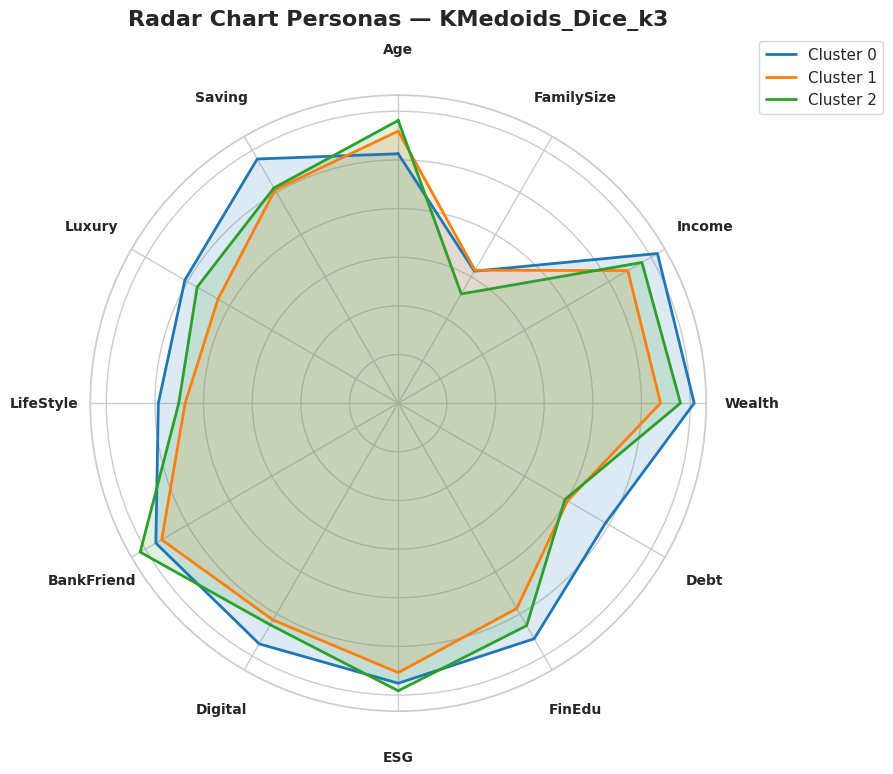

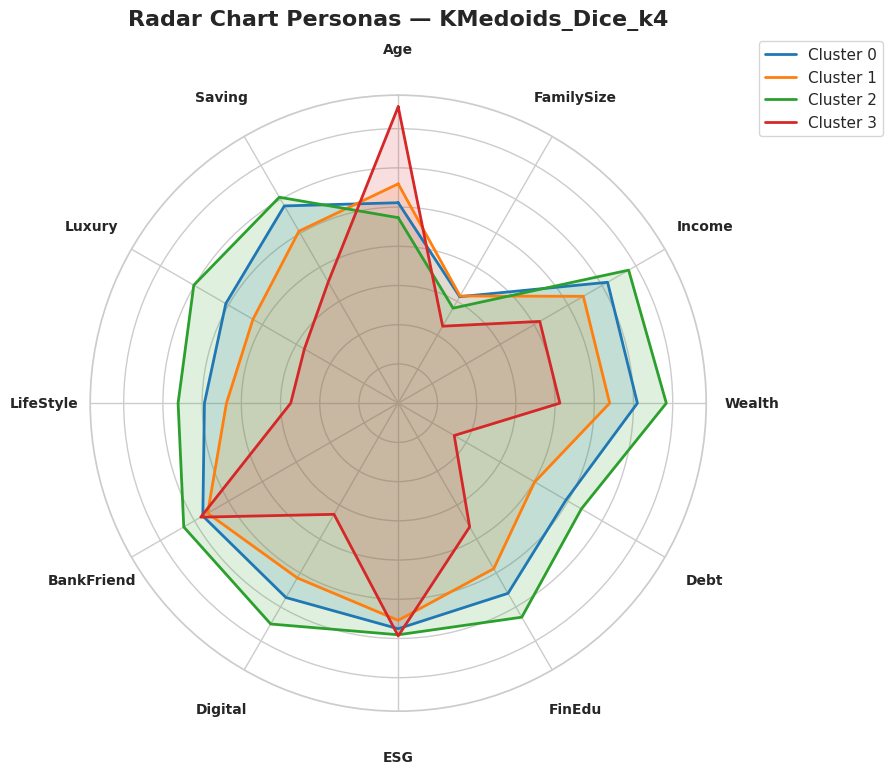

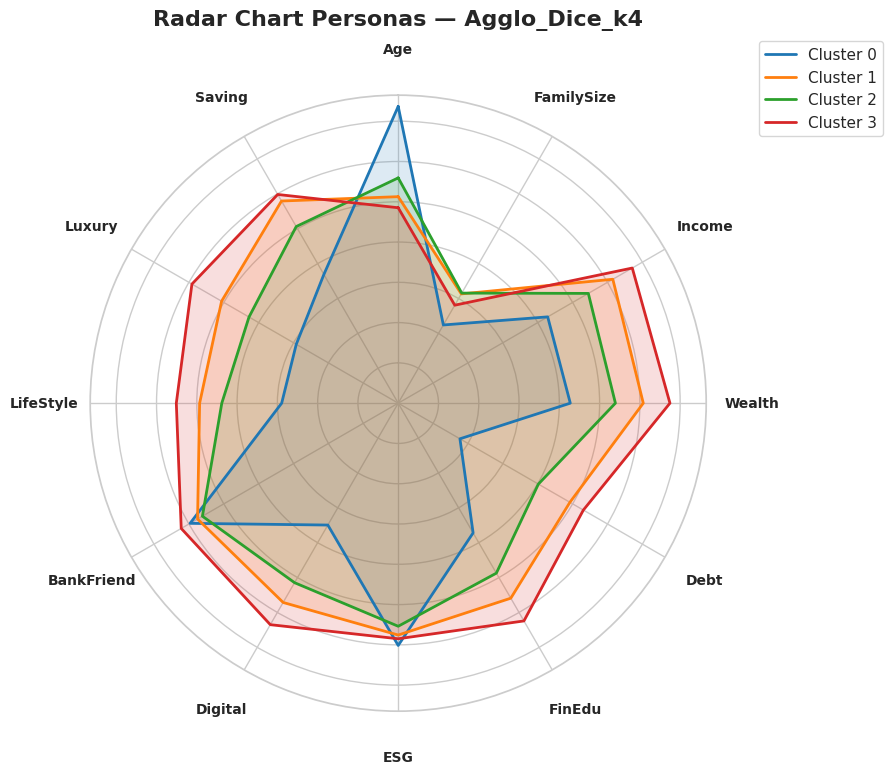

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def plot_cluster_radar(data, numerical_cols, title):
    plot_data = data.copy()

    # Rescale everything between 0 and 1 to have homogeneous axes
    scaler = MinMaxScaler()
    plot_data[numerical_cols] = scaler.fit_transform(plot_data[numerical_cols])

    # Calculate the means for each cluster
    cluster_means = plot_data.groupby("Cluster")[numerical_cols].mean()

    categories = numerical_cols
    num_vars = len(categories)

    # Calculate the angles for each variable
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1] # Closes the circle

    # Set up the figure (slightly larger)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

    # Custom color palette to clearly distinguish the 5 clusters
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, cluster in enumerate(cluster_means.index):
        values = cluster_means.loc[cluster].values.flatten().tolist()
        values += values[:1] # Closes the circle for the values

        # Draw the line and fill the polygon
        color = colors[i % len(colors)]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster}', color=color)
        ax.fill(angles, values, alpha=0.15, color=color)

    ax.set_theta_offset(np.pi / 2) # Starts from the top (12 o'clock)
    ax.set_theta_direction(-1)     # Rotates clockwise

    # Add labels and move them slightly away from the edge to avoid overlapping the chart
    plt.xticks(angles[:-1], categories, size=10, weight='bold')
    ax.tick_params(pad=20)

    # Remove the annoying internal numerical labels (0.2, 0.4, etc.)
    ax.set_yticklabels([])

    plt.title(title, size=16, weight='bold', y=1.1) # Title slightly higher

    # Move the legend OUTSIDE the chart so it doesn't cover the polygons!
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.show()

# =========================================
# EXECUTION
# =========================================
# (Remember that we previously merged everything into numerical_columns, so other_columns is empty)
tutte_le_numeriche = numerical_columns + other_columns

for model_name in comparison_results:
    plot_cluster_radar(
        comparison_results[model_name],
        tutte_le_numeriche,
        title=f"Radar Chart Personas — {model_name}"
    )

We now use Boxplots to look 'inside' each cluster. This allows us to better understand not only the typical value of each group, but also how similar customers are to each other or whether there are outliers that deviate significantly from the segment average.

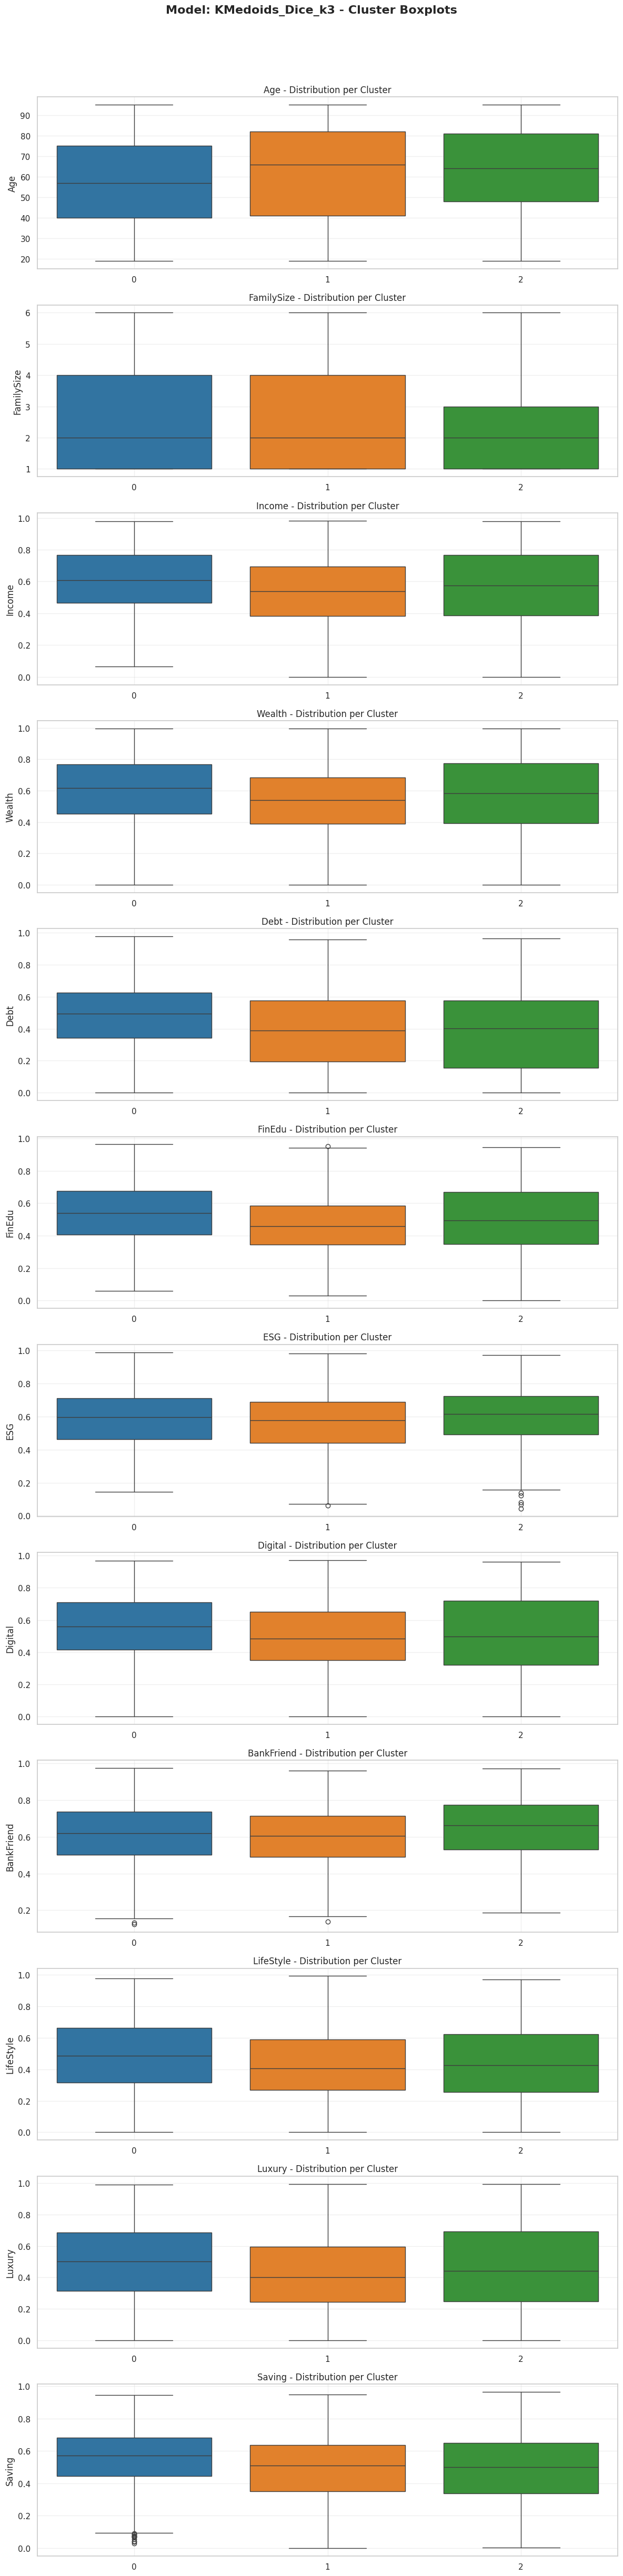

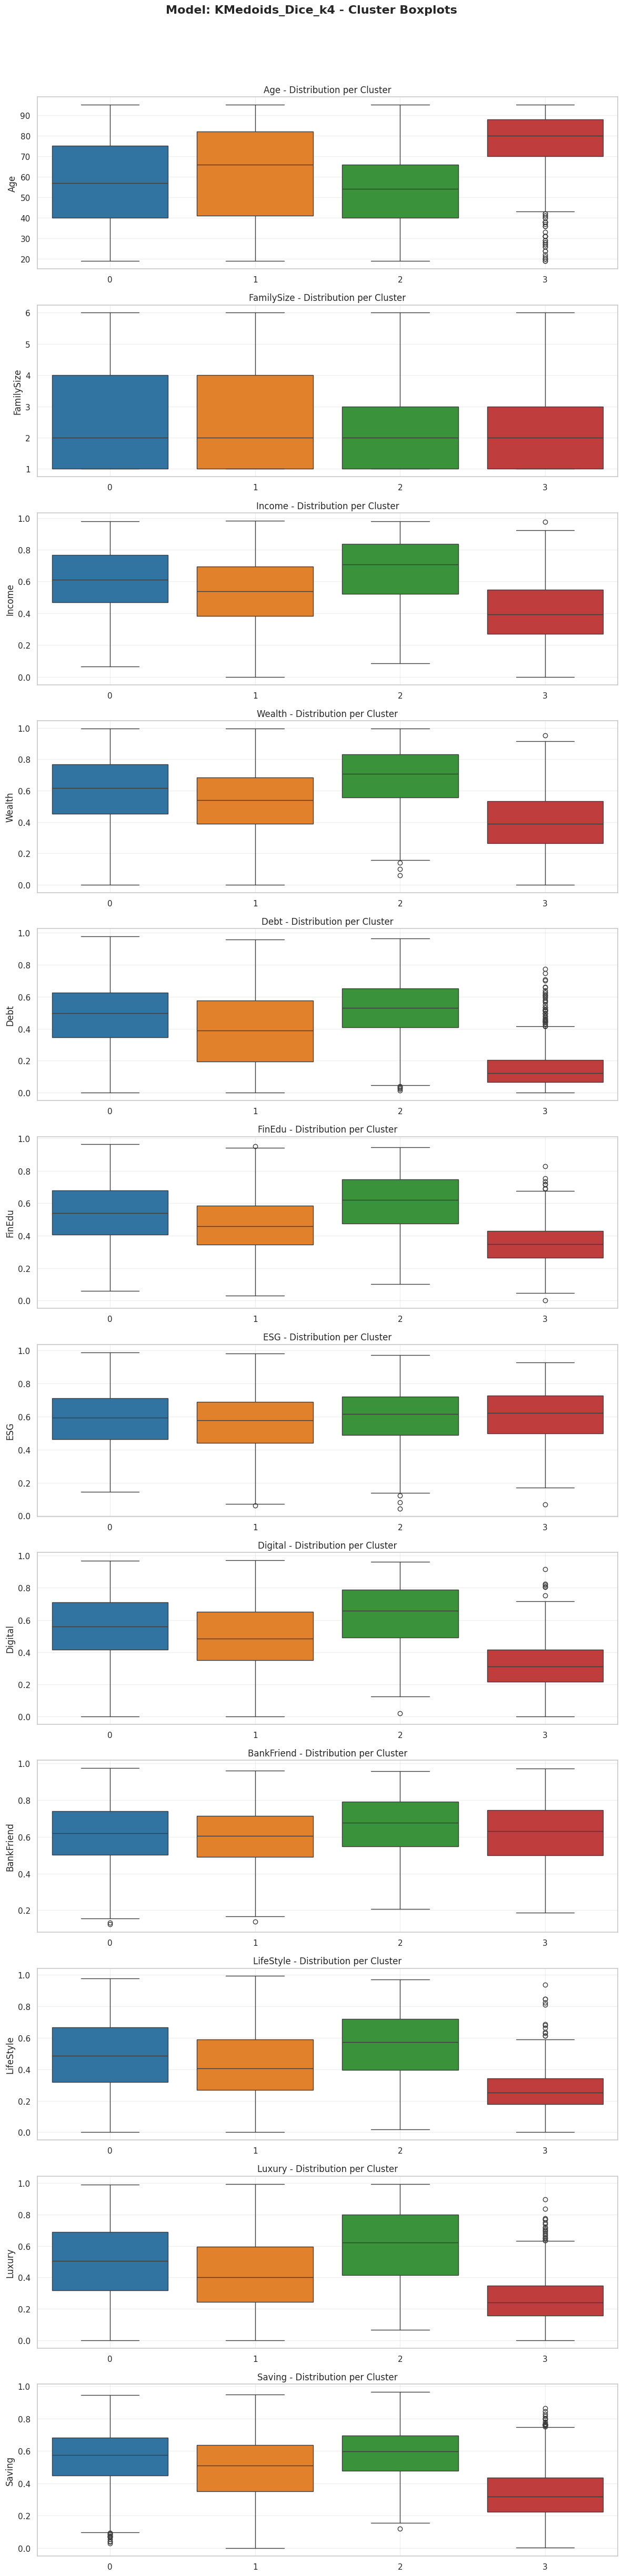

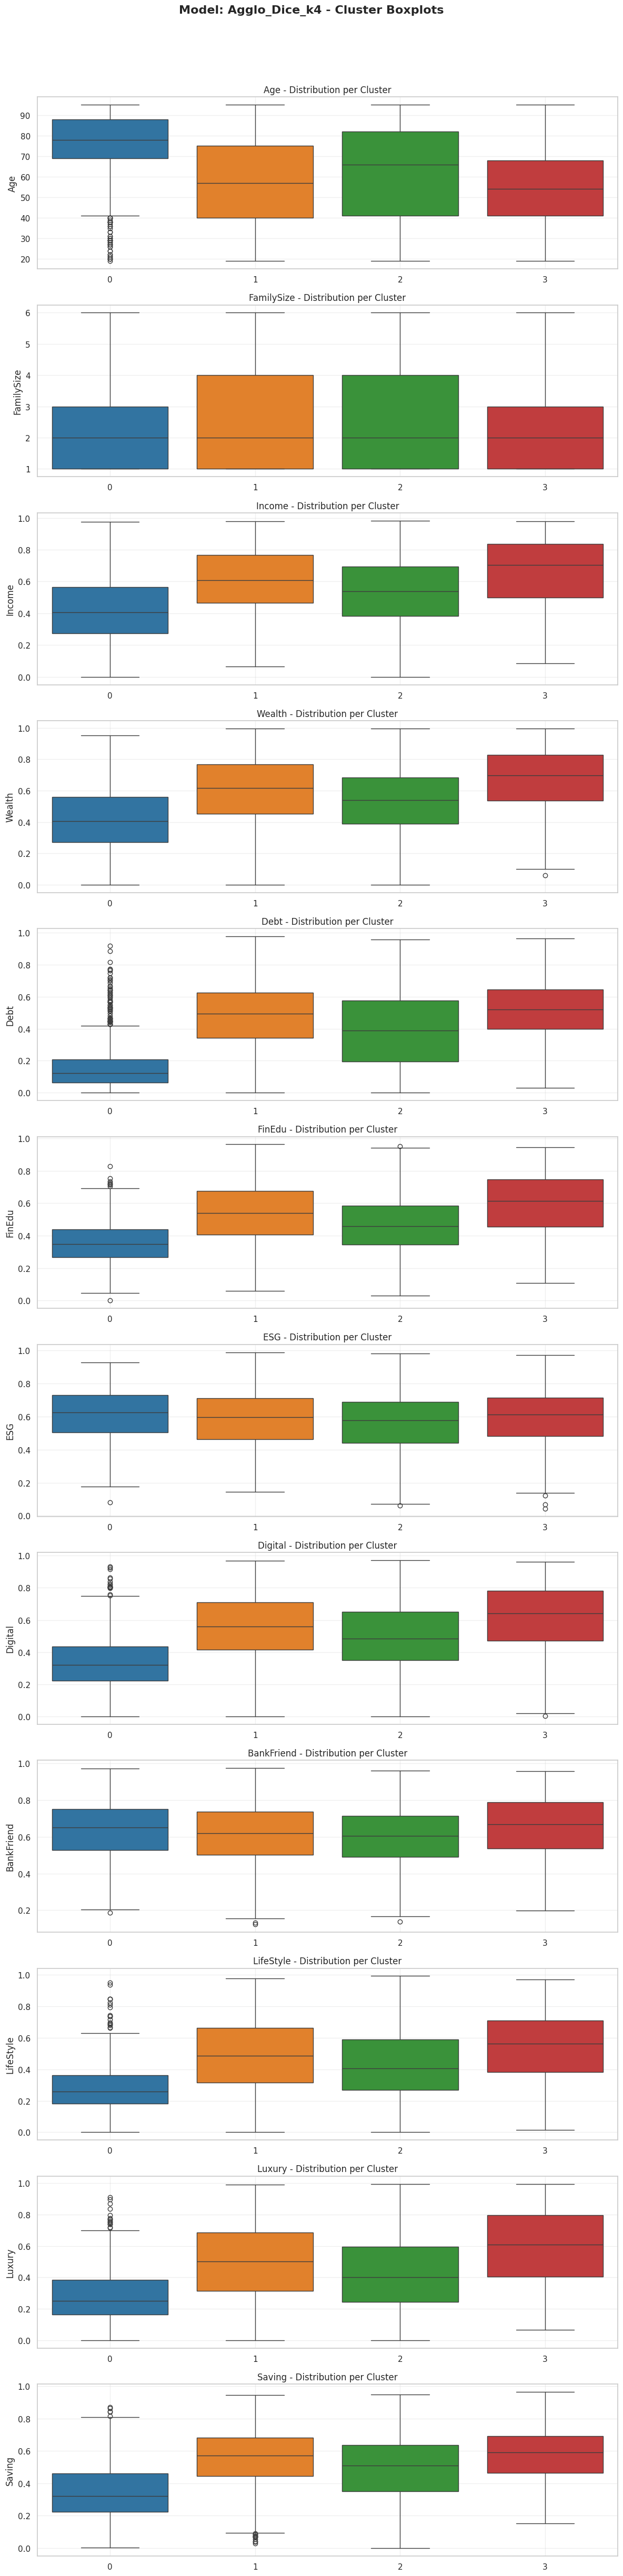

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_boxplots(data, num_cols, title_prefix=""):
    num_vars = len(num_cols)

    # Dynamic figure size based on the number of variables
    fig, axes = plt.subplots(num_vars, 1, figsize=(12, 4 * num_vars))
    fig.suptitle(f"{title_prefix} - Cluster Boxplots", fontsize=16, y=1.02, fontweight='bold')

    # Safety check for single-axis case
    if num_vars == 1:
        axes = [axes]

    # Plotting distributions for each variable across clusters
    for i, col in enumerate(num_cols):
        # Added hue="Cluster" for consistent coloring across clusters
        sns.boxplot(x="Cluster", y=col, data=data, ax=axes[i], hue="Cluster", palette="tab10", legend=False)
        axes[i].set_title(f"{col} - Distribution per Cluster", fontsize=12)
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlabel("") # Remove x-axis label for a cleaner look

    plt.tight_layout()
    plt.show()

# =========================================
# EXECUTION
# =========================================
# (Plotting numerical distributions for each selected model)
num_cols_to_plot = numerical_columns + other_columns

for model_name in comparison_results:
    plot_cluster_boxplots(
        comparison_results[model_name],
        num_cols=num_cols_to_plot,
        title_prefix=f"Model: {model_name}"
    )

## Choosing the number of clusters
After analyzing all 3 cases, we decided that the optimal number of clusters for our case is 4.
The choice of k=4 is appropriate from both a quantitative and qualitative point of view.
Qualitatively, the identified clusters are clearly distinct and interpretable, differing significantly along key dimensions such as:
age, economic capacity, financial behavior level of digitalization and financial education.
Each cluster therefore presents a specific profile, which can be described and associated with distinct economic behavior.
Furthermore, the clusters show business relevance, identifying useful segments for differentiated strategies:
conservative and relational customers (cluster 0),
accumulating families (cluster 1),
disinvested and wary customers (cluster 2),
influent and digitized customers (cluster 3).
After a careful analysis of each scenario, we concluded that a reduction in the number of clusters (such as k=3) would lead to a significant loss of information. Specifically, with 3 clusters, the segments were too similar to each other, differing significantly in only a very few features. This made the segmentation ineffective from a banking perspective, as it was difficult to build truly distinct and actionable Personas. On the other hand, an increase in k would risk generating segments that are too fragmented, less interpretable, and less operationally relevant. Therefore, k=4 represents the best compromise between explanatory ability, business utility, and interpretative simplicity.



## Cluster analysis (Agglomerative - Dice-Manhattan K=4)

**Cluster 0 (571 individuals) — Senior Conservative Traditionalists**
This segment is mainly composed of retired individuals, with a very high average age, around 75 years. The age distribution is strongly skewed upwards (median of 78, higher than the mean), indicating an extremely compact and consolidated core of over-75s. From a family point of view, it has the smallest nucleus (FamilySize = 2.12), which is consistent with older people living alone or in pairs, with children already outside the household. Economically, it is the weakest cluster: Income = 0.42 and Wealth = 0.43, these values indicate relatively limited economic availability, compatible with pension income and accumulated wealth that is not particularly high compared to the other segments. The Debt level = 0.17, on the other hand, is clearly the lowest; the absence of debt is a solid trait of this group, confirmed by a median close to zero (0.12), demonstrating a total closure towards new financial exposures. They practically do not resort to leverage, probably because they have already repaid the main debts or because they tend to avoid new exposures. From a skills point of view, the cluster shows the lowest FinEdu overall (0.36) and also the lowest level of Digital propensity (0.34), this means that these are users who are not very autonomous both in understanding financial products and in using digital channels. They are therefore not customers who manage complex tools or online operations firsthand. However, this low autonomy corresponds to a very high BankFriend (0.63), given that it is very important because it suggests a strong fiduciary relationship with the bank, in fact, not being competent or digitalized, they tend to rely on the institution and the consultant as reference figures. On the value level, an interesting fact emerges, namely the high ESG propensity (0.61), even if the cluster is not sophisticated from a financial point of view, it still shows a good sensitivity towards ethical and social issues. As for consumption, it is the most sober group, in fact LifeStyle = 0.29, Luxury = 0.29 and Saving = 0.36 are all the lowest values, this means that not only do they spend little on aspirational or lifestyle-related goods, but they also have a limited capacity to generate new savings. The personal profile fully confirms this reading, in fact the prevalent modality is retired. On the investment front, the lump sum method prevails, meaning that when they invest, they tend to do so episodically, probably by moving already accumulated capital, rather than with periodic payments. In summary, cluster 0 represents a segment of elderly, prudent, less autonomous, and highly relational customers, with low relative economic capacity, poor consumer orientation, and a strong need for reassurance.

**Cluster 1 — Active Families in Accumulation**
This is the largest segment of the sample (2190 individuals) and represents quite clearly the central segment of banking customers. The average age is around 58, but unlike the older clusters, this group presents a high demographic variability (age standard deviation of 21.27), actually embracing a very wide range of the active working population, from young adults to those close to retirement. From a family perspective, the cluster has relatively larger nuclei (FamilySize = 2.57), in line with structured families, often with economic responsibilities still present. On an economic level, the profile is solid, with high values of Income = 0.60 and Wealth = 0.61, this indicates a good income capacity and wealth already consolidated or in an advanced stage of construction. At the same time, the Debt level = 0.48 is quite high, this is a trait consistent with an active group that supports mortgages and family financing. From a skills point of view, the cluster shows a good FinEdu (0.54) and an equally good Digital propensity (0.56), which means that it is a segment capable of using digital channels and understanding financial instruments of medium-low or medium complexity. The relationship with the bank is positive, BankFriend = 0.61, a value that suggests a customer who trusts the institution, but without being completely dependent on it, is likely to use the bank simply as a support. On the value and consumption level, the cluster is in an intermediate but robust position, the ESG = 0.59 propensity is good, LifeStyle = 0.49 and Luxury = 0.50 show a medium-high level of average consumption. However, looking at the standard deviation for these consumption metrics (around 0.22 - 0.23), we observe a significant internal dispersion: there is no single uniform behavior, but rather a strong heterogeneity dictated by different family needs and monthly availability. The Saving propensity = 0.56 is very high and this is one of the distinctive elements of the group, in fact in addition to the high income there is also a propensity to save. Personal data reinforce this interpretation, the prevailing Job is employee/worker. Perhaps the most important feature concerns investments. Capital accumulation, or gradual investment with monthly payments, prevails. It is the only cluster where this mode dominates, making it the most consistent segment with a planning logic over time. In summary, Cluster 1 represents the heart of active banking customers, with economically strong families, physiological debt, good financial literacy, and strong savings capacity, who invest regularly and disciplinedly.

**Cluster 2 (1314 individuals) — Mature Cautious and Disinvested**
This segment is in a transitional demographic phase, with an average age of 61.50 years. Observing the distance between the mean age (61.5) and the median age (66), it is evident that a large part of this segment is already facing the transition towards retirement. The family size is relatively high (FamilySize = 2.58), a sign that from the point of view of the household these are not isolated people, but families that are still structured. From an economic point of view, the cluster occupies an intermediate position with Income = 0.54 and Wealth = 0.54, so we are not facing a fragile segment in terms of resources. Debt = 0.39 is also moderate, suggesting a phase of reduction in financial exposure. The real crux of this cluster emerges on a behavioral level, in fact FinEdu = 0.47 is low, while Digital propensity = 0.50 remains at medium but not high levels, therefore the customer has a minimal familiarity with digital, but not real financial autonomy. Another very relevant data is BankFriend = 0.60, which is the lowest value among the four clusters. This aspect, combined with low financial literacy, is essential to understanding the cluster profile. In terms of values and consumption, ESG = 0.57, the lowest value in the panel, LifeStyle = 0.43 and Luxury = 0.43, while Saving = 0.49, in other words, have resources and a certain capacity to save, but are not distinguished either by strong consumption or by a particular propensity to accumulate. The truly distinctive data is the one on investments, the prevailing modality is no investments, which makes cluster 2 unique compared to the others. The high standard deviation in Wealth levels (0.20) reveals a crucial detail: this financial immobility transversely affects both clients with modest assets and those with good resources blocked in their accounts due to excess caution and poor financial education. In fact, despite having non-critical economic conditions, this segment tends not to invest at all, presumably leaving liquidity stagnant, and this is precisely where the combination of prudence, low trust, and limited expertise is seen. The personal profile also helps; the most common job is employee/worker, so these aren't retirees but still active individuals. This reinforces the idea that the lack of investment doesn't stem from a lack of income, but rather from a choice of immobility. In summary, Cluster 2 represents a segment of mature, moderately solid but psychologically stuck customers with sufficient resources, low financial literacy, and a lukewarm relationship with the bank.

**Cluster 3 (925 individuals) — Digital and Premium Affluents**
This cluster is the economically strongest segment of the sample, with an average age of approximately 56 years. While not a “young” cluster in the absolute sense, it is the one that is in the most dynamic and high-performing phase of the economic life cycle. The family size (FamilySize = 2.40) remains compatible with stable nuclei. From an economic point of view, this is the leading group on all asset indicators with Income = 0.66, Wealth = 0.67 and Debt = 0.52. This economic solidity is structural and not dependent on a few isolated cases: very high medians for both Income (0.70) and Wealth (0.70) confirm a widespread well-being within the group. The latter data (Debt) should not be read as fragility, but rather as a more intense and conscious use of leverage. In terms of skills, the cluster is clearly the most advanced, in fact FinEdu = 0.60 is the highest, and the same is true for Digital propensity = 0.62. This identifies customers who are autonomous, prepared, and able to manage financial tools, platforms, and decisions with greater awareness than other segments. The relationship with the bank is also very strong, BankFriend = 0.65, this shows that high competence does not mean distance from the institution, on the contrary, this segment combines autonomy and trust, probably seeing the bank as a qualified partner and not just as a simple service provider. On the consumption plan, cluster 3 is also the one with the most aspirational profile, we have LifeStyle = 0.55, Luxury = 0.59 and Saving = 0.58, they are the highest values of the panel or very close to the maximums. It is interesting to note, however, that the propensity for luxury presents the highest standard deviation of the entire sample (0.24); this indicates that, although everyone has the spending capacity, only a part of the cluster directs its resources towards highly aspirational consumption, while another prefers to channel them into structured savings. This means that they can simultaneously maintain a high level of spending, a premium orientation and a strong saving capacity. The ESG propensity = 0.60 is also high, suggesting that economic well-being is accompanied by a value sensitivity that is still present. The personal data confirm the distinctive positioning, the prevalent Job is employee/worker, but compared to the other groups the cluster lives mainly in large cities (CitySize = 3), the only case in the sample. Furthermore, it is the only cluster where Gender = 0 prevails, i.e. the male component. On the investment side, the dominant lump sum mode, a signal consistent with individuals who already have substantial capital and allocate it to more significant transactions, rather than gradual payments. In summary, cluster 3 represents the richest, most competent, digitized, and premium-oriented segment of the sample. It is a high-value group, combining economic ability, financial literacy, trust in the bank and quality research.

## Defining Personas

**Persona 1: Laura — the Conservative Keeper (Cluster 0 — Senior Traditionalists)**

Laura is 75 years old, retired and lives with her husband. She has a fixed income and limited wealth, she paid off his mortgage years ago. Her income is fixed and comes mainly from retirement, while her wealth is the result of savings accumulated over the course of her life, which have allowed him to pay off his mortgage and other debts.
He's unfamiliar with digital tools and rarely uses online services; in fact, for him, banking is still a physical place, made up of people and relationships. Her financial education is limited, which is why he tends to avoid complex products and autonomous decisions.
Its main goal is not to grow capital, but to preserve it. Laura has a strong aversion to risk and fears above all losing what he has built over the years. For this reason, he relies entirely on the bank and the consultant, with whom he has a consolidated relationship of trust.
When investing, it does so rarely and occasionally, using already available capital rather than planning over time. It prefers simple, safe and easily understandable tools.
For the bank, Laura represents a highly relational customer, requiring reassurance, simplicity, and human presence. Strategies based on digitalization or complex products are ineffective, but it is essential to maintain a direct relationship and propose low-risk solutions.

**Persona 2: Frank — the Family Planner (Cluster 1 — Families in Accumulation)**

Frank is about 58 years old, works and lives in a family with one or two children, with financial responsibilities still active. He has a good income, but also important commitments such as mortgage, family expenses and child support.
Unlike Laura, Frank is quite independent, using digital tools for day-to-day financial management with ease, and has a good financial education, which allows her to understand the main investment opportunities.
His goal is to build stability over time. He wants to grow his savings, for example, to pay off his mortgage and have his children study gradually, without exposing himself to excessive risk. She is careful about planning and tends to prefer structured and disciplined solutions.
In fact, its financial behavior is characterized by the use of accumulation tools, such as periodic investment plans, and it does not necessarily have large immediate capital, but manages to save continuously and invest regularly.
Its main difficulties concern time and complexity, it needs clear, reliable and easily manageable solutions.
For the bank, Laura represents an active and strategic customer, ideal for long-term accumulation and planning products. The winning approach is to offer simple, automated and integrated tools with advisory support.



**Persona 3: Giulia — the Blocked Saver (Cluster 2 — Mature Disinvested)**

Giulia is about 61 years old and still working, but is approaching retirement. His economic situation is fair, he has a stable income and an average level of wealth.
Despite this, its financial behavior is characterized by strong inactivity. Giulia does not invest and tends to keep liquidity firm in the account, avoiding any decisions that involve risk or complexity.
This choice does not stem from a lack of resources, but rather from a combination of low financial literacy and low trust in the bank. Giulia perceives the investment world as uncertain and opaque, and fears making bad choices.
He uses digital services only in a basic way and does not feel competent enough to manage his finances independently.
Its main objective is to maintain economic stability without exposing itself to risk. However, this attitude leads her to miss opportunities for capital growth.
For the bank, Giulia represents a critical but high-potential customer. The real goal isn't to immediately sell products, but to rebuild trust and gradually guide her toward simple and understandable investment choices.

**Persona 4: Marco — the Evolved Investor (Cluster 3 — Affluent Premium)**

Marco is about 55 years old, lives in a big city and is an established professional, as a manager or entrepreneur. It has a high income and significant assets, which it actively manages.
It is highly digitalized and has a high level of financial education, in fact it knows the markets, understands the products and makes decisions independently. It uses advanced digital tools and expects efficient and fast services.
Unlike the other clusters, Marco not only has economic capacity, but also a strong propensity for consumption and lifestyle, including luxury goods, but at the same time, it maintains a solid savings capacity.
Its goal is to maximize returns and optimize assets, while maintaining control and flexibility. When it invests, it often does so with large-value operations, taking advantage of already available capital.
Despite its high level of autonomy, Marco has a good relationship with the bank, which it considers a qualified partner, as long as it is able to offer services that meet its expectations.
For the bank, Marco represents a very high-value client, requiring customized solutions, advanced consulting, and premium services. Standard or inflexible offers are inadequate for this segment.


# 4- Bayesian clustering

In this section we introduce an extension of traditional clustering based on a Bayesian approach. This model is used to make the representation of the persona within each cluster dynamic.

The key idea is:
- the cluster is a static structure (global segmentation);
- the persona is modeled through probability distributions;
- new observations update these distributions via Bayesian inference.

For variables normalized in [0,1], we use the Beta distribution, which allows us to model both the mean value and the uncertainty. When a new customer is observed, the clustering is not recomputed; instead, the parameters (alpha, beta) are updated, producing a new version of the persona.



## A) Univariate analysis

In the univariate setting, each feature of the persona is modeled independently using a Beta distribution.

For each feature:
- we start from the cluster mean (initial persona);
- we define a Beta distribution with parameters (alpha, beta);
- the parameter N controls how strong the prior is (how much we trust the initial persona).

We then introduce three synthetic customers: 1) coherent, 2) different, 3) very different.

The Bayesian update is performed by updating alpha and beta with the new observation. This produces a new distribution for each feature and therefore a new mean (posterior). In this way, we get a dynamic and interpretable representation of the persona.

In [ ]:
# MODELLO FINALE

final_labels_agglo_dice_k4, final_model_agglo_dice_k4 = run_agglomerative(
    distance_matrix=distance_matrices["dice_manhattan"],
    k=4,
    linkage="average"
)

data_agglo_dice_k4 = data.copy()
data_agglo_dice_k4["Cluster"] = final_labels_agglo_dice_k4

cluster_sizes = pd.Series(final_labels_agglo_dice_k4).value_counts().sort_index()

I choose which cluster might be interesting to do it on

In [ ]:
# Usiamo il dataframe 'data_agglo_dice_k4' perché è quello che ha la colonna "Cluster"
cluster_stats = data_agglo_dice_k4.groupby("Cluster").agg({
    "Age": "count",        # Conteggio dei membri
    "Digital": ["mean", "std"],
    "Saving": ["mean", "std"],
    "Debt": ["mean", "std"],
    "Luxury": ["mean", "std"]
})

# Rinominiano le colonne per renderle leggibili
cluster_stats.columns = ["count", "Digital_mean", "Digital_std",
                         "Saving_mean", "Saving_std",
                         "Debt_mean", "Debt_std",
                         "Luxury_mean", "Luxury_std"]

# Ordiniamo per dimensione del cluster
cluster_stats = cluster_stats.sort_values("count", ascending=False)

print("\nProfilo Medio dei Cluster (K=4):")
display(cluster_stats.round(3))


Profilo Medio dei Cluster (K=4):


,count,Digital_mean,Digital_std,Saving_mean,Saving_std,Debt_mean,Debt_std,Luxury_mean,Luxury_std
Cluster,,,,,,,,,
1,2190,0.555,0.200,0.560,0.166,0.481,0.202,0.504,0.231
2,1314,0.500,0.208,0.489,0.195,0.393,0.223,0.426,0.224
3,925,0.617,0.200,0.578,0.153,0.519,0.173,0.589,0.239
0,571,0.340,0.173,0.356,0.181,0.173,0.165,0.291,0.171


I choose cluster 2. It has an intermediate size so it is stable but not dominant, it has central means far from the extremes so the Beta is not saturated, and it has a relatively high variance (which makes the effect of the update visible)


CREATION OF THE PERSONAS

In [ ]:
from scipy.stats import beta as beta_dist

# Variabili numeriche/persona da aggiornare con Beta
persona_features = [
    'Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
    'FinEdu', 'ESG', 'Digital', 'BankFriend',
    'LifeStyle', 'Luxury', 'Saving'
]

data = data_agglo_dice_k4.copy()

cluster_id = 2
cluster_data = data[data['Cluster'] == cluster_id].copy()

persona_mean = cluster_data[persona_features].mean().clip(1e-4, 1 - 1e-4)

print("Persona iniziale (media del cluster):")
display(persona_mean.to_frame("mean"))

Persona iniziale (media del cluster):


,mean
Age,0.999900
FamilySize,0.999900
Income,0.535747
Wealth,0.536859
Debt,0.392558
FinEdu,0.469056
ESG,0.567615
Digital,0.500123
BankFriend,0.600880
LifeStyle,0.434593


TRANSFORMATION OF THE AVERAGE PERSONA INTO PRIOR BETA

In [ ]:
N_prior = 20  # peso iniziale della persona/cluster

alpha_prior = persona_mean * N_prior
beta_prior = (1 - persona_mean) * N_prior

prior_df = pd.DataFrame({
    "mean_prior": persona_mean,
    "alpha_prior": alpha_prior,
    "beta_prior": beta_prior
})

display(prior_df)

,mean_prior,alpha_prior,beta_prior
Age,0.999900,19.998000,0.002000
FamilySize,0.999900,19.998000,0.002000
Income,0.535747,10.714947,9.285053
Wealth,0.536859,10.737189,9.262811
Debt,0.392558,7.851164,12.148836
FinEdu,0.469056,9.381122,10.618878
ESG,0.567615,11.352300,8.647700
Digital,0.500123,10.002451,9.997549
BankFriend,0.600880,12.017591,7.982409
LifeStyle,0.434593,8.691854,11.308146


SYNTHETIC CLIENT GENERATION

I will generate three types of client:
- consistent client
- diverse client
- very diverse client

In [ ]:
base = persona_mean.copy()

synthetic_clients = {
    "coerente": base.copy(),
    "diverso": base.copy(),
    "molto_diverso": base.copy()
}

coherent client

In [ ]:
np.random.seed(42)

synthetic_clients["coerente"] = (
    base + np.random.normal(0, 0.05, len(base))
).clip(0.001, 0.999)

diverse client

In [ ]:
synthetic_clients["diverso"]["Digital"] = min(base["Digital"] + 0.25, 0.999)
synthetic_clients["diverso"]["FinEdu"] = min(base["FinEdu"] + 0.20, 0.999)
synthetic_clients["diverso"]["BankFriend"] = max(base["BankFriend"] - 0.20, 0.001)
synthetic_clients["diverso"]["Luxury"] = min(base["Luxury"] + 0.15, 0.999)
synthetic_clients["diverso"]["Saving"] = min(base["Saving"] + 0.10, 0.999)

very diverse client

In [ ]:
synthetic_clients["molto_diverso"]["Digital"] = 0.95
synthetic_clients["molto_diverso"]["FinEdu"] = 0.90
synthetic_clients["molto_diverso"]["BankFriend"] = 0.20
synthetic_clients["molto_diverso"]["Luxury"] = 0.85
synthetic_clients["molto_diverso"]["LifeStyle"] = 0.80
synthetic_clients["molto_diverso"]["Debt"] = 0.70
synthetic_clients["molto_diverso"]["Saving"] = 0.75

In [ ]:
synthetic_df = pd.DataFrame(synthetic_clients).T[persona_features]
display(synthetic_df)

,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving
coerente,0.9990,0.992987,0.568132,0.613011,0.380851,0.457349,0.646576,0.538494,0.577406,0.461721,0.402798,0.465607
diverso,0.9999,0.999900,0.535747,0.536859,0.392558,0.669056,0.567615,0.750123,0.400880,0.434593,0.575969,0.588893
molto_diverso,0.9999,0.999900,0.535747,0.536859,0.700000,0.900000,0.567615,0.950000,0.200000,0.800000,0.850000,0.750000


BAYESIAN UPDATE

In [ ]:
def bayesian_update_beta(alpha, beta, new_observation, weight=1.0):
    alpha_new = alpha + weight * new_observation
    beta_new = beta + weight * (1 - new_observation)
    return alpha_new, beta_new

very diverse client

In [ ]:
selected_client = synthetic_clients["molto_diverso"]   # oppure "coerente", "molto_diverso"
w_new = 5                                              # peso del nuovo cliente

alpha_post, beta_post = bayesian_update_beta(
    alpha_prior.values,
    beta_prior.values,
    selected_client.values,
    weight=w_new
)

posterior_mean = alpha_post / (alpha_post + beta_post)

posterior_df = pd.DataFrame({
    "feature": persona_features,
    "prior_mean": persona_mean.values,
    "new_client": selected_client.values,
    "posterior_mean": posterior_mean,
    "delta": posterior_mean - persona_mean.values
})

display(posterior_df.sort_values("delta", key=np.abs, ascending=False))

,feature,prior_mean,new_client,posterior_mean,delta
7,Digital,0.500123,0.950000,0.590098,8.997549e-02
5,FinEdu,0.469056,0.900000,0.555245,8.618878e-02
10,Luxury,0.425969,0.850000,0.510775,8.480619e-02
8,BankFriend,0.600880,0.200000,0.520704,-8.017591e-02
9,LifeStyle,0.434593,0.800000,0.507674,7.308146e-02
4,Debt,0.392558,0.700000,0.454047,6.148836e-02
11,Saving,0.488893,0.750000,0.541114,5.222140e-02
0,Age,0.999900,0.999900,0.999900,-1.110223e-16
1,FamilySize,0.999900,0.999900,0.999900,-1.110223e-16
3,Wealth,0.536859,0.536859,0.536859,1.110223e-16



BEFORE AND AFTER COMPARISON

In [ ]:
comparison_df = posterior_df.copy()
comparison_df["abs_delta"] = comparison_df["delta"].abs()
comparison_df = comparison_df.sort_values("abs_delta", ascending=False)

display(comparison_df)

,feature,prior_mean,new_client,posterior_mean,delta,abs_delta
7,Digital,0.500123,0.950000,0.590098,8.997549e-02,8.997549e-02
5,FinEdu,0.469056,0.900000,0.555245,8.618878e-02,8.618878e-02
10,Luxury,0.425969,0.850000,0.510775,8.480619e-02,8.480619e-02
8,BankFriend,0.600880,0.200000,0.520704,-8.017591e-02,8.017591e-02
9,LifeStyle,0.434593,0.800000,0.507674,7.308146e-02,7.308146e-02
4,Debt,0.392558,0.700000,0.454047,6.148836e-02,6.148836e-02
11,Saving,0.488893,0.750000,0.541114,5.222140e-02,5.222140e-02
0,Age,0.999900,0.999900,0.999900,-1.110223e-16,1.110223e-16
1,FamilySize,0.999900,0.999900,0.999900,-1.110223e-16,1.110223e-16
3,Wealth,0.536859,0.536859,0.536859,1.110223e-16,1.110223e-16


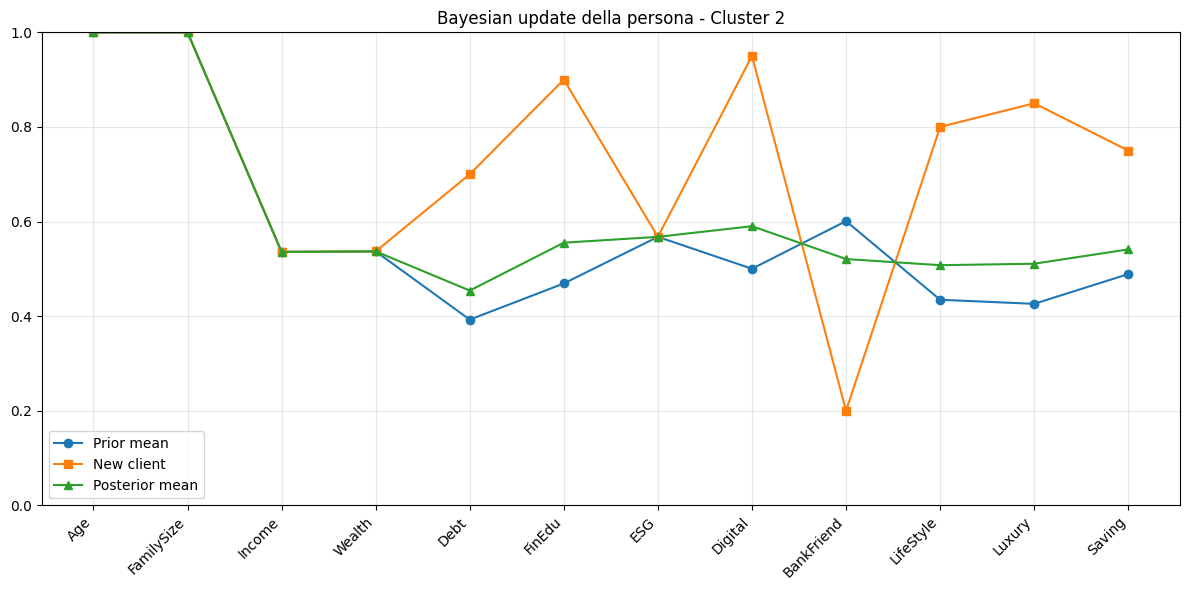

In [ ]:
plt.figure(figsize=(12, 6))
x = np.arange(len(persona_features))

plt.plot(x, persona_mean.values, 'o-', label="Prior (Cluster)", color='royalblue', alpha=0.3, markersize=8)
plt.plot(x, selected_client.values, 's--', label="Observed (Cliente)", color='orange', alpha=0.5)
plt.plot(x, posterior_mean, '^-', label="Posterior (AI)", color='green', linewidth=3, markersize=10)

plt.xticks(x, persona_features, rotation=45, ha='right')
plt.ylim(0, 1)
plt.title(f"Bayesian update della persona - Cluster {cluster_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def plot_beta_comparison(features, alpha_prior, beta_prior, alpha_post, beta_post, max_cols=4):
    # Calculate the total number of features to plot
    n = len(features)

    # Define the grid layout for the subplots (number of columns and rows)
    ncols = max_cols
    nrows = int(np.ceil(n / ncols))

    # Generate 500 points between 0.001 and 0.999 for the X-axis
    # (avoiding exactly 0 and 1 to prevent division by zero or infinity issues in Beta PDF)
    x = np.linspace(0.001, 0.999, 500)

    # Initialize the matplotlib figure and axes grid
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))

    # Flatten the axes array to easily iterate over it with a single loop
    axes = np.array(axes).reshape(-1)

    # Loop through each feature to generate its specific plot
    for i, feat in enumerate(features):
        ax = axes[i]

        # Calculate the Probability Density Function (PDF) for both Prior and Posterior distributions
        y_prior = beta_dist.pdf(x, alpha_prior[i], beta_prior[i])
        y_post = beta_dist.pdf(x, alpha_post[i], beta_post[i])

        # Plot the Prior and Posterior curves
        ax.plot(x, y_prior, label='Prior')
        ax.plot(x, y_post, label='Posterior')

        # Draw vertical lines representing the expected value (mean) of each distribution
        # The mean of a Beta distribution is calculated as alpha / (alpha + beta)
        ax.axvline(alpha_prior[i] / (alpha_prior[i] + beta_prior[i]), linestyle='--')
        ax.axvline(alpha_post[i] / (alpha_post[i] + beta_post[i]), linestyle=':')

        # Set chart titles and formatting for the current subplot
        ax.set_title(feat)
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.2)

    # Remove any unused subplots (empty grid cells) if the number of features
    # is not a perfect multiple of max_cols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Extract the legend handles from the first subplot and place a single global legend
    # at the top center of the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)

    # Adjust layout to prevent overlapping and leave space for the top legend
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

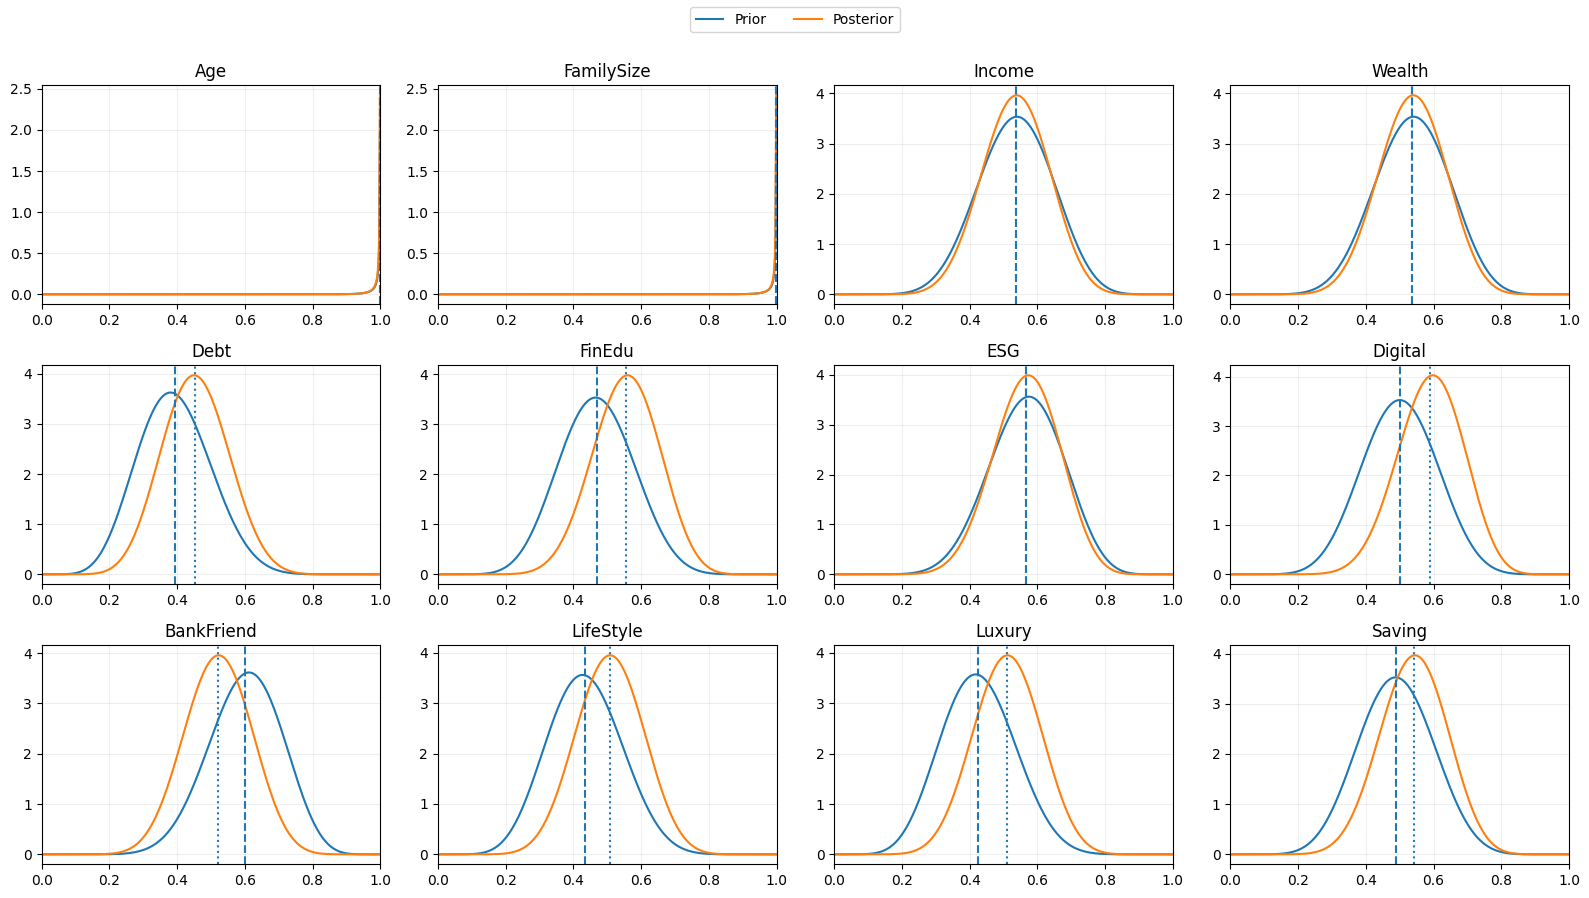

In [ ]:
plot_beta_comparison(
    persona_features,
    alpha_prior.values,
    beta_prior.values,
    alpha_post,
    beta_post
)

COMPARISON

coherent client

,feature,prior_mean,new_client,posterior_mean,delta,abs_delta
6,ESG,0.567615,0.646576,0.583407,0.015792,0.015792
3,Wealth,0.536859,0.613011,0.552090,0.015230,0.015230
7,Digital,0.500123,0.538494,0.507797,0.007674,0.007674
2,Income,0.535747,0.568132,0.542224,0.006477,0.006477
9,LifeStyle,0.434593,0.461721,0.440018,0.005426,0.005426
8,BankFriend,0.600880,0.577406,0.596185,-0.004695,0.004695
11,Saving,0.488893,0.465607,0.484236,-0.004657,0.004657
10,Luxury,0.425969,0.402798,0.421335,-0.004634,0.004634
4,Debt,0.392558,0.380851,0.390217,-0.002342,0.002342
5,FinEdu,0.469056,0.457349,0.466715,-0.002341,0.002341


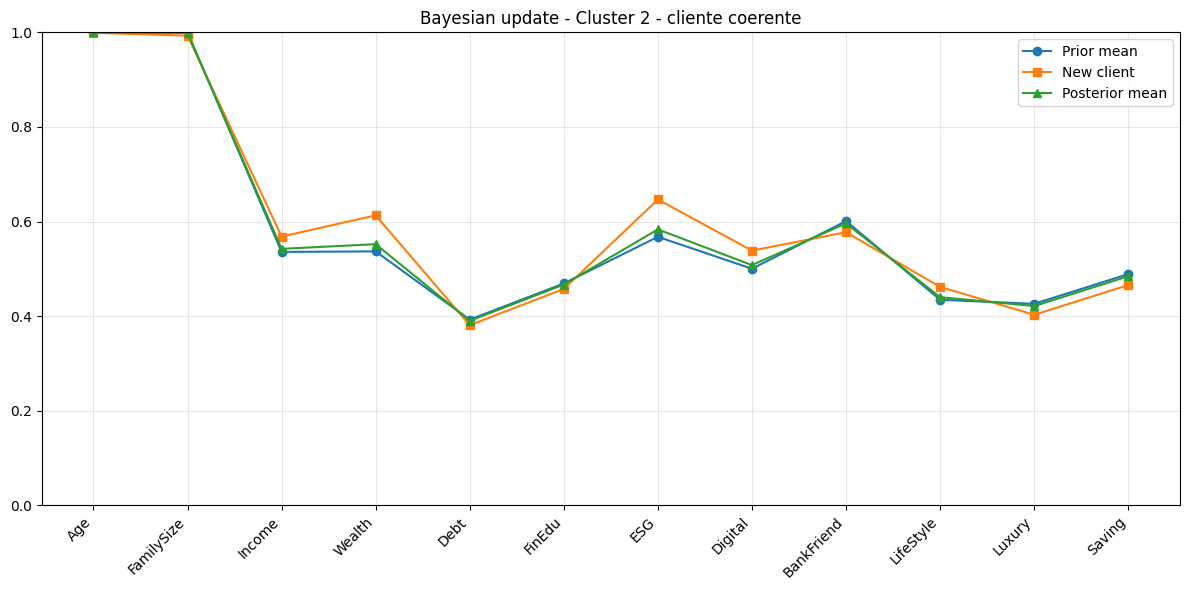

In [ ]:
# SELECTION AND BAYESIAN UPDATE
# Select the specific synthetic client to use for the update
selected_name = "coerente"
selected_client = synthetic_clients[selected_name]

# Define the weight of the new observation (how much impact the new client has on the prior)
w_new = 5

# Perform the Bayesian update of the Beta distribution parameters
# taking the prior parameters and updating them with the new client's data
alpha_post, beta_post = bayesian_update_beta(
    alpha_prior.values,
    beta_prior.values,
    selected_client.values,
    weight=w_new
)

# Calculate the expected value (mean) of the newly updated Posterior distribution
posterior_mean = alpha_post / (alpha_post + beta_post)


# COMPARISON DATAFRAME CREATION
# Build a DataFrame to easily compare the initial state, the new data, and the final state
comparison_df = pd.DataFrame({
    "feature": persona_features,
    "prior_mean": persona_mean.values,
    "new_client": selected_client.values,
    "posterior_mean": posterior_mean
})

# Calculate the shift (delta) caused by the Bayesian update for each feature
comparison_df["delta"] = comparison_df["posterior_mean"] - comparison_df["prior_mean"]
# Calculate the absolute delta to evaluate the magnitude of the change regardless of the direction
comparison_df["abs_delta"] = comparison_df["delta"].abs()
# Sort the DataFrame descending by absolute delta to highlight the features that changed the most
comparison_df = comparison_df.sort_values("abs_delta", ascending=False)

# Display the resulting table
display(comparison_df)


# VISUALIZATION OF THE UPDATE
# Plot the Prior mean, the New Client's profile, and the resulting Posterior mean
plt.figure(figsize=(12, 6))
x = np.arange(len(persona_features))

# Plot the three lines with different markers for clear visual distinction
plt.plot(x, persona_mean.values, 'o-', label="Prior (Cluster)", color='royalblue', alpha=0.3, markersize=8)
plt.plot(x, selected_client.values, 's--', label="Observed (Cliente)", color='orange', alpha=0.5)
plt.plot(x, posterior_mean, '^-', label="Posterior (AI)", color='green', linewidth=3, markersize=10)

# Format the X-axis with feature names
plt.xticks(x, persona_features, rotation=45, ha='right')
# Set the Y-axis limits between 0 and 1 (typical for normalized features or probabilities)
plt.ylim(0, 1)

plt.title(f"Bayesian update - Cluster {cluster_id} - cliente {selected_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

diverse client

,feature,prior_mean,new_client,posterior_mean,delta,abs_delta
7,Digital,0.500123,0.750123,0.550123,5.000000e-02,5.000000e-02
8,BankFriend,0.600880,0.400880,0.560880,-4.000000e-02,4.000000e-02
5,FinEdu,0.469056,0.669056,0.509056,4.000000e-02,4.000000e-02
10,Luxury,0.425969,0.575969,0.455969,3.000000e-02,3.000000e-02
11,Saving,0.488893,0.588893,0.508893,2.000000e-02,2.000000e-02
3,Wealth,0.536859,0.536859,0.536859,1.110223e-16,1.110223e-16
1,FamilySize,0.999900,0.999900,0.999900,-1.110223e-16,1.110223e-16
0,Age,0.999900,0.999900,0.999900,-1.110223e-16,1.110223e-16
9,LifeStyle,0.434593,0.434593,0.434593,-5.551115e-17,5.551115e-17
2,Income,0.535747,0.535747,0.535747,0.000000e+00,0.000000e+00


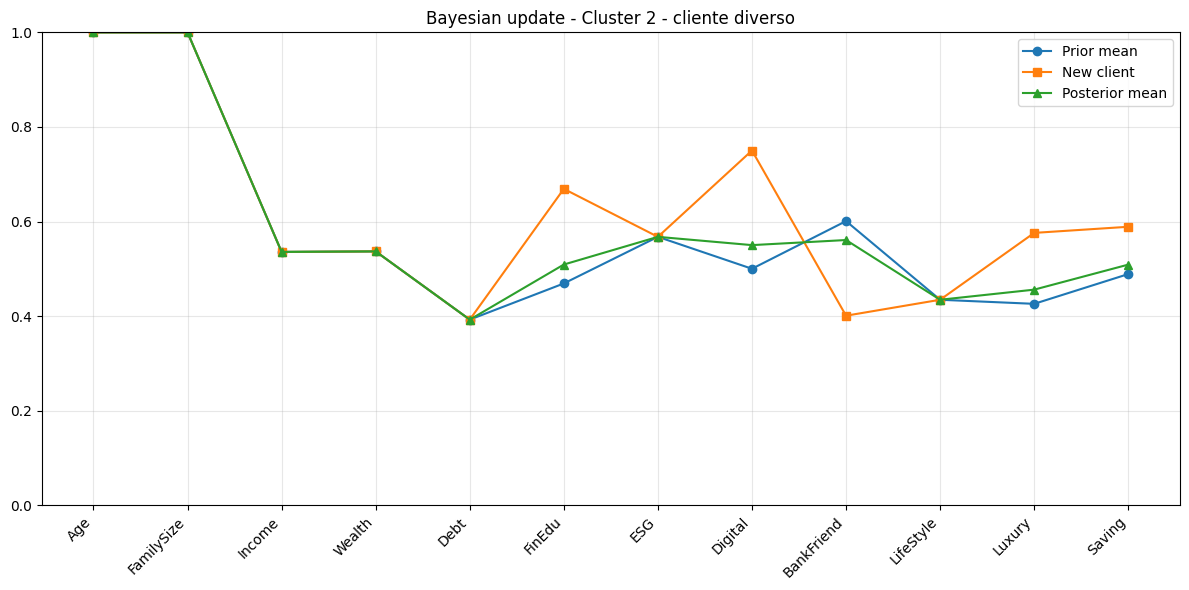

In [ ]:
# SELECTION AND BAYESIAN UPDATE
# Select the specific synthetic client to use for the update ("diverso" means different)
selected_name = "diverso"
selected_client = synthetic_clients[selected_name]

# Define the weight of the new observation (determines how much the new data influences the prior)
w_new = 5

# Perform the Bayesian update of the Beta distribution parameters
# taking the prior parameters and updating them with the new client's data
alpha_post, beta_post = bayesian_update_beta(
    alpha_prior.values,
    beta_prior.values,
    selected_client.values,
    weight=w_new
)

# Calculate the expected value (mean) of the newly updated Posterior distribution
posterior_mean = alpha_post / (alpha_post + beta_post)


# COMPARISON DATAFRAME CREATION
# Build a DataFrame to easily compare the initial state, the new data, and the final state
comparison_df = pd.DataFrame({
    "feature": persona_features,
    "prior_mean": persona_mean.values,
    "new_client": selected_client.values,
    "posterior_mean": posterior_mean
})

# Calculate the shift (delta) caused by the Bayesian update for each feature
comparison_df["delta"] = comparison_df["posterior_mean"] - comparison_df["prior_mean"]
# Calculate the absolute delta to evaluate the magnitude of the change regardless of the direction
comparison_df["abs_delta"] = comparison_df["delta"].abs()
# Sort the DataFrame descending by absolute delta to highlight the features that changed the most
comparison_df = comparison_df.sort_values("abs_delta", ascending=False)

# Display the resulting table
display(comparison_df)


# VISUALIZATION OF THE UPDATE
# Plot the Prior mean, the New Client's profile, and the resulting Posterior mean
plt.figure(figsize=(12, 6))
x = np.arange(len(persona_features))

# Plot the three lines with different markers for clear visual distinction
plt.plot(x, persona_mean.values, 'o-', label="Prior (Cluster)", color='royalblue', alpha=0.3, markersize=8)
plt.plot(x, selected_client.values, 's--', label="Observed (Cliente)", color='orange', alpha=0.5)
plt.plot(x, posterior_mean, '^-', label="Posterior (AI)", color='green', linewidth=3, markersize=10)

# Format the X-axis with feature names
plt.xticks(x, persona_features, rotation=45, ha='right')
# Set the Y-axis limits between 0 and 1 (typical for normalized features or probabilities)
plt.ylim(0, 1)

# Set the title and add visual elements like legend and grid
plt.title(f"Bayesian update - Cluster {cluster_id} - cliente {selected_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In the consistent case, the updated profile remains very close to the initial persona: the posterior values differ only marginally from the prior, meaning that the new customer provides information that is fully aligned with the existing cluster. As a result, the Bayesian update mainly reduces uncertainty and reinforces the stability of the persona without changing its structure.

In the non-consistent case, some features shift in a noticeable but controlled way: the posterior moves toward the new observation, but the prior still has a visible influence. This leads to a gradual adaptation of the persona, where certain behavioral dimensions are updated while the overall identity of the cluster remains intact.

In the very non-consistent case, the update produces larger shifts in the affected variables: the posterior is pulled significantly toward the new customer, especially along the dimensions that differ the most. This results in a partial repositioning of the persona, where the internal balance between features changes, even though the underlying cluster assignment is not modified.

## B) Multivariate analysis

In the bivariate setting, the model is extended to capture dependencies between pairs of variables. The goal is to overcome the independence assumption of the univariate approach and model relationships between behaviors.

In this case:
- we consider pairs of features;
- we analyze how their joint profile evolves after the update;
- we observe not only changes in means, but also changes in their relationship.

This allows a more realistic representation of customer behavior.


 ANALISI BAYESIANA MULTIVARIATA: CLIENTE 'COERENTE'

1. TABELLA DEI DELTA (Ordinata per importanza dello spostamento):


,Feature,Prior (Cluster),Observed (Dato),Posterior (AI),Delta
0,Wealth,0.536859,0.613011,0.584508,4.764848e-02
1,ESG,0.567615,0.646576,0.610908,4.329334e-02
2,Digital,0.500123,0.538494,0.527528,2.740541e-02
3,Income,0.535747,0.568132,0.561063,2.531544e-02
4,LifeStyle,0.434593,0.461721,0.455530,2.093717e-02
5,Saving,0.488893,0.465607,0.478336,-1.055676e-02
6,Luxury,0.425969,0.402798,0.417050,-8.919080e-03
7,Debt,0.392558,0.380851,0.386595,-5.963168e-03
8,BankFriend,0.600880,0.577406,0.596919,-3.960228e-03
9,FinEdu,0.469056,0.457349,0.468507,-5.495615e-04


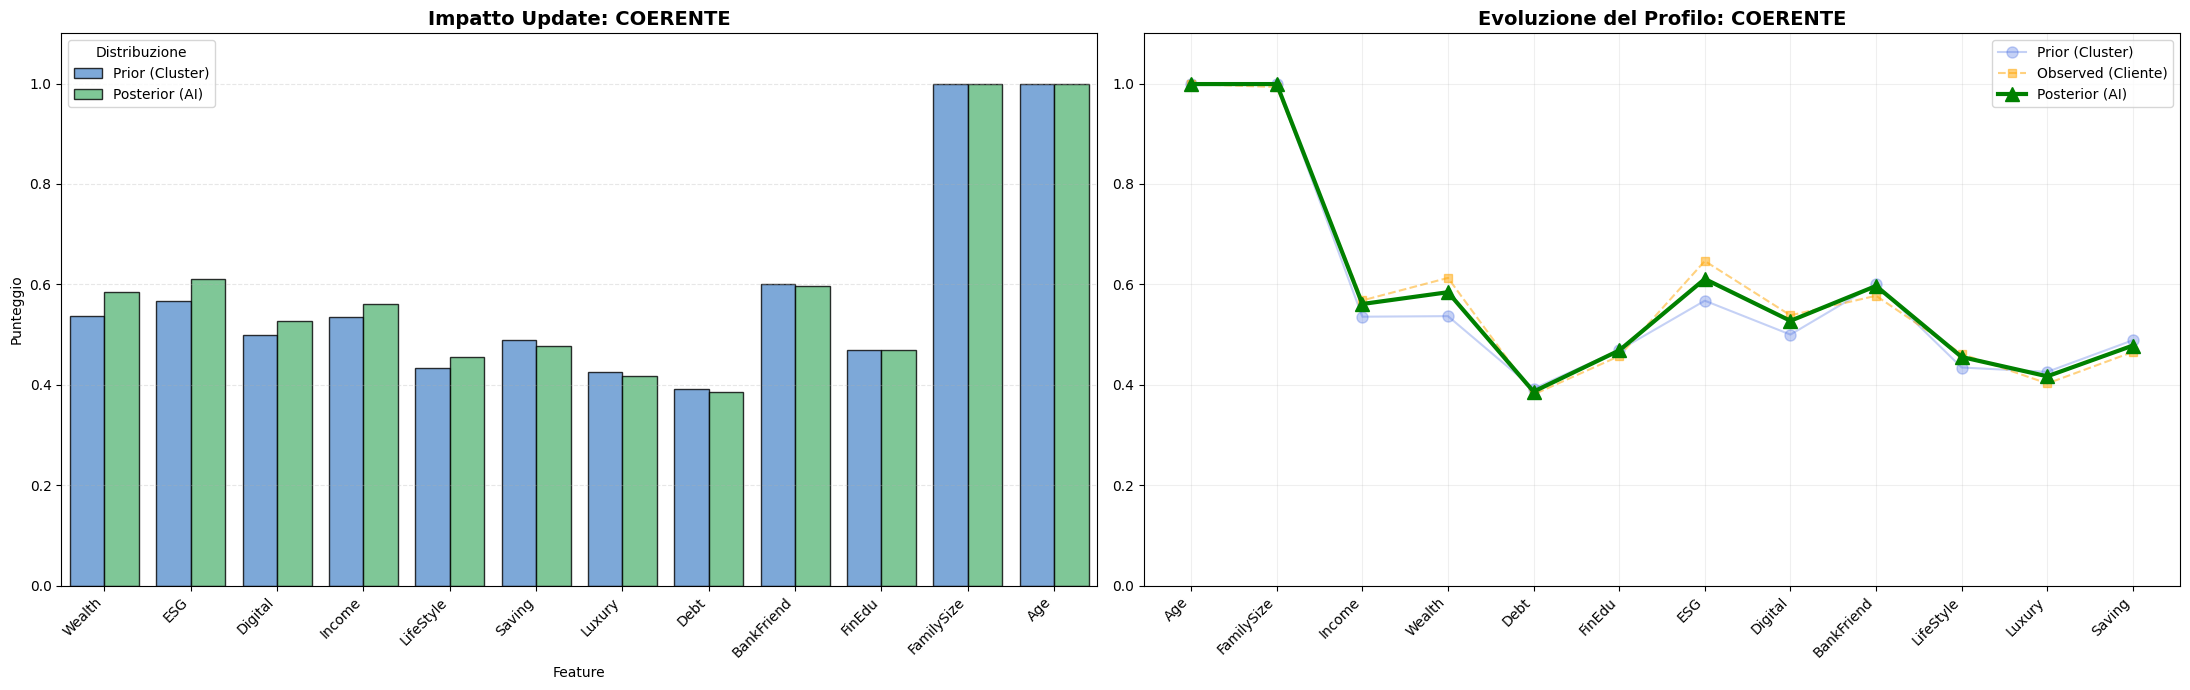


 ANALISI BAYESIANA MULTIVARIATA: CLIENTE 'DIVERSO'

1. TABELLA DEI DELTA (Ordinata per importanza dello spostamento):


,Feature,Prior (Cluster),Observed (Dato),Posterior (AI),Delta
0,Digital,0.500123,0.750123,0.673940,0.173817
1,Luxury,0.425969,0.575969,0.551429,0.125460
2,FinEdu,0.469056,0.669056,0.583340,0.114284
3,BankFriend,0.600880,0.400880,0.514007,-0.086872
4,Saving,0.488893,0.588893,0.560924,0.072031
5,Debt,0.392558,0.392558,0.426720,0.034161
6,LifeStyle,0.434593,0.434593,0.461596,0.027003
7,Wealth,0.536859,0.536859,0.560156,0.023297
8,Income,0.535747,0.535747,0.554298,0.018551
9,ESG,0.567615,0.567615,0.567468,-0.000147


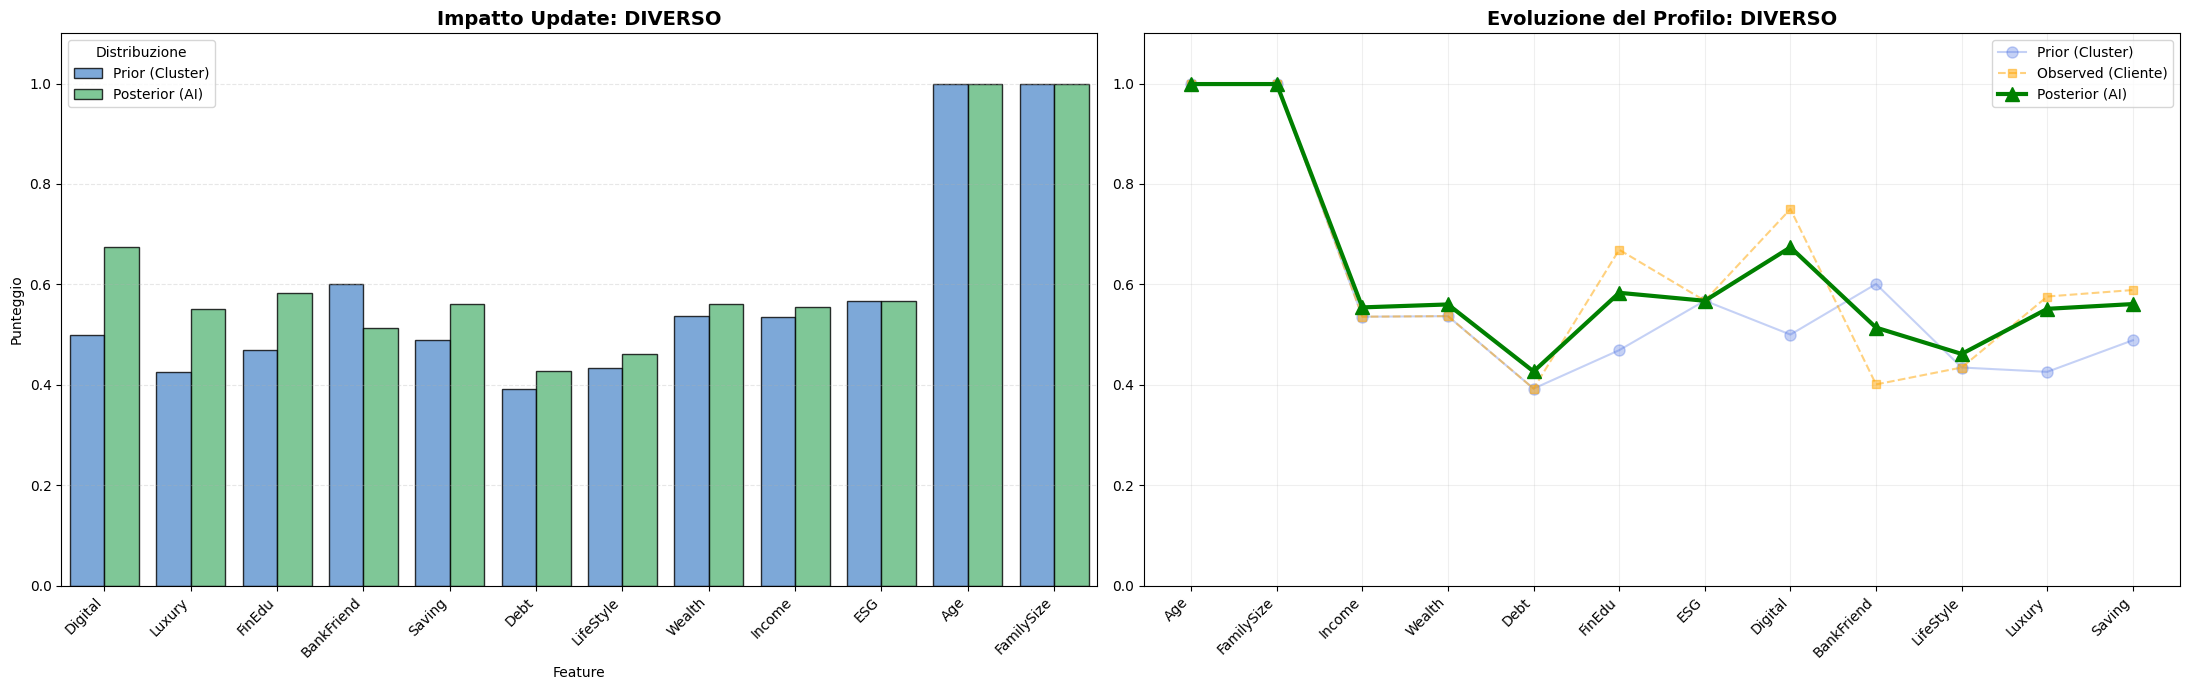


 ANALISI BAYESIANA MULTIVARIATA: CLIENTE 'MOLTO_DIVERSO'

1. TABELLA DEI DELTA (Ordinata per importanza dello spostamento):


,Feature,Prior (Cluster),Observed (Dato),Posterior (AI),Delta
0,Digital,0.500123,0.950000,0.895991,0.395869
1,Luxury,0.425969,0.850000,0.809200,0.383230
2,LifeStyle,0.434593,0.800000,0.765971,0.331378
3,Debt,0.392558,0.700000,0.721638,0.329080
4,FinEdu,0.469056,0.900000,0.782616,0.313560
5,Saving,0.488893,0.750000,0.700252,0.211359
6,BankFriend,0.600880,0.200000,0.413842,-0.187037
7,Wealth,0.536859,0.536859,0.626153,0.089294
8,Income,0.535747,0.535747,0.613774,0.078027
9,ESG,0.567615,0.567615,0.565163,-0.002452


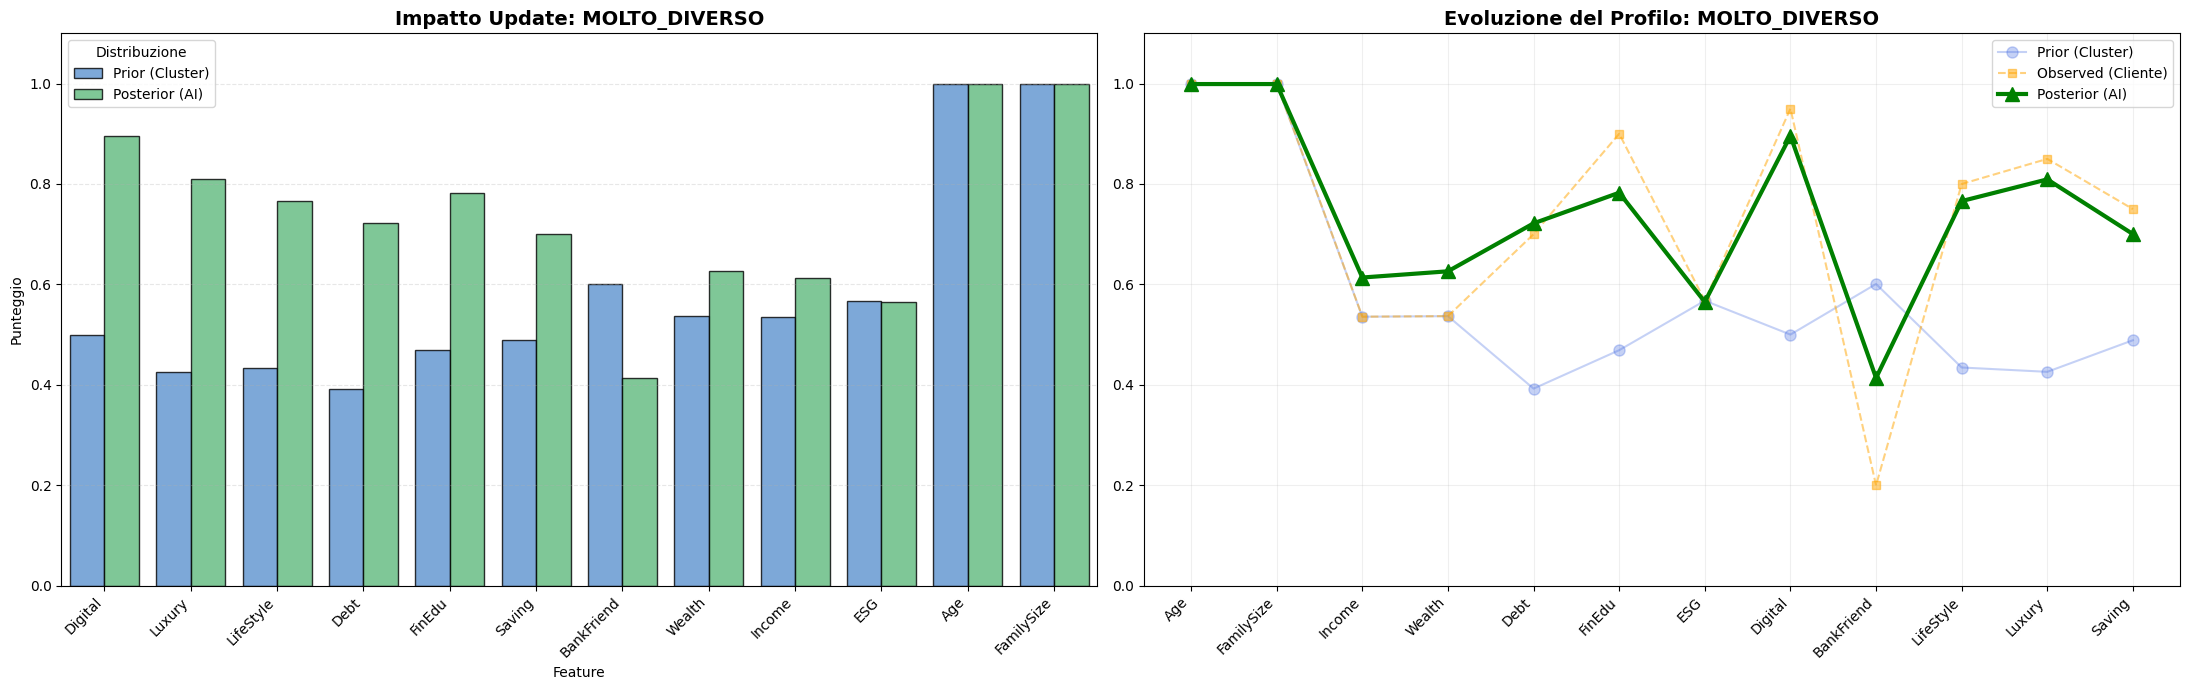

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

#FUNCTIONS

def logit(x):
    """
    Transforms the data from the [0, 1] space to the Real space (-inf, +inf)
    """
    x = np.clip(x, 1e-5, 1 - 1e-5)
    return np.log(x / (1 - x))

def sigmoid(z):
    """
    Transforms the data from the Real space to the [0, 1] space
    """
    return 1 / (1 + np.exp(-z))

def multivariate_bayesian_update_with_cov(mu_prior, sigma_prior, observation_raw, sigma_noise):
    """
    Performs the multivariate update (Kalman Filter).
    Returns the new updated mean (mu) and updated covariance (sigma).
    """
    # Transformation into logit space
    y = logit(observation_raw)

    # Calculation of the Kalman Gain (K)
    # Determines how much weight to give to the new data compared to the cluster knowledge
    inv_term = np.linalg.inv(sigma_prior + sigma_noise)
    K = sigma_prior @ inv_term

    # Mean Update: mu_post = mu_prior + K * (difference between observation and prior)
    mu_post = mu_prior + K @ (y - mu_prior)

    # Covariance Update: reduces the model's uncertainty
    sigma_post = (np.eye(len(mu_prior)) - K) @ sigma_prior

    return mu_post, sigma_post

# DATA AND PRIOR

persona_features = [
    'Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
    'FinEdu', 'ESG', 'Digital', 'BankFriend',
    'LifeStyle', 'Luxury', 'Saving'
]

# Extracting real data from Cluster 2 (Ensure that data_agglo_dice_k4 is defined)
cluster_2_data = data_agglo_dice_k4[data_agglo_dice_k4['Cluster'] == 2][persona_features]

# Calculation of Prior Mean with SOFT CLIP (0.001) for a clean visualization
mu_0 = logit(mu_0_raw)

# Calculation of Prior Covariance (Sigma_0) based on the cluster's real correlations
cluster_logit = logit(cluster_2_data.values)
sigma_0 = np.cov(cluster_logit, rowvar=False)
sigma_0 += np.eye(len(persona_features)) * 1e-3  # Regularization for stability: a small "noise" added to ensure the matrix is mathematically invertible

# Observation Uncertainty (Sigma_n)
# A value of 0.5 indicates that we give moderate weight to each single new observation
sigma_n = np.eye(len(persona_features)) * 0.5

# Calculation of the correlation in the logit domain (where the MVN model operates)
corr_matrix = pd.DataFrame(cluster_logit, columns=persona_features).corr()

# Heatmap visualitation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            linewidths=0.5)

plt.title("Matrice di Correlazione del Cluster 2 (Spazio Logit)", fontsize=16, fontweight='bold')
plt.show()

# FOR LOOP

for label in synthetic_df.index:
    print(f"\n" + "="*80)
    print(f" ANALISI BAYESIANA MULTIVARIATA: CLIENTE '{label.upper()}'")
    print("="*80)

    # 1) Update Computation
    y_obs = synthetic_df.loc[label].astype(float).values
    mu_p, sigma_p = multivariate_bayesian_update_with_cov(mu_0, sigma_0, y_obs, sigma_n)
    post_mean = sigmoid(mu_p)

    # 2) Delta table
    df_delta = pd.DataFrame({
        'Feature': persona_features,
        'Prior (Cluster)': mu_0_raw,
        'Observed (Dato)': y_obs,
        'Posterior (AI)': post_mean
    })
    df_delta['Delta'] = df_delta['Posterior (AI)'] - df_delta['Prior (Cluster)']
    df_delta['Abs_Delta'] = df_delta['Delta'].abs()
    df_delta = df_delta.sort_values(by='Abs_Delta', ascending=False).reset_index(drop=True)

    print("\n1. TABELLA DEI DELTA (Ordinata per importanza dello spostamento):")
    display(df_delta[['Feature', 'Prior (Cluster)', 'Observed (Dato)', 'Posterior (AI)', 'Delta']])

    # 3) Visualitation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))

    # Bar Chart (Static Comparison)
    df_bar = pd.melt(df_delta, id_vars=['Feature'],
                     value_vars=['Prior (Cluster)', 'Posterior (AI)'],
                     var_name='Distribuzione', value_name='Punteggio')

    sns.barplot(x='Feature', y='Punteggio', hue='Distribuzione', data=df_bar, ax=ax1,
                palette=['#4A90E2', '#50C878'], edgecolor='black', alpha=0.8)
    ax1.set_title(f"Impatto Update: {label.upper()}", fontsize=14, fontweight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.set_ylim(0, 1.1)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # Line Chart (Profile Evolution)
    ax2.plot(persona_features, mu_0_raw, 'o-', label="Prior (Cluster)", color='royalblue', alpha=0.3, markersize=8)
    ax2.plot(persona_features, y_obs, 's--', label="Observed (Cliente)", color='orange', alpha=0.5)
    ax2.plot(persona_features, post_mean, '^-', label="Posterior (AI)", color='green', linewidth=3, markersize=10)

    ax2.set_title(f"Evoluzione del Profilo: {label.upper()}", fontsize=14, fontweight='bold')
    ax2.set_xticklabels(persona_features, rotation=45, ha='right')
    ax2.set_ylim(0, 1.1)
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

The bivariate analysis highlights how the Bayesian update affects not only individual features, but also the relationships between them. In particular, we can observe how key behavioral dimensions interact:
- financial awareness vs digitalization (FinEdu, Digital),
- saving behavior vs indebtedness (Saving, Debt),
- lifestyle vs luxury orientation (LifeStyle, Luxury).

After the update:
- a coherent customer preserves both the level and the relationship between variables;
- a different customer shifts the balance between variables (e.g., higher Digital relative to FinEdu);
- a very different customer can alter the structure of the relationship (e.g., high Debt together with high Saving, or strong Digital with weak BankFriend).

This shows that the persona evolves not only in magnitude but also in internal structure. The joint behavior of variables becomes more or less aligned depending on the new observation.